# Gas Sensor Array Drift at Different Concentrations
## Classification Track — Review 1

### Objective

The objective of this classification task is to predict the type of gas from
chemical sensor array measurements.

The dataset contains measurements from 16 chemical sensors and 128
sensor-derived features.

### Classification Algorithms

The following five algorithms required for Review 1 are implemented:

1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Classifier (SVC)

### Evaluation Metrics

The models are evaluated using:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score
- Confusion Matrix

A common train-test split and preprocessing pipeline are used for fair
comparison between models.

In [14]:
import sys
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_dataset, add_gas_names, GAS_NAMES

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset Loading and Audit

In [25]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parent

# Allow importing from src/
sys.path.append(str(PROJECT_ROOT / "src"))

from data_loader import load_dataset, add_gas_names

# Load the raw UCI .dat files
df = load_dataset(PROJECT_ROOT / "data")

# Add readable gas names
df = add_gas_names(df)

print("Dataset shape:", df.shape)

Looking for dataset in:
c:\Projects\AutoML-_-Project\gas_sensor_ml_capstone\data

Found 10 .dat files.

Loading: batch1.dat
  Samples loaded: 445
Loading: batch10.dat
  Samples loaded: 3600
Loading: batch2.dat
  Samples loaded: 1244
Loading: batch3.dat
  Samples loaded: 1586
Loading: batch4.dat
  Samples loaded: 161
Loading: batch5.dat
  Samples loaded: 197
Loading: batch6.dat
  Samples loaded: 2300
Loading: batch7.dat
  Samples loaded: 3613
Loading: batch8.dat
  Samples loaded: 294
Loading: batch9.dat
  Samples loaded: 470
Dataset shape: (13910, 132)


In [16]:
df = add_gas_names(df)

print(df.head())

   gas_class  concentration   batch    Feature1  Feature2   Feature3  \
0          1           10.0  batch1  15596.1621  1.868245   2.371604   
1          1           20.0  batch1  26402.0704  2.532401   5.411209   
2          1           30.0  batch1  42103.5820  3.454189   8.198175   
3          1           40.0  batch1  42825.9883  3.451192  12.113940   
4          1           50.0  batch1  58151.1757  4.194839  11.455096   

    Feature4   Feature5   Feature6   Feature7  ...  Feature120  Feature121  \
0   2.803678   7.512213  -2.739388  -3.344671  ...   -3.037772   3037.0390   
1   6.509906   7.658469  -4.722217  -5.817651  ...   -1.994993   4176.4453   
2  10.508439  11.611003  -7.668313  -9.478675  ...   -2.867291   5914.6685   
3  16.266853  39.910056  -7.849409  -9.689894  ...   -3.058086   6147.4744   
4  15.715298  17.654915 -11.083364 -13.580692  ...   -4.181920   8158.6449   

   Feature122  Feature123  Feature124  Feature125  Feature126  Feature127  \
0    3.972203    0.52

In [17]:
print("========== DATASET VERIFICATION ==========\n")

print("Dataset shape:")
print(df.shape)

print("\nNumber of features:")
print(len([
    column
    for column in df.columns
    if column.startswith("Feature")
]))

print("\nFirst 5 rows:")
display(df.head())

========== DATASET VERIFICATION ==========

Dataset shape:
(13910, 132)

Number of features:
128

First 5 rows:


,gas_class,concentration,batch,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,...,Feature120,Feature121,Feature122,Feature123,Feature124,Feature125,Feature126,Feature127,Feature128,gas_name
0,1,10.0,batch1,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,...,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529,Ethanol
1,1,20.0,batch1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,...,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225,Ethanol
2,1,30.0,batch1,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,...,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370,Ethanol
3,1,40.0,batch1,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,...,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957,Ethanol
4,1,50.0,batch1,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,...,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756,Ethanol


In [18]:
feature_columns = [
    f"Feature{i}"
    for i in range(1, 129)
]

print("First 5 values of Feature1:")
print(df["Feature1"].head())

print("\nFirst 5 values of Feature127:")
print(df["Feature127"].head())

print("\nFirst 5 values of Feature128:")
print(df["Feature128"].head())

print("\nMissing values in Feature128:")
print(df["Feature128"].isna().sum())

First 5 values of Feature1:
0    15596.1621
1    26402.0704
2    42103.5820
3    42825.9883
4    58151.1757
Name: Feature1, dtype: float64

First 5 values of Feature127:
0   -0.902241
1   -1.323505
2   -1.993659
3   -2.146158
4   -2.931265
Name: Feature127, dtype: float64

First 5 values of Feature128:
0   -2.654529
1   -1.749225
2   -2.348370
3   -2.488957
4   -4.088756
Name: Feature128, dtype: float64

Missing values in Feature128:
0


## DATASET AUDIT

## 2. EDA
- shape and dtypes
- missing values
- duplicates
- outliers
- gas-class distribution
- feature distributions
- correlation heatmap
- feature/class relationships

## UNDERSTAND COLUMN NAMES

## MISSING VALUES

In [20]:
print("========== DATASET AUDIT ==========\n")

print("Shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes.value_counts())

print("\nGas classes:")
print(
    df["gas_class"]
    .value_counts()
    .sort_index()
)

print("\nGas names:")
print(
    df["gas_name"]
    .value_counts()
)

print("\nConcentration summary:")
display(
    df["concentration"].describe()
)

print("\nBatch distribution:")
print(
    df["batch"]
    .value_counts()
    .sort_index()
)

========== DATASET AUDIT ==========

Shape:
(13910, 132)

Data types:
float64    129
object       2
int64        1
Name: count, dtype: int64

Gas classes:
gas_class
1    2565
2    2926
3    1641
4    1936
5    3009
6    1833
Name: count, dtype: int64

Gas names:
gas_name
Acetone         3009
Ethylene        2926
Ethanol         2565
Acetaldehyde    1936
Toluene         1833
Ammonia         1641
Name: count, dtype: int64

Concentration summary:


count    13910.000000
mean       157.094644
std        171.443975
min          1.000000
25%         50.000000
50%        100.000000
75%        200.000000
max       1000.000000
Name: concentration, dtype: float64


Batch distribution:
batch
batch1      445
batch10    3600
batch2     1244
batch3     1586
batch4      161
batch5      197
batch6     2300
batch7     3613
batch8      294
batch9      470
Name: count, dtype: int64


In [29]:
# Target distribution

print("Target column: gas_class")
print("=" * 40)

print(df["gas_class"].value_counts().sort_index())
print("===============================================")
print("Gas class distribution:")
print(
    df["gas_name"]
    .value_counts()
    .sort_index()
)
print("===============================================")
print(df.columns.tolist())
print("+++++++++++++++++++++++++++++++++++++++++++++++++")
print(df["gas_class"].unique())

Target column: gas_class
gas_class
1    2565
2    2926
3    1641
4    1936
5    3009
6    1833
Name: count, dtype: int64
Gas class distribution:
gas_name
Acetaldehyde    1936
Acetone         3009
Ammonia         1641
Ethanol         2565
Ethylene        2926
Toluene         1833
Name: count, dtype: int64
['gas_class', 'concentration', 'batch', 'Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Feature6', 'Feature7', 'Feature8', 'Feature9', 'Feature10', 'Feature11', 'Feature12', 'Feature13', 'Feature14', 'Feature15', 'Feature16', 'Feature17', 'Feature18', 'Feature19', 'Feature20', 'Feature21', 'Feature22', 'Feature23', 'Feature24', 'Feature25', 'Feature26', 'Feature27', 'Feature28', 'Feature29', 'Feature30', 'Feature31', 'Feature32', 'Feature33', 'Feature34', 'Feature35', 'Feature36', 'Feature37', 'Feature38', 'Feature39', 'Feature40', 'Feature41', 'Feature42', 'Feature43', 'Feature44', 'Feature45', 'Feature46', 'Feature47', 'Feature48', 'Feature49', 'Feature50', 'Feature51', 

## 3. Preprocessing and Feature Engineering

In [21]:
duplicate_count = df.duplicated().sum()

print("Duplicate complete records:", duplicate_count)

Duplicate complete records: 0


In [19]:
print("========== MISSING VALUE ANALYSIS ==========\n")

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing %": (
        missing_values / len(df) * 100
    ).round(2)
})

display(
    missing_summary[
        missing_summary["Missing Values"] > 0
    ]
)

print(
    "\nTotal missing values:",
    df.isnull().sum().sum()
)

========== MISSING VALUE ANALYSIS ==========



,Missing Values,Missing %



Total missing values: 0


In [31]:
# Check for infinite values in sensor features

import numpy as np

infinite_count = np.isinf(
    df[feature_columns].to_numpy()
).sum()

print("Total infinite feature values:", infinite_count)

Total infinite feature values: 0


In [32]:
# Statistical summary of the 128 sensor features

df[feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Feature1,13910.0,50435.066174,69844.785952,-16757.598600,6694.725950,19364.439350,63104.837125,670687.347700
Feature2,13910.0,6.638156,13.486391,0.088287,2.284843,3.871227,8.400619,1339.879283
Feature3,13910.0,12.936688,17.610061,0.000100,1.633350,4.977123,17.189166,167.079751
Feature4,13910.0,18.743953,24.899450,0.000100,2.386836,7.250892,26.411109,226.619457
Feature5,13910.0,26.890695,38.107685,0.000100,4.967988,11.680725,34.843226,993.605306
...,...,...,...,...,...,...,...,...
Feature124,13910.0,14.929364,12.437311,0.011488,5.407551,11.325214,21.207572,297.225880
Feature125,13910.0,19.090980,14.391810,0.118849,8.039227,14.560676,26.547437,195.242555
Feature126,13910.0,-4.901016,4.195360,-30.205911,-6.789599,-3.881763,-1.804032,-0.003817
Feature127,13910.0,-8.167792,7.637701,-58.844076,-11.162406,-6.305962,-2.874532,6.851792


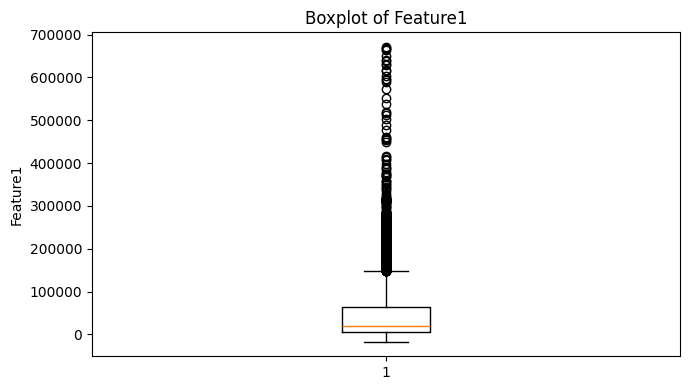

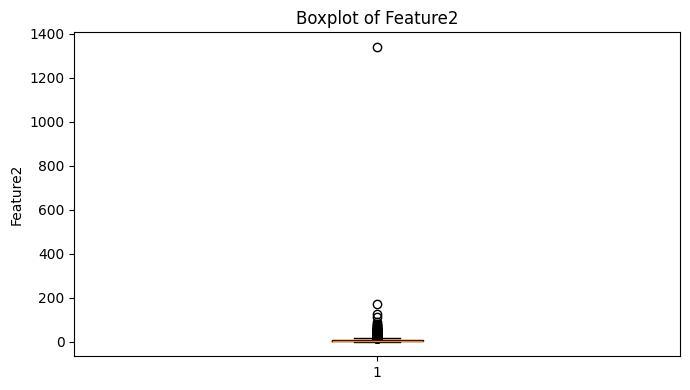

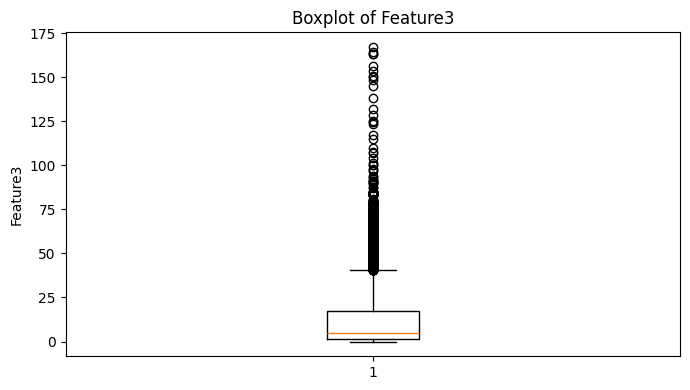

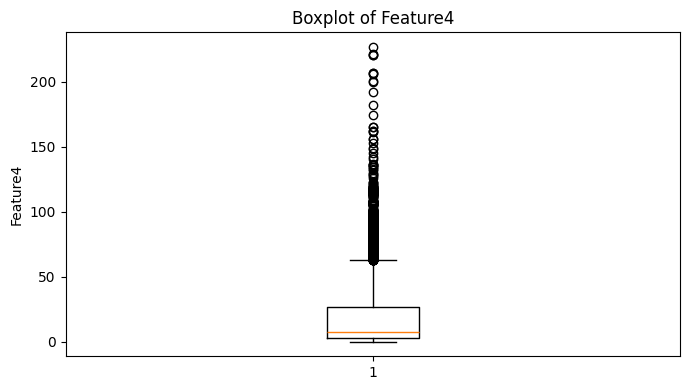

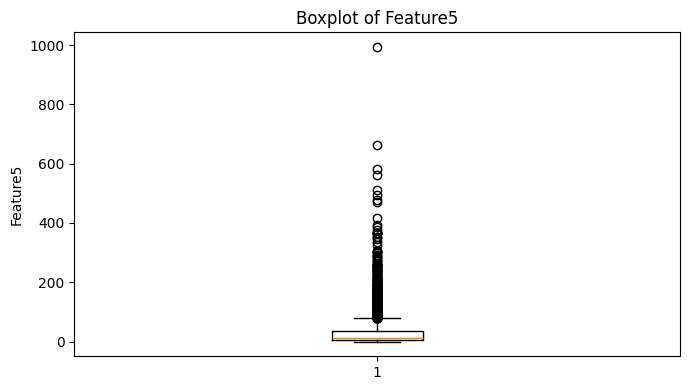

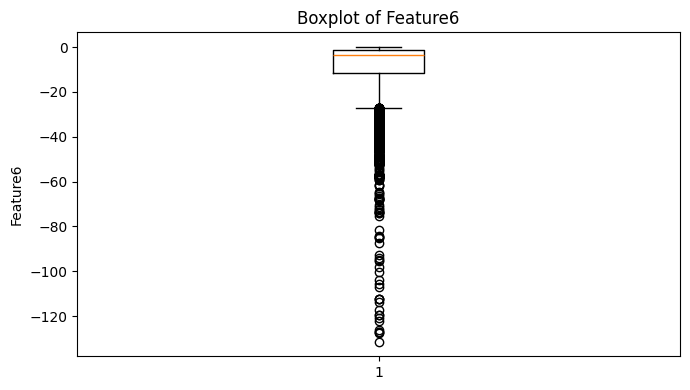

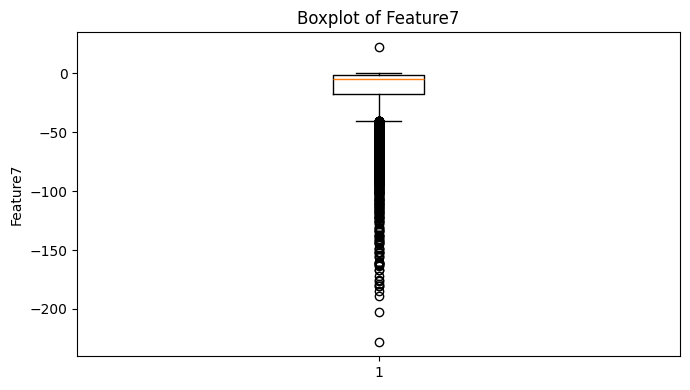

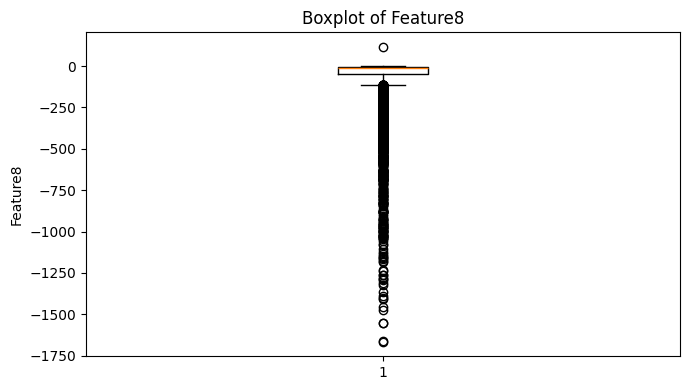

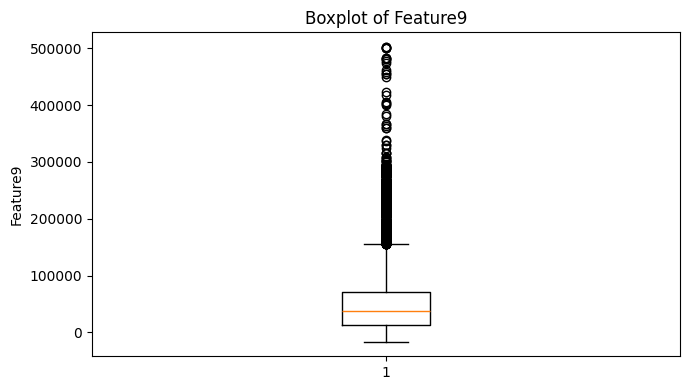

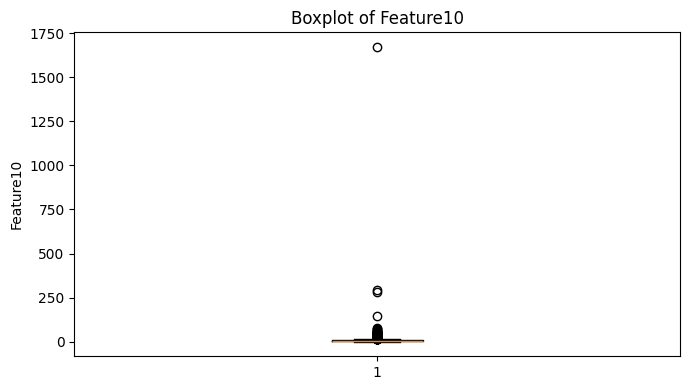

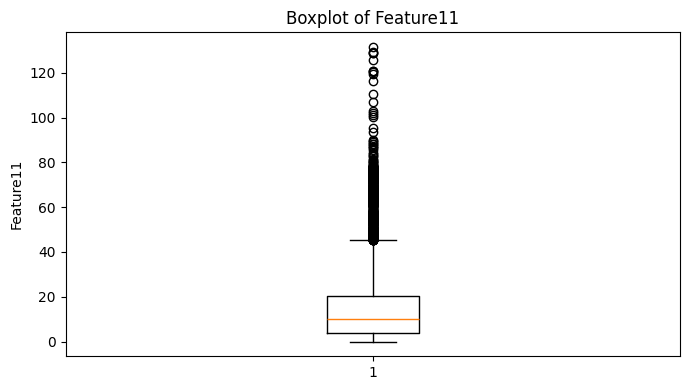

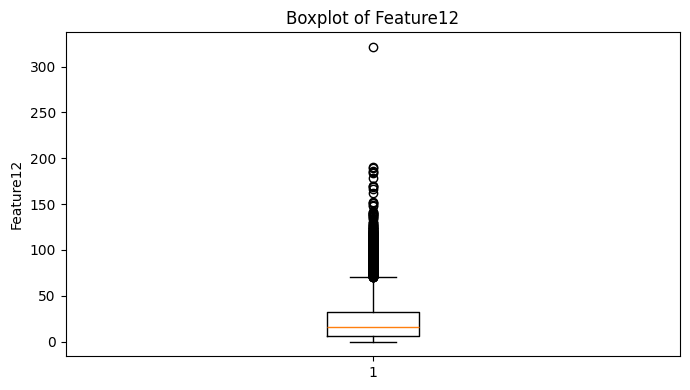

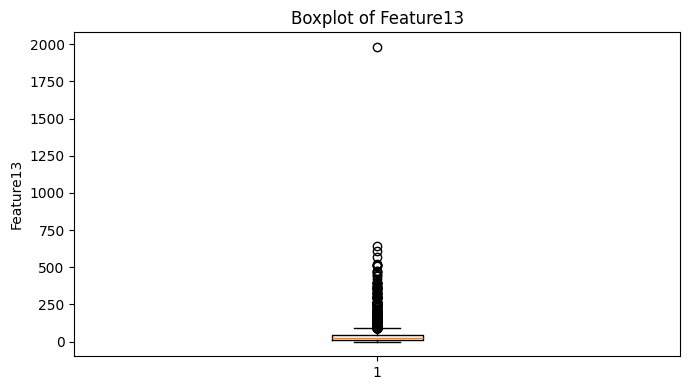

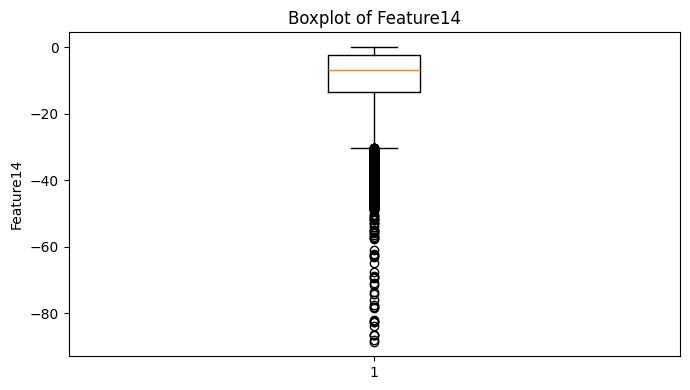

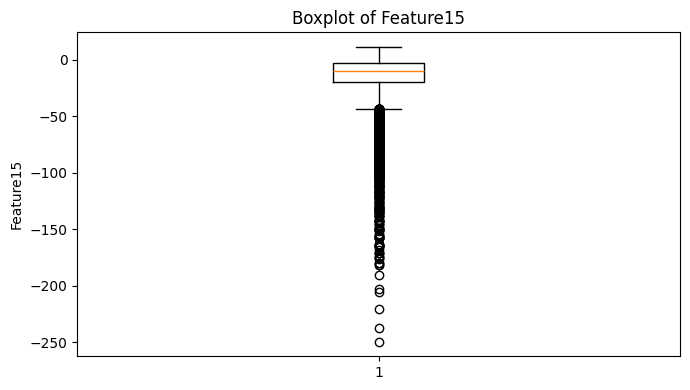

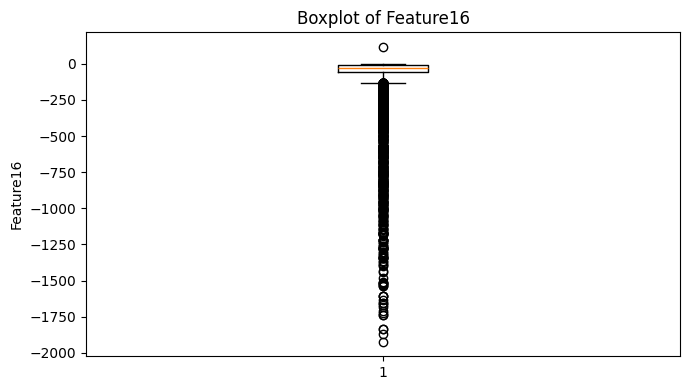

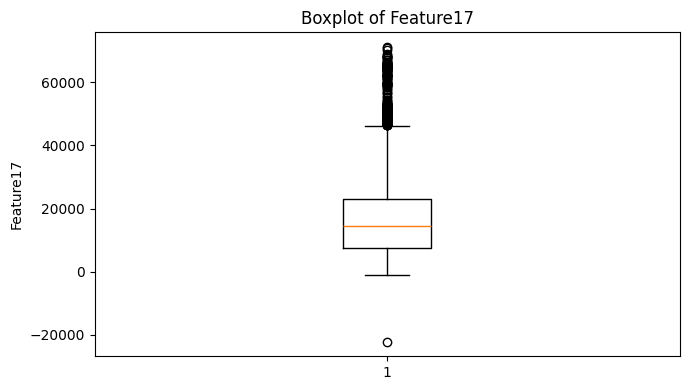

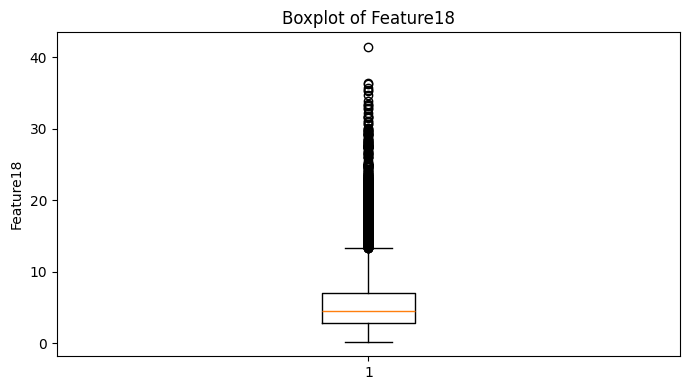

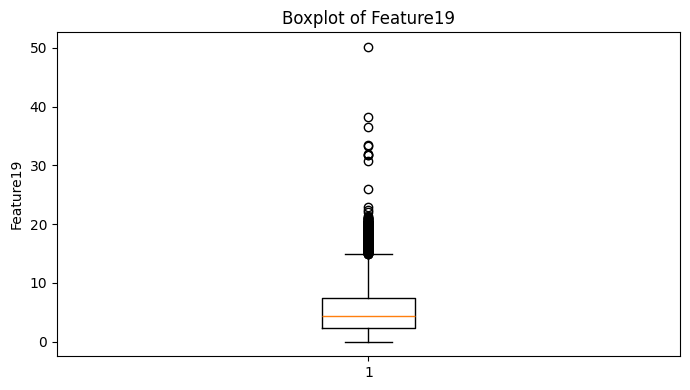

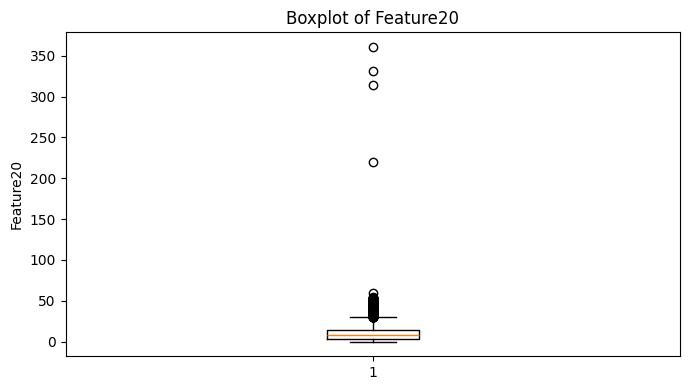

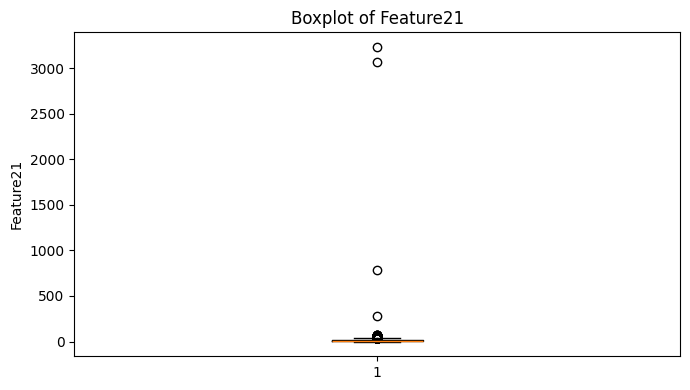

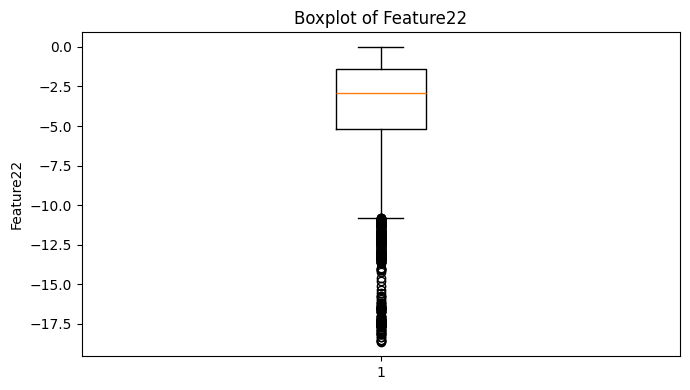

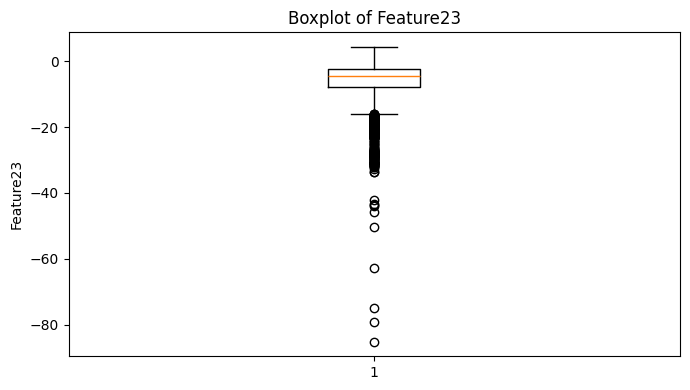

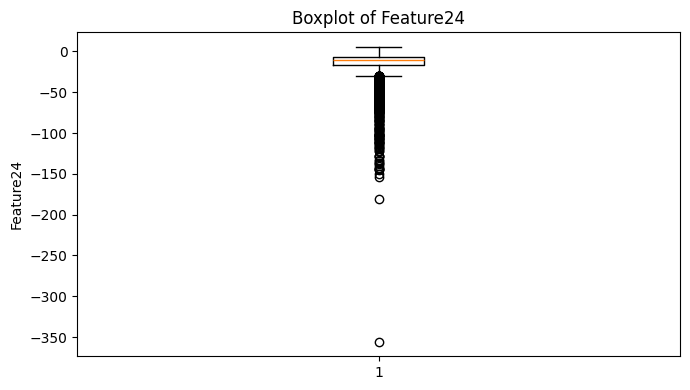

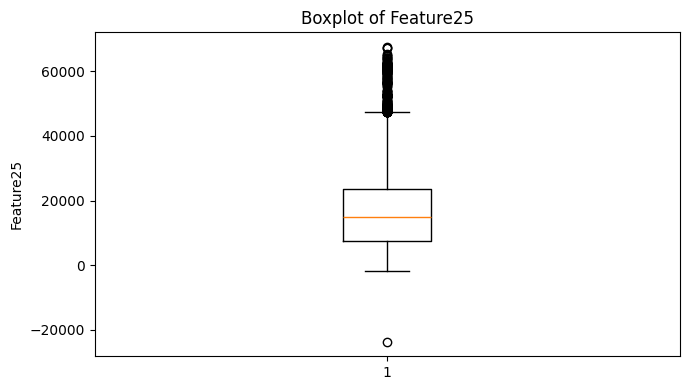

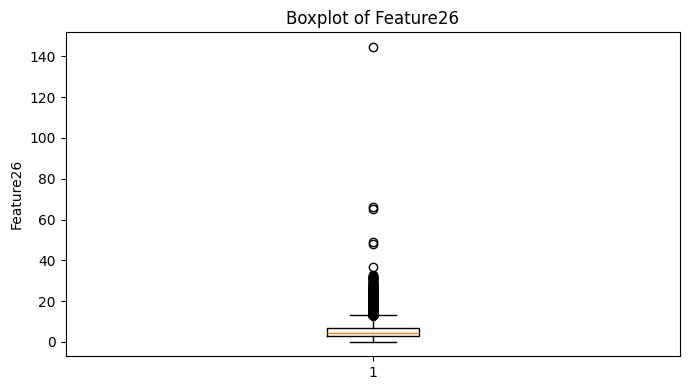

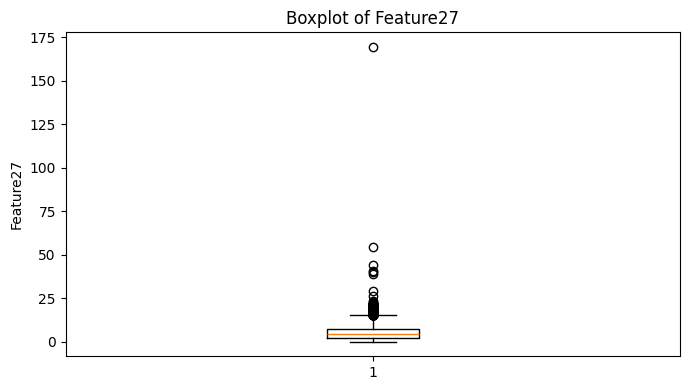

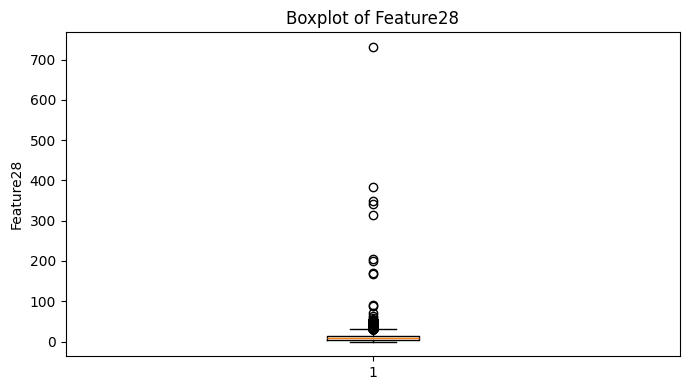

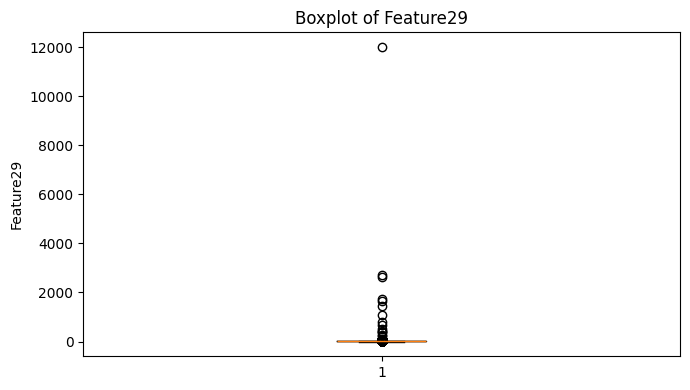

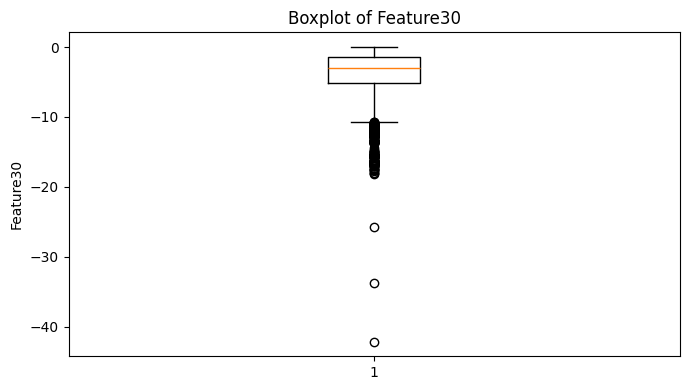

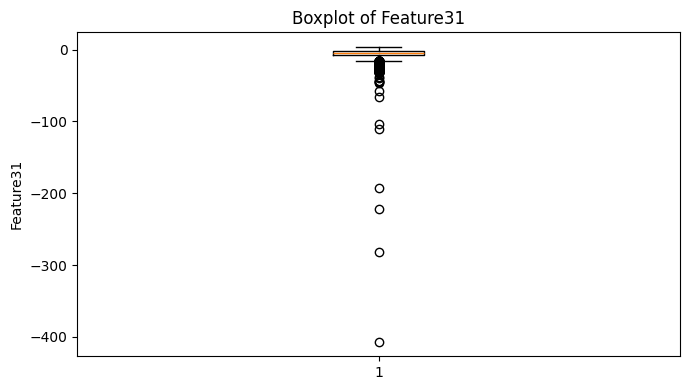

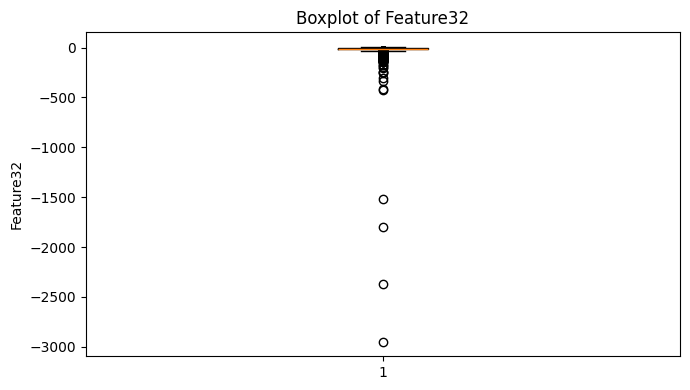

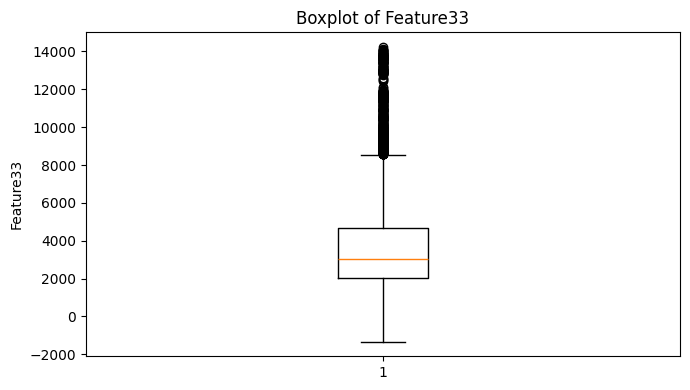

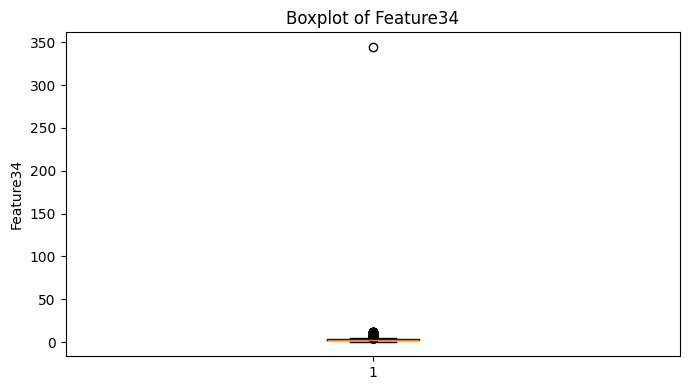

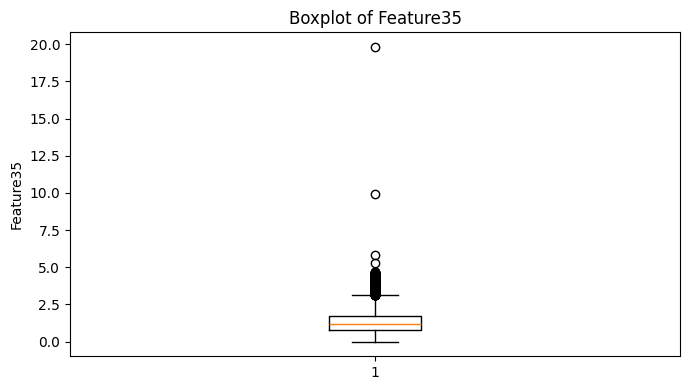

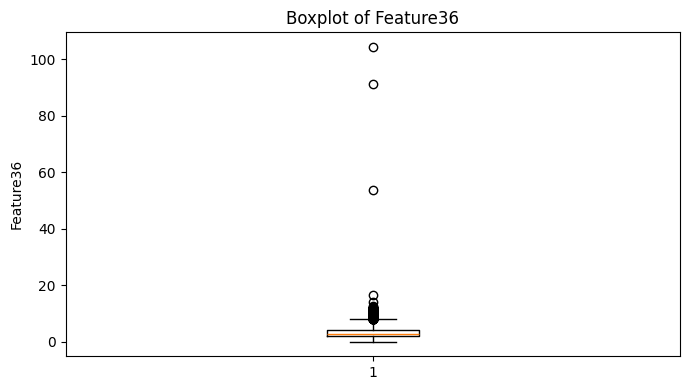

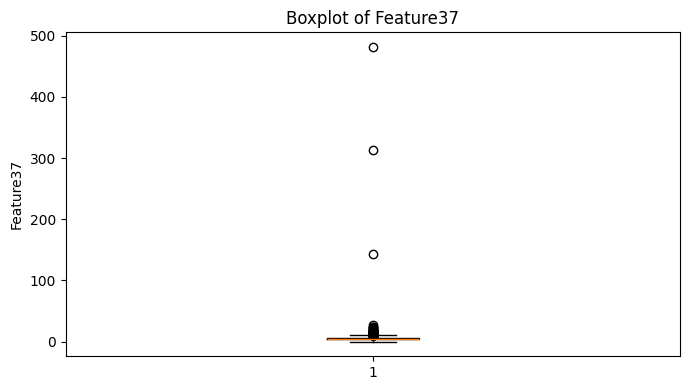

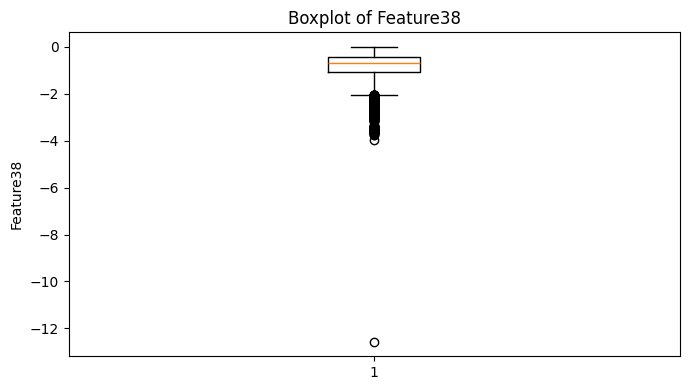

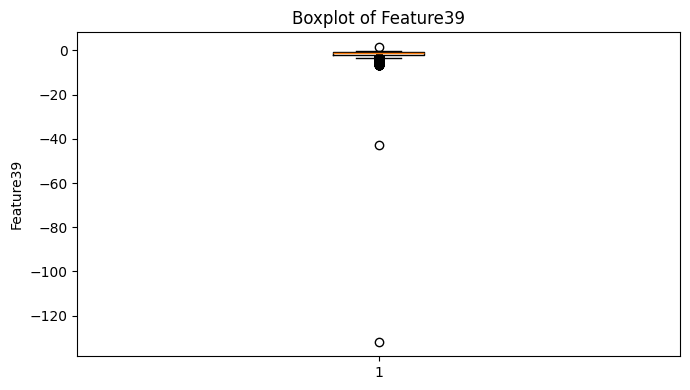

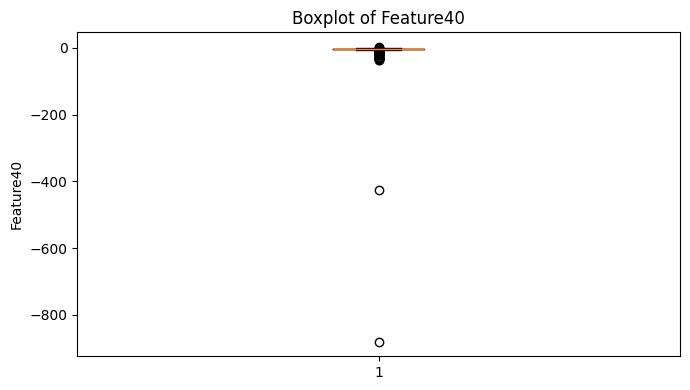

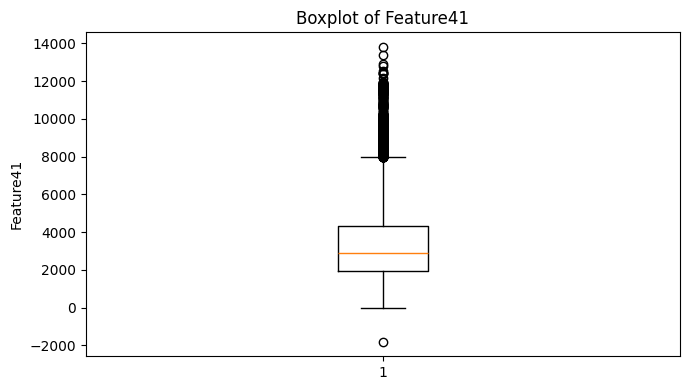

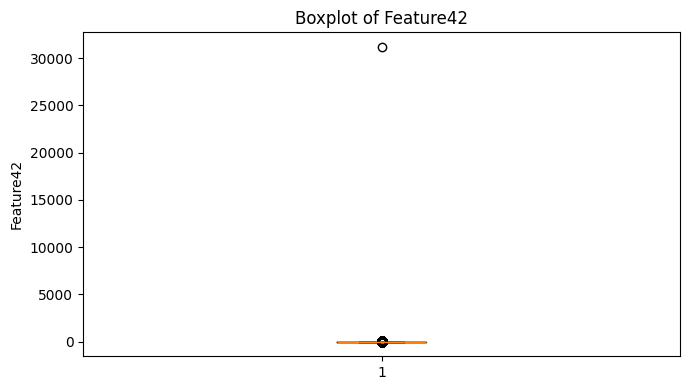

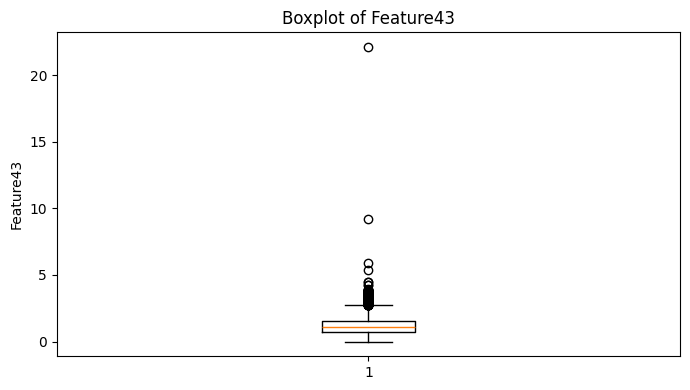

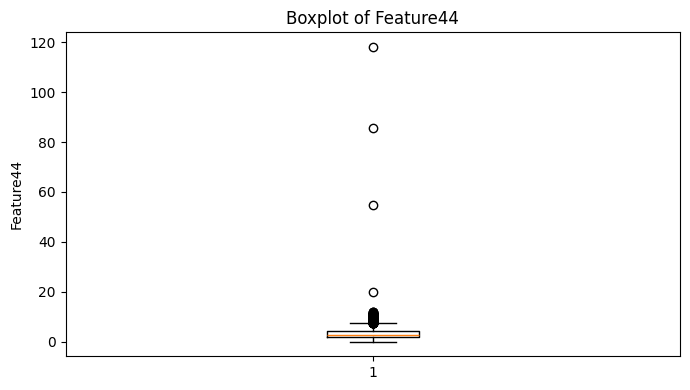

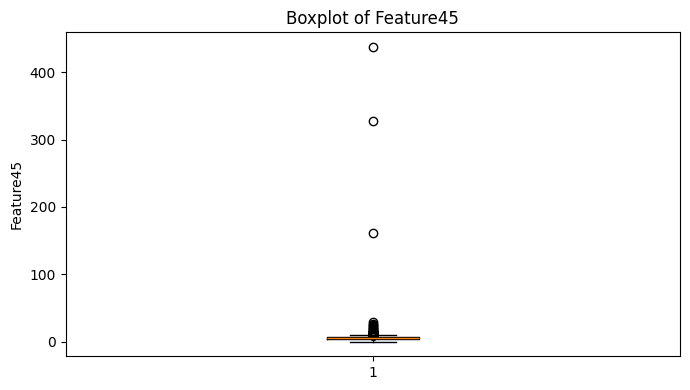

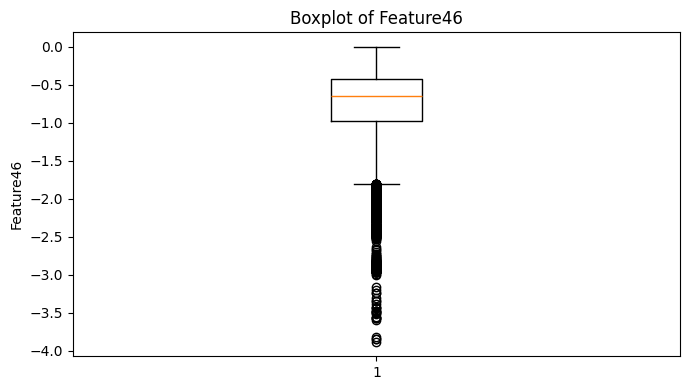

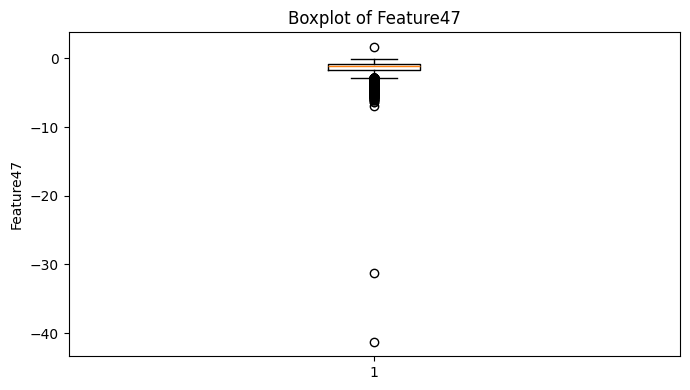

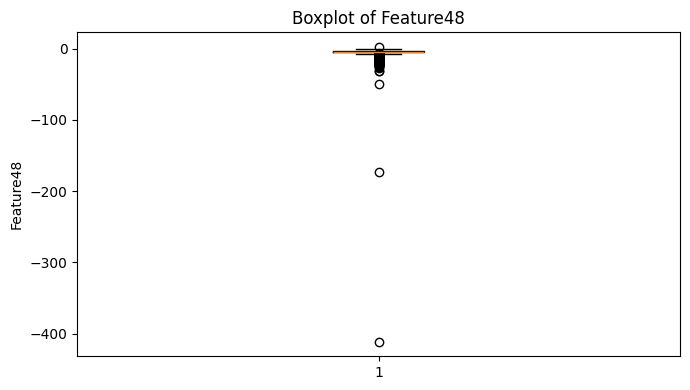

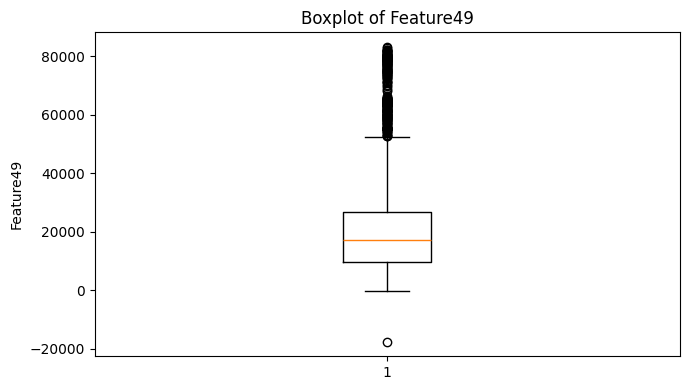

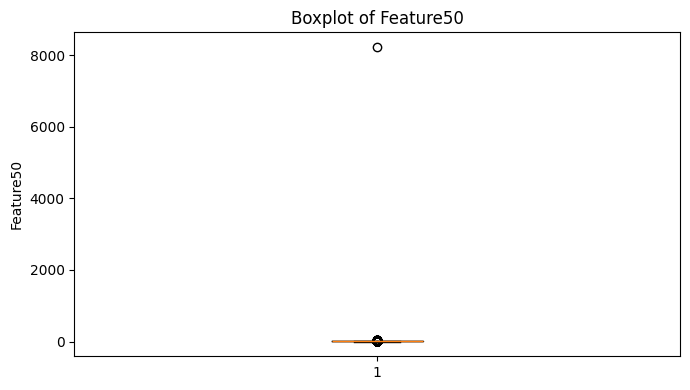

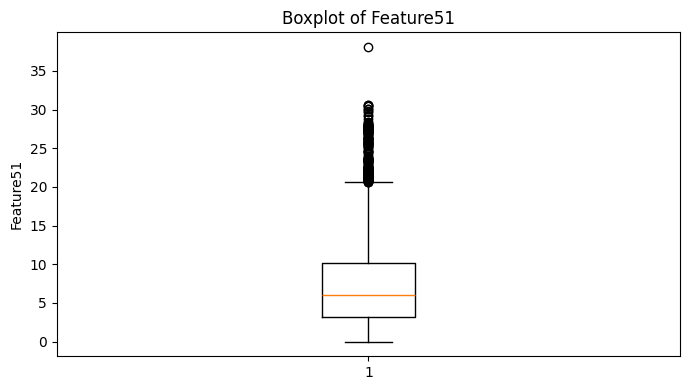

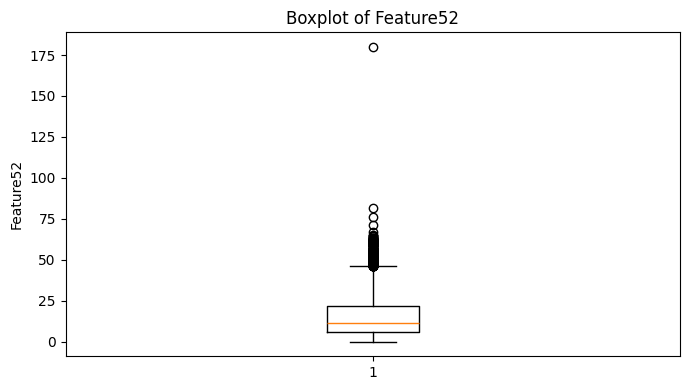

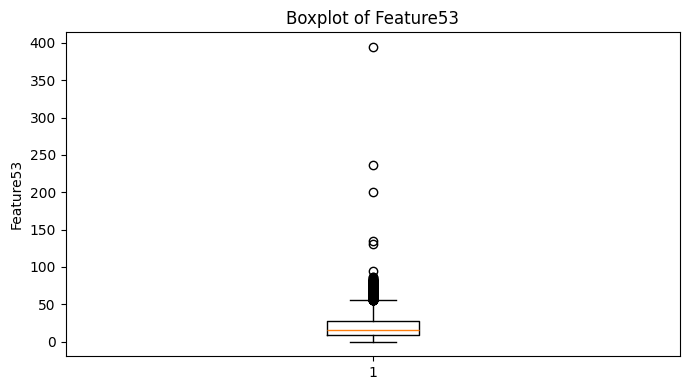

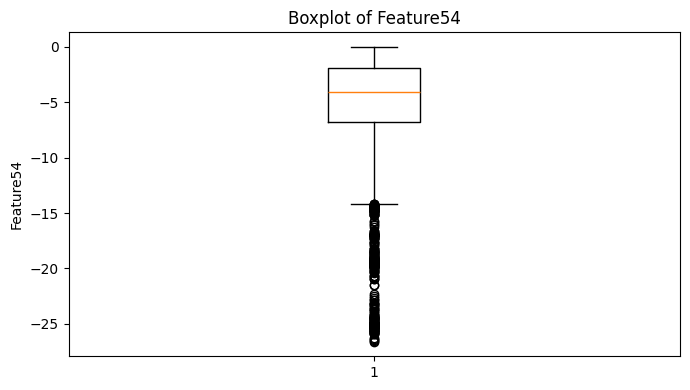

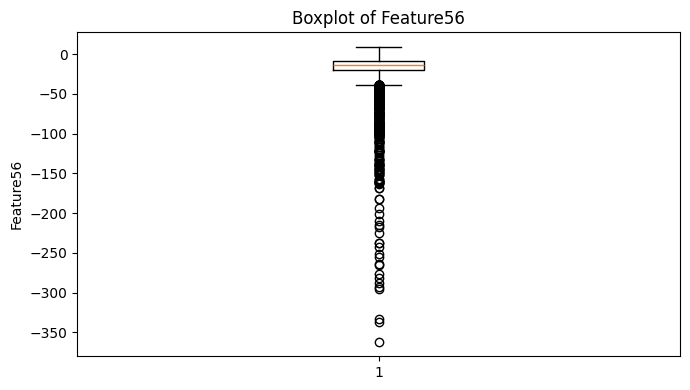

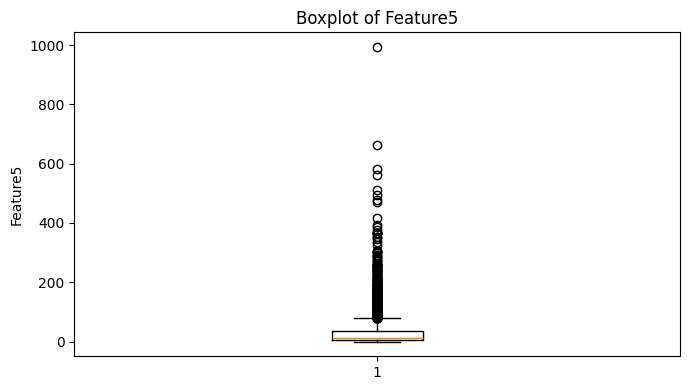

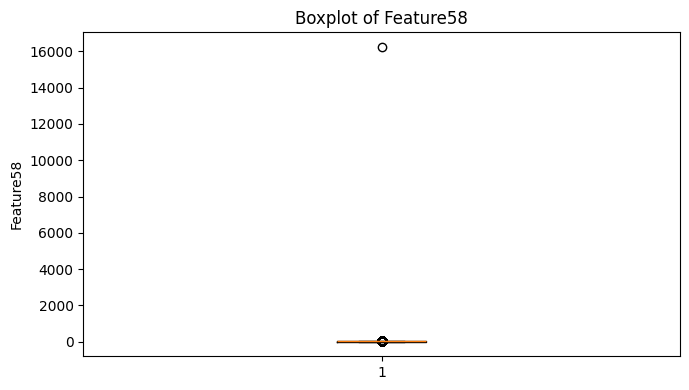

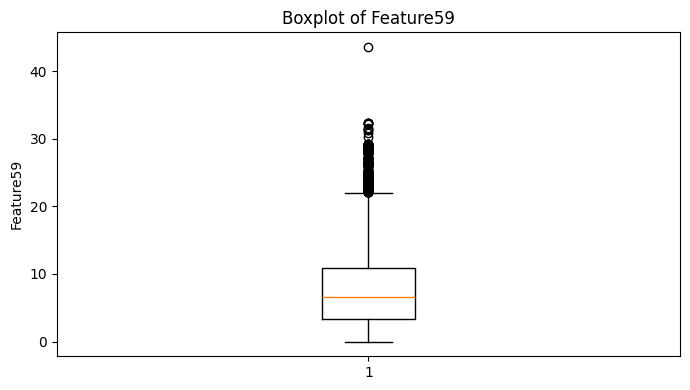

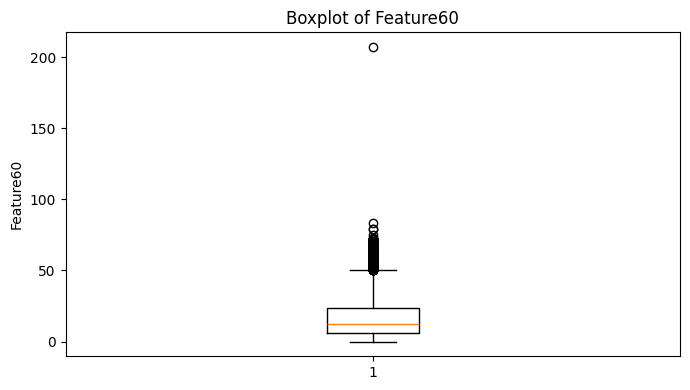

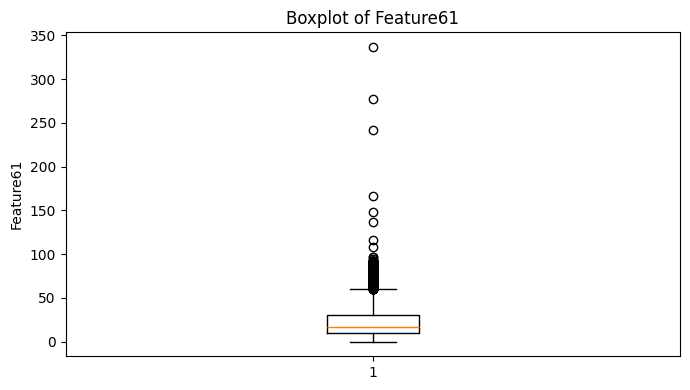

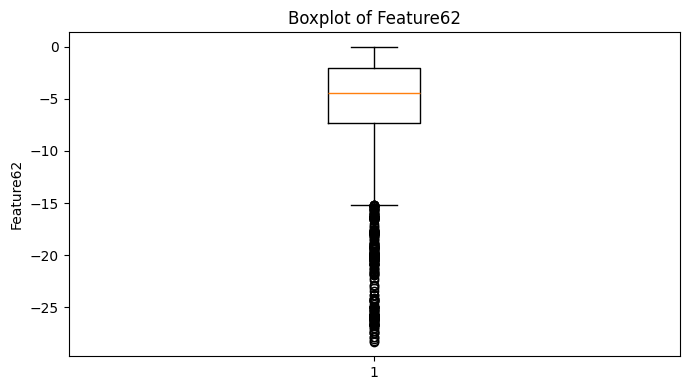

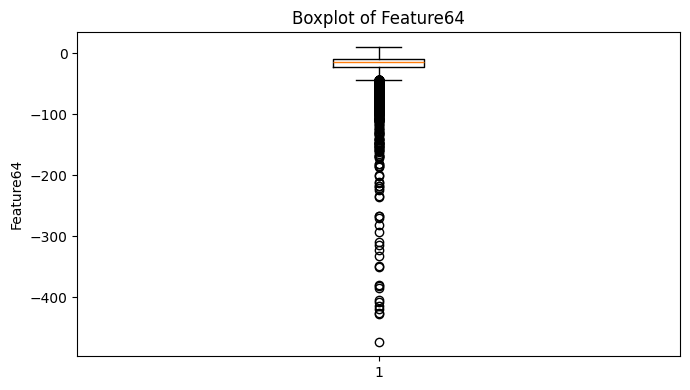

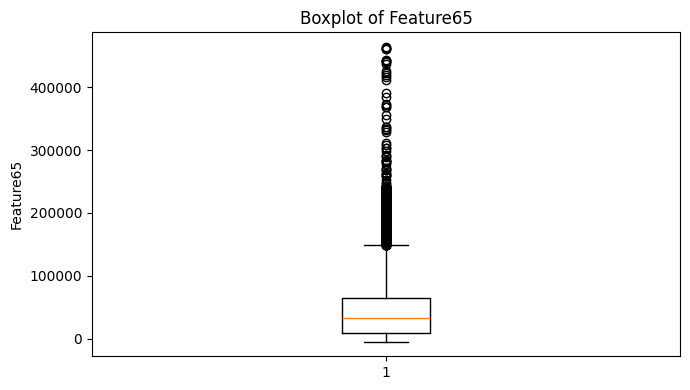

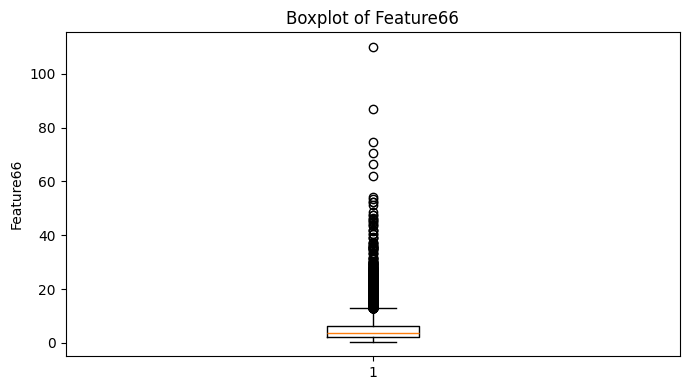

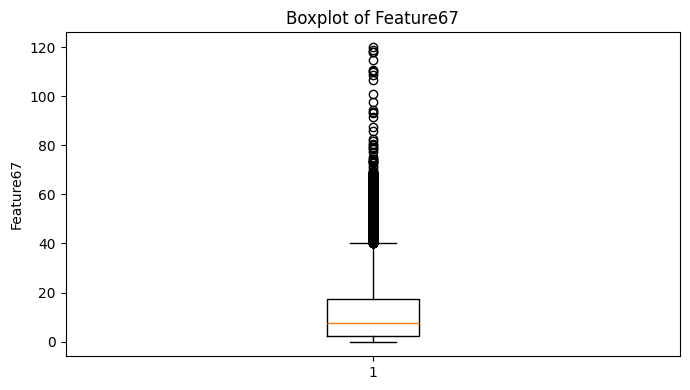

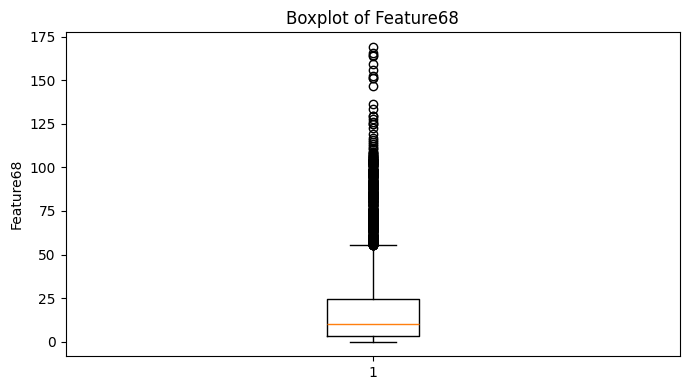

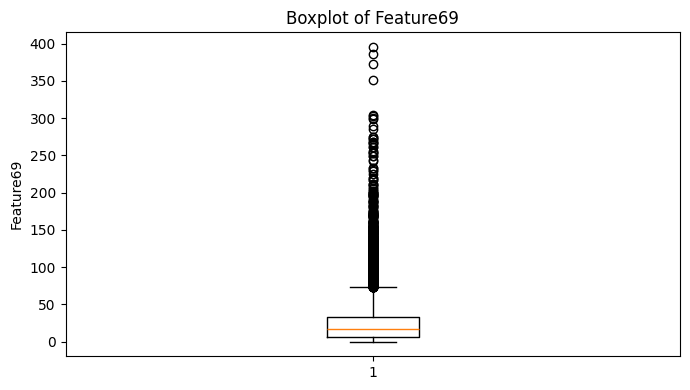

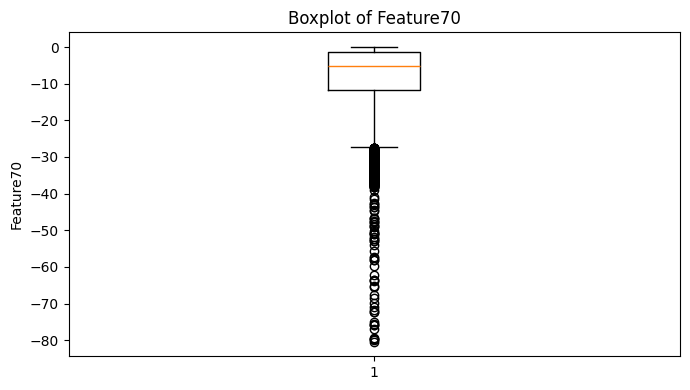

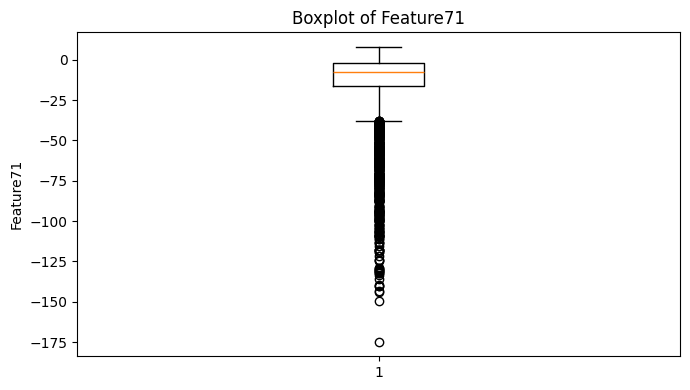

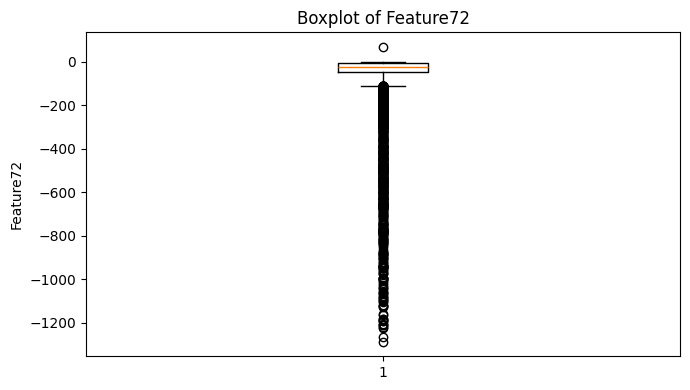

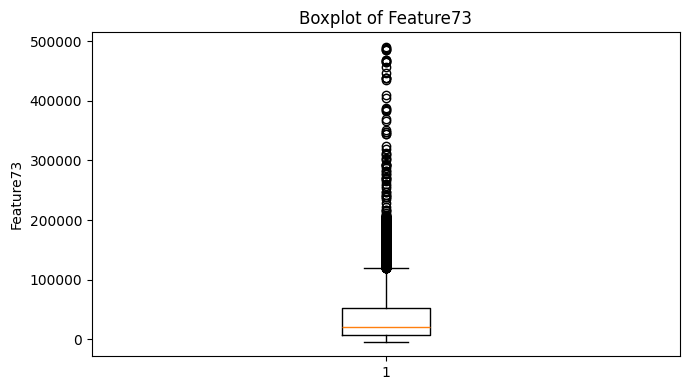

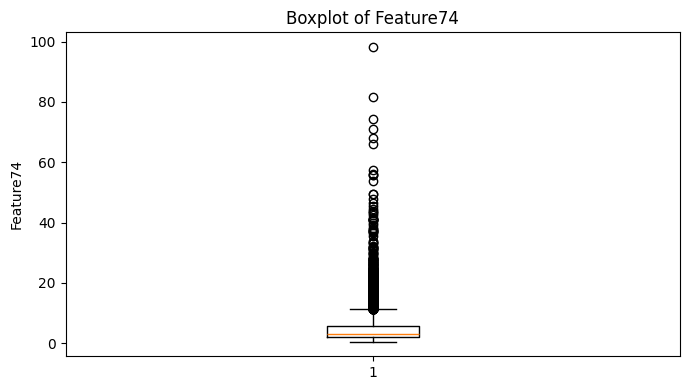

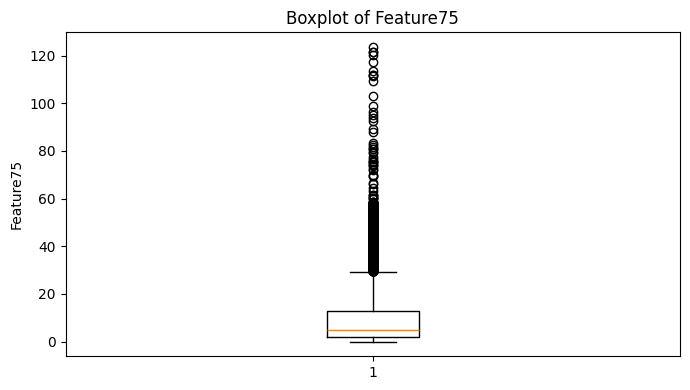

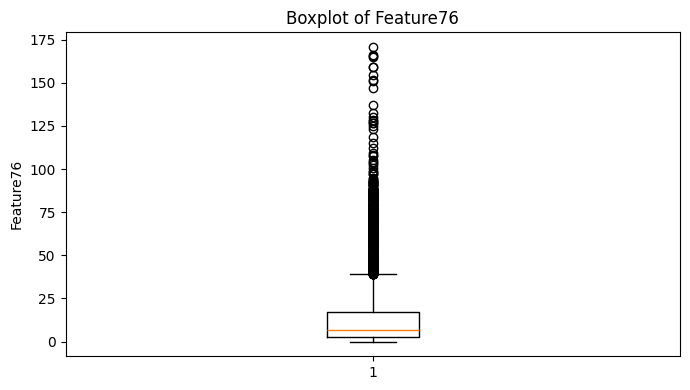

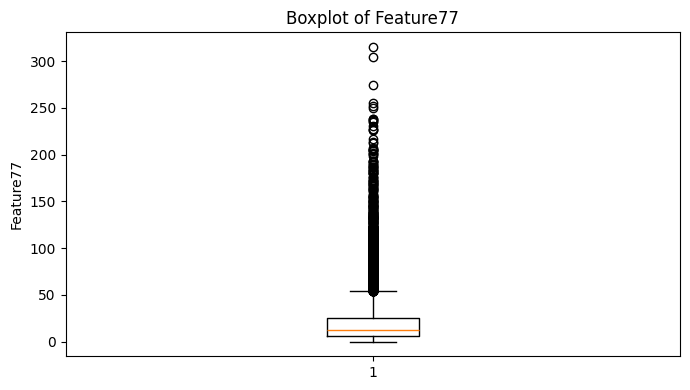

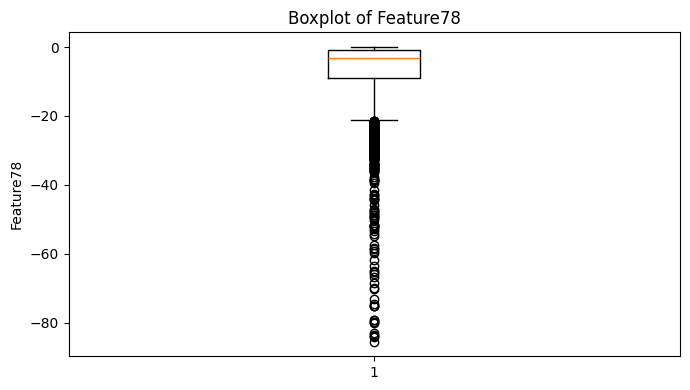

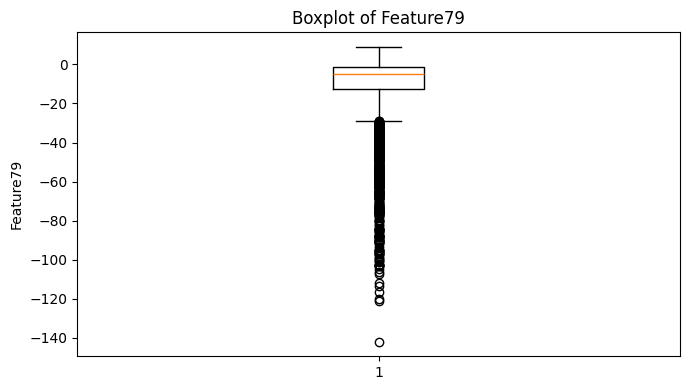

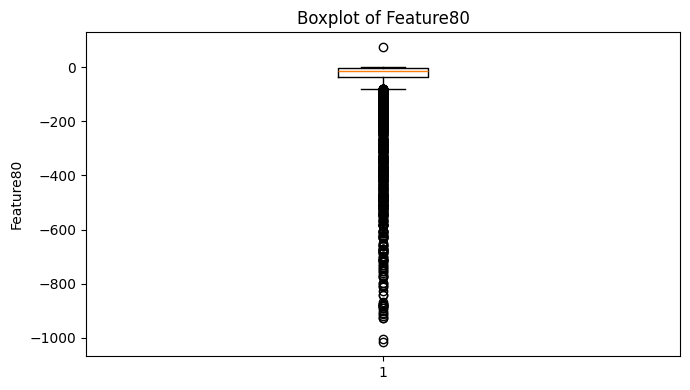

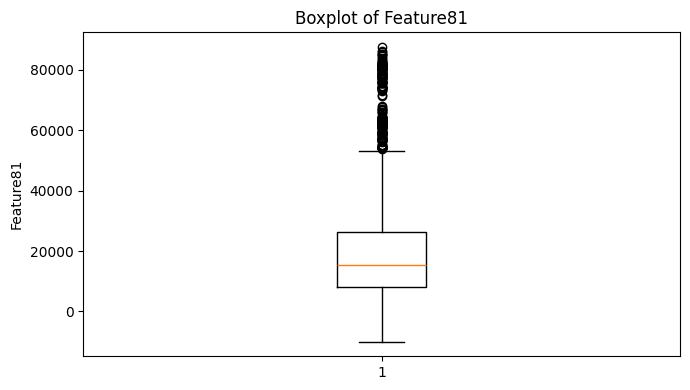

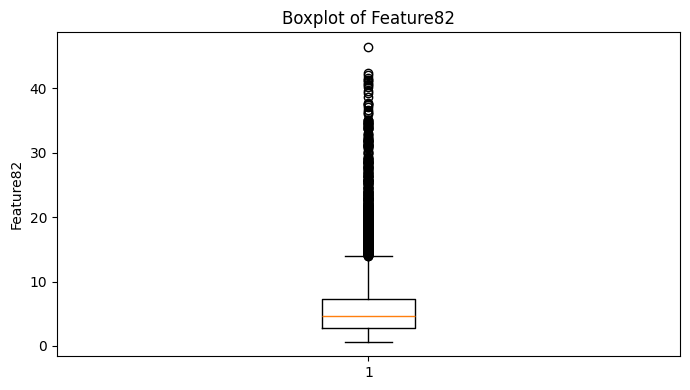

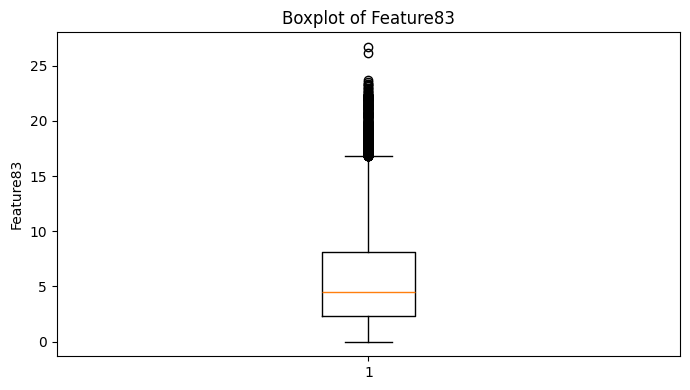

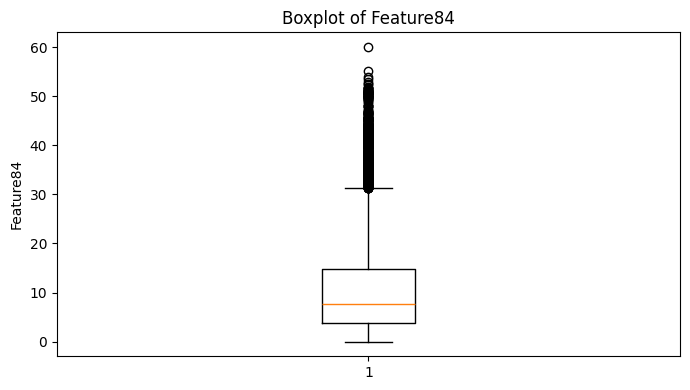

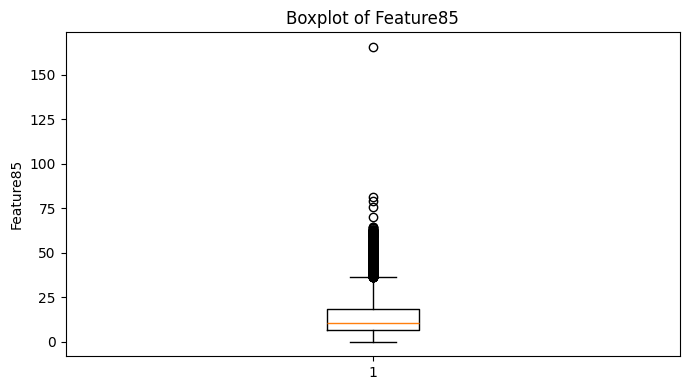

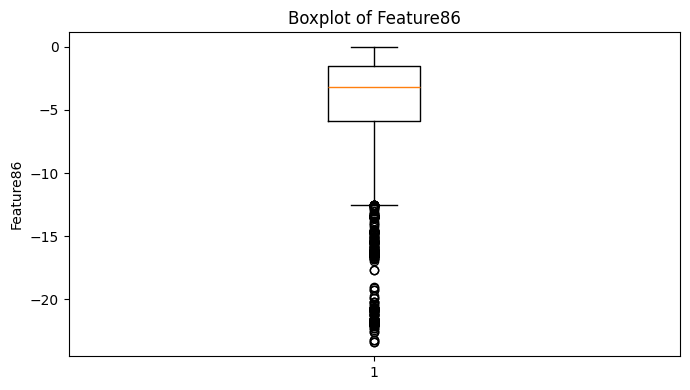

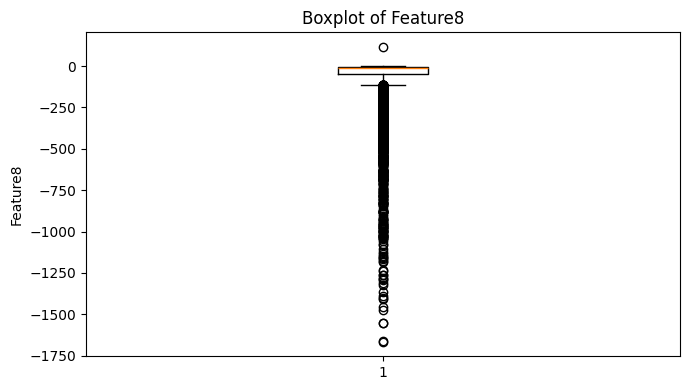

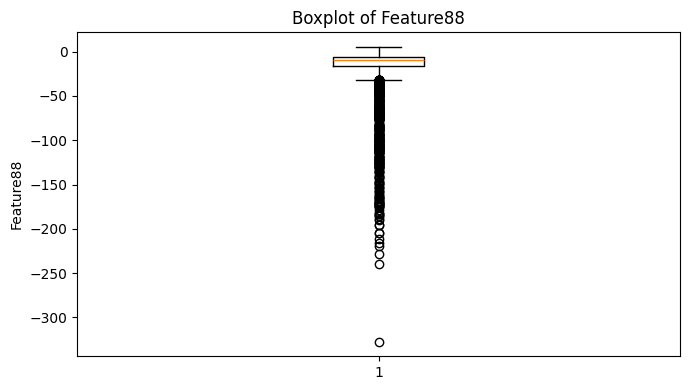

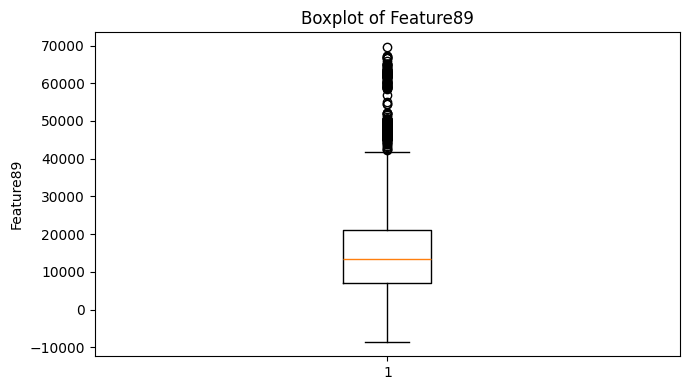

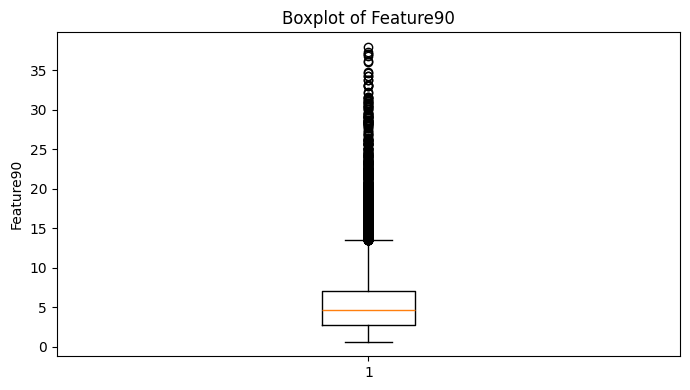

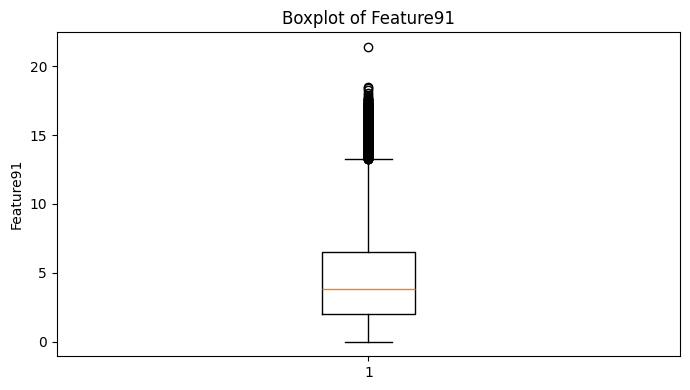

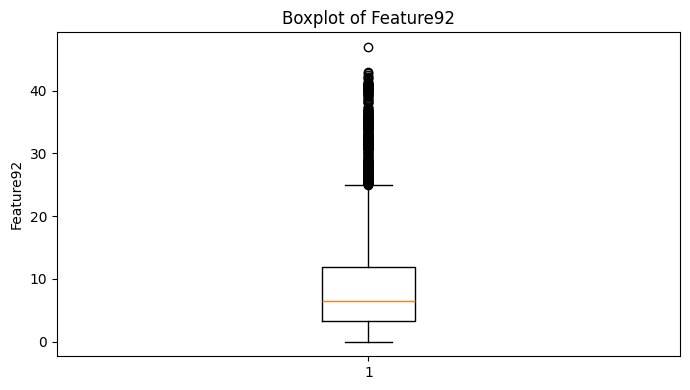

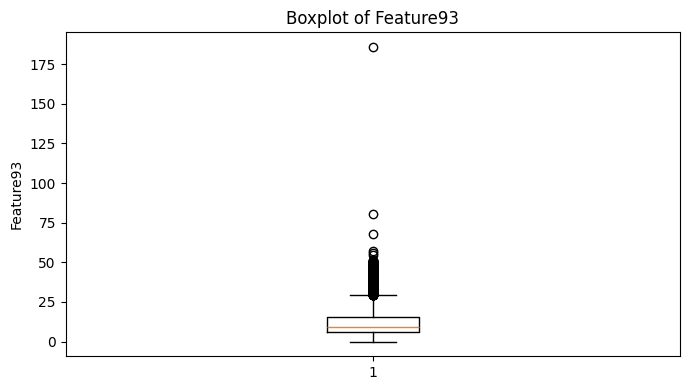

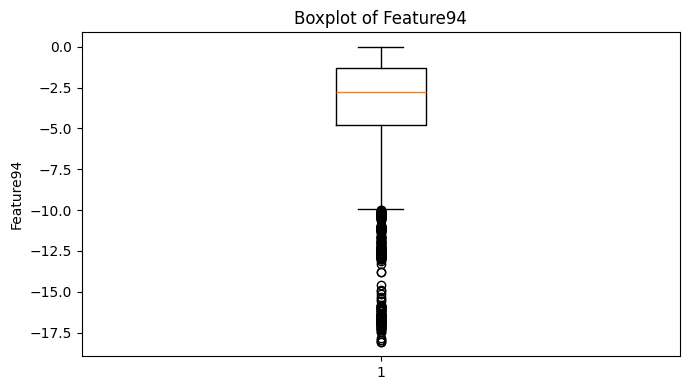

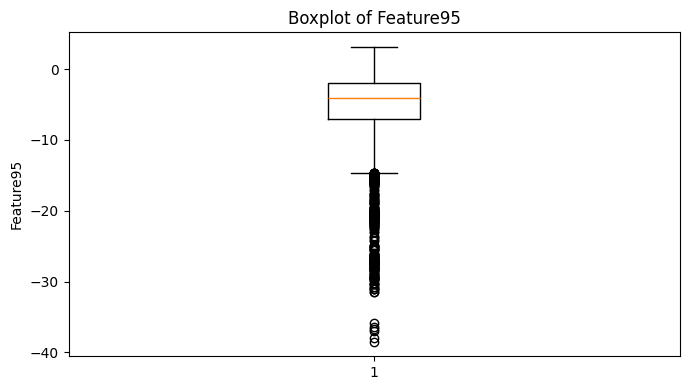

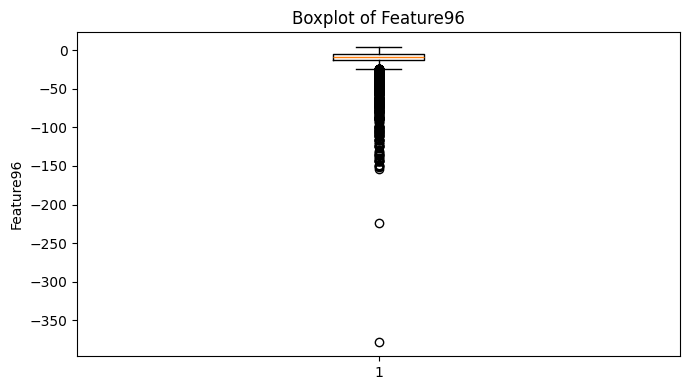

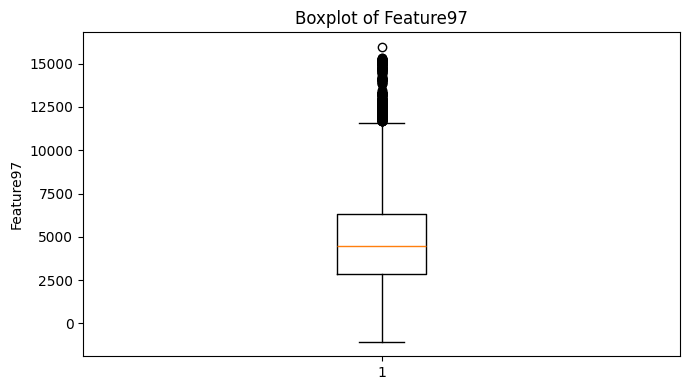

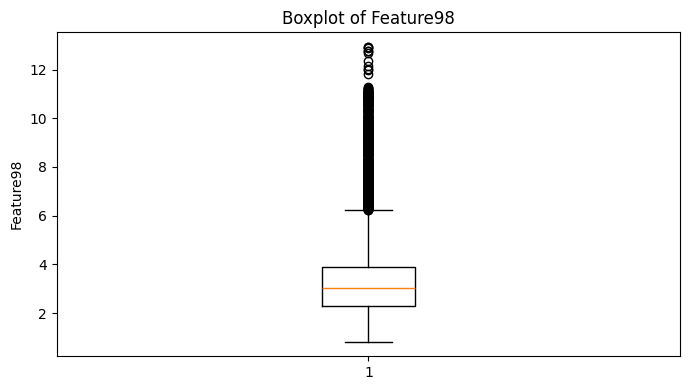

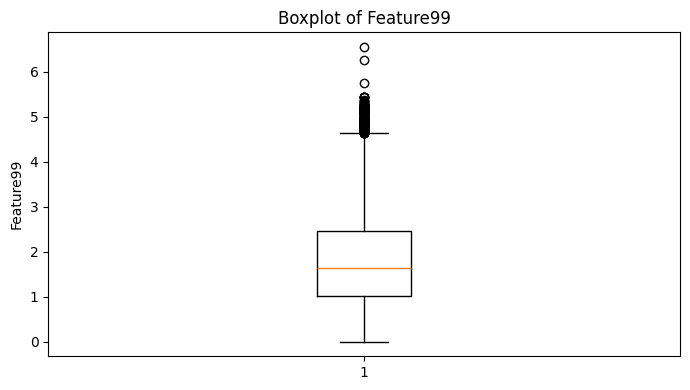

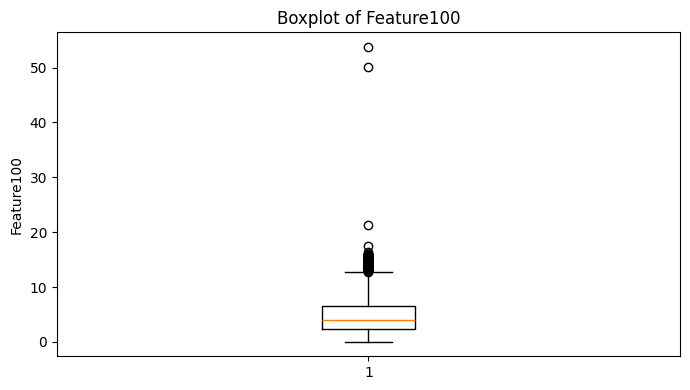

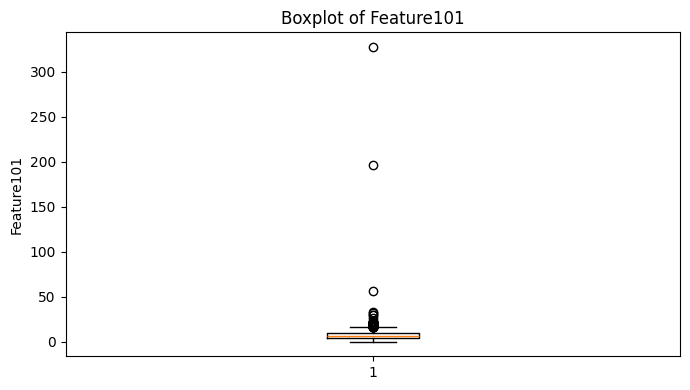

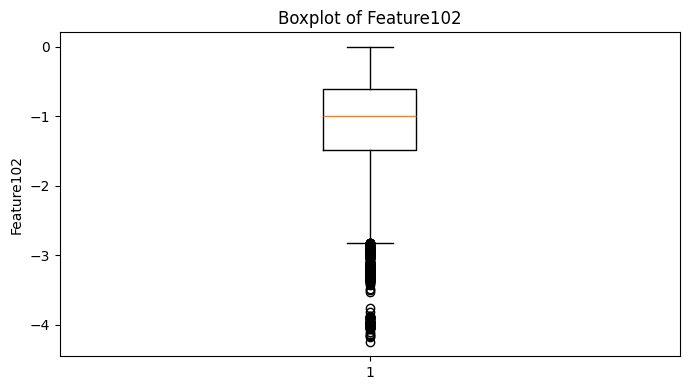

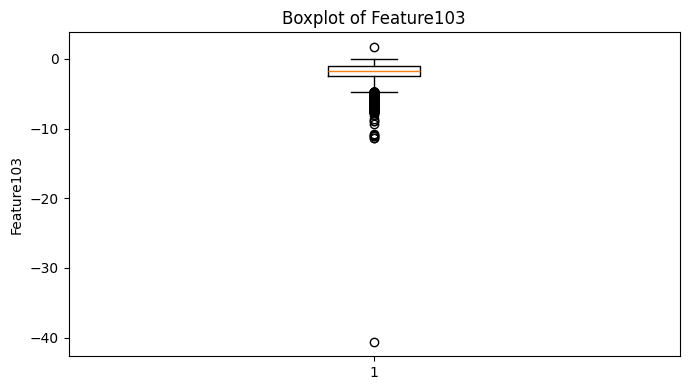

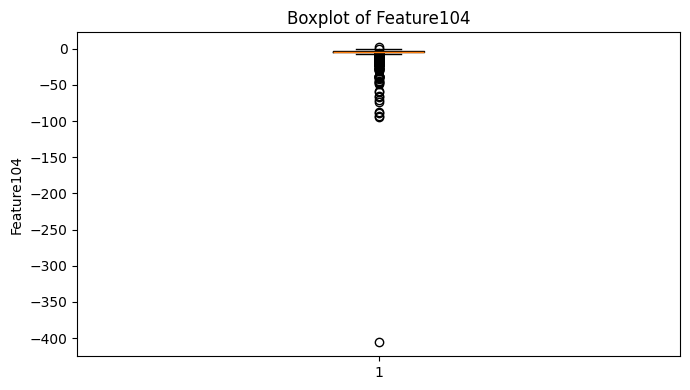

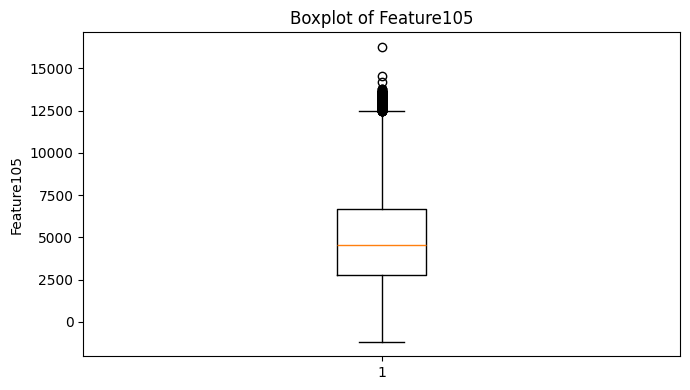

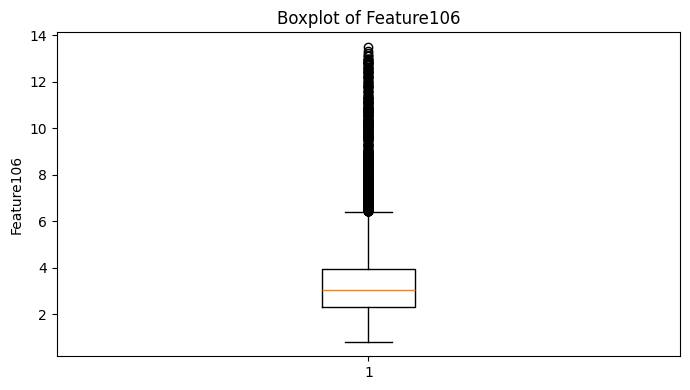

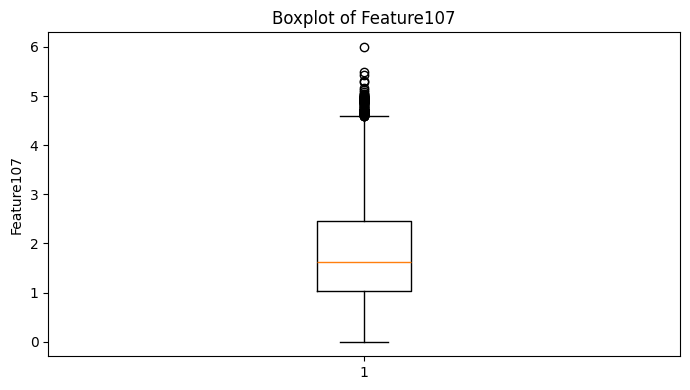

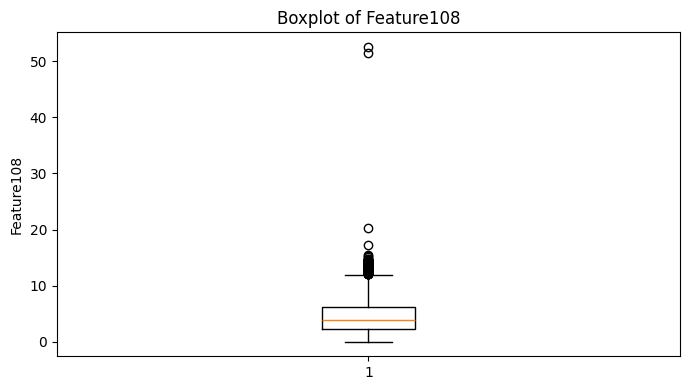

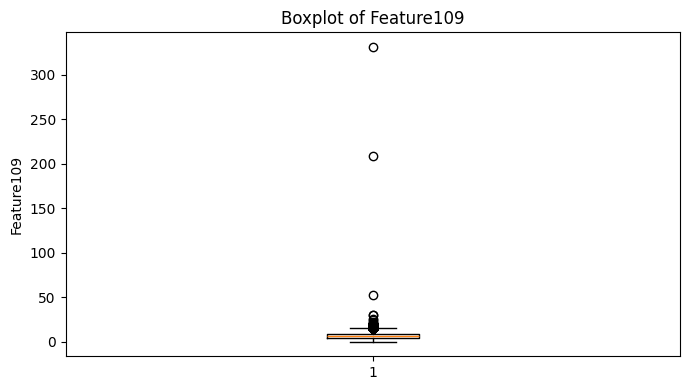

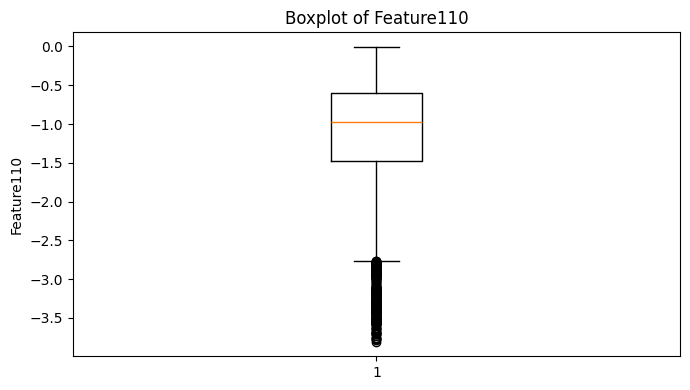

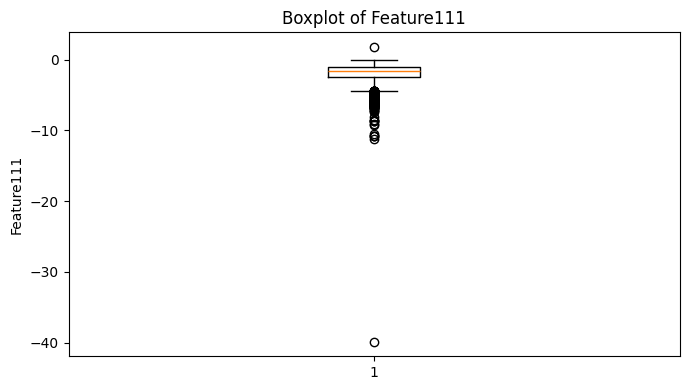

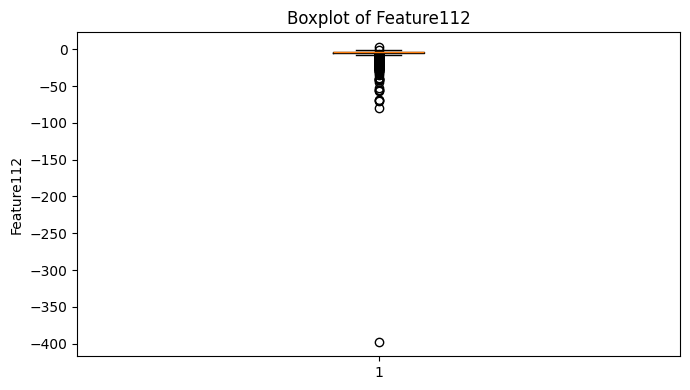

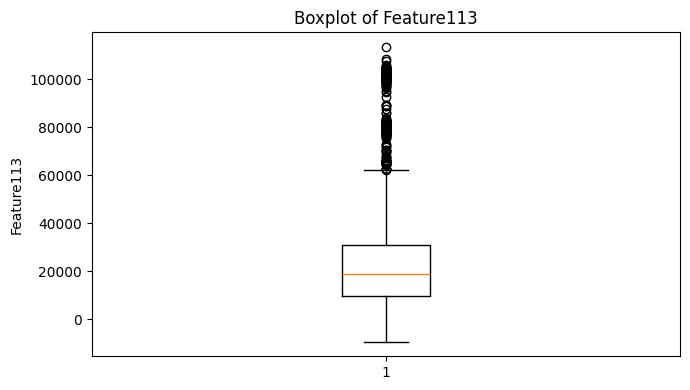

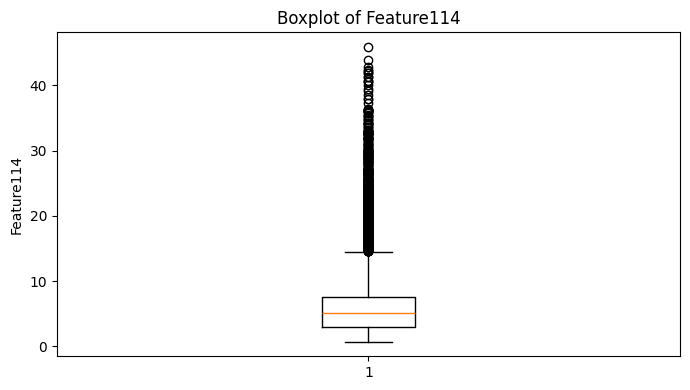

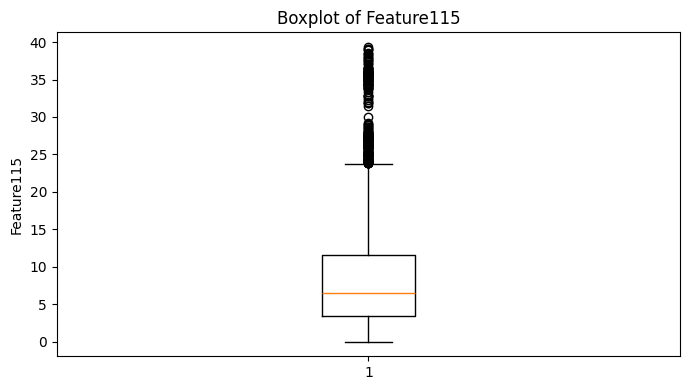

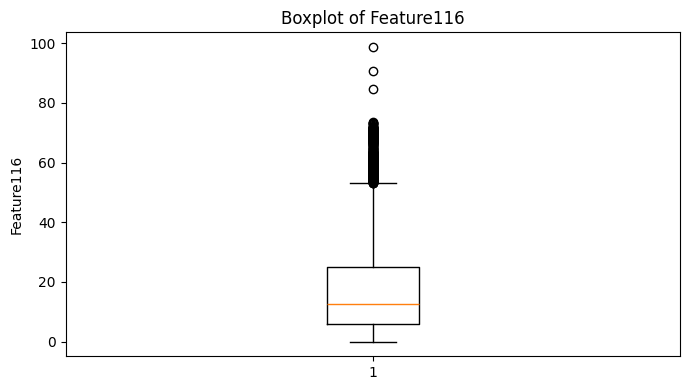

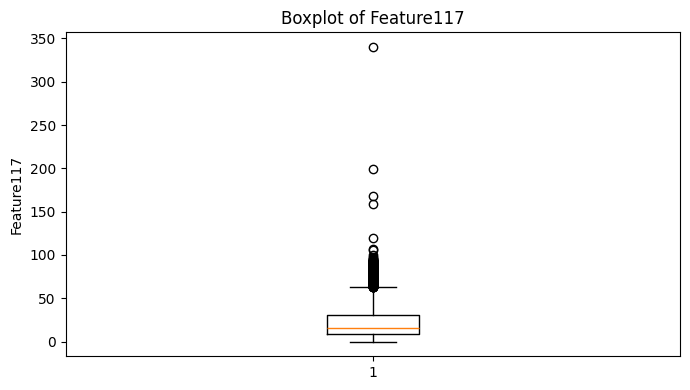

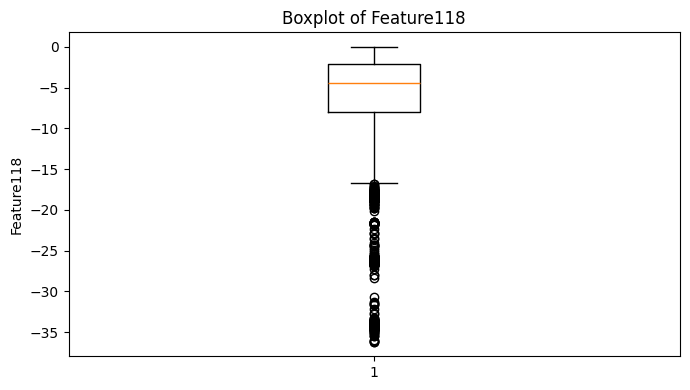

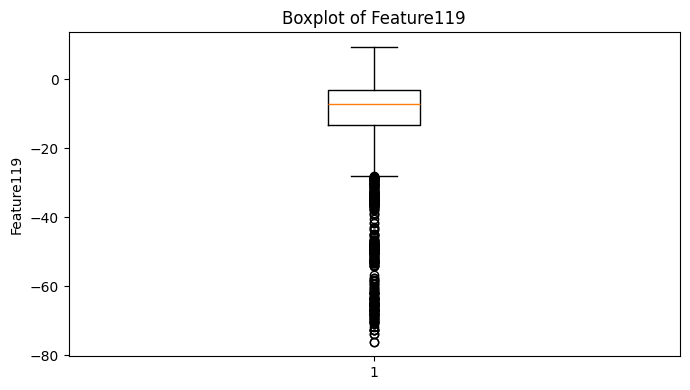

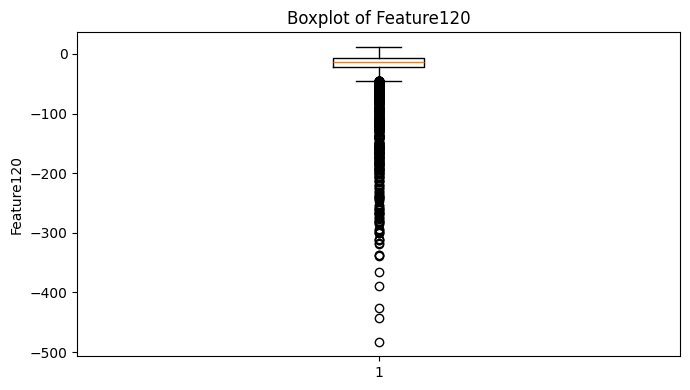

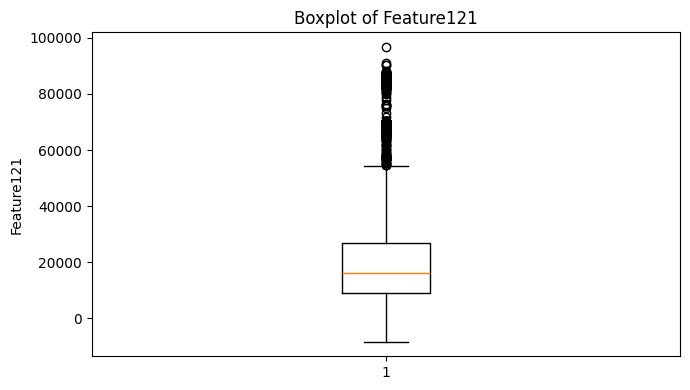

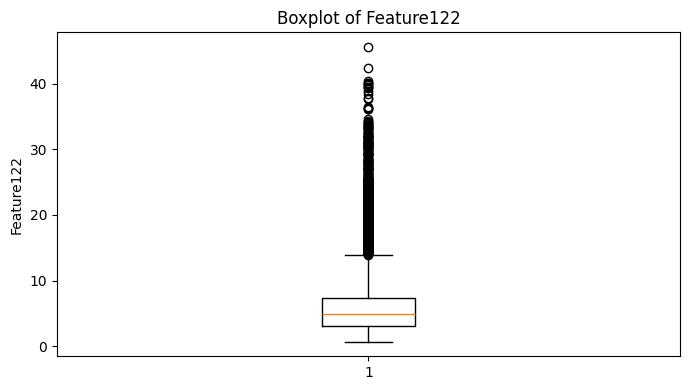

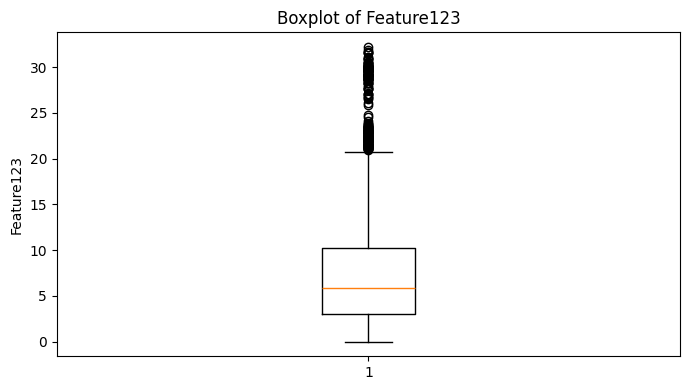

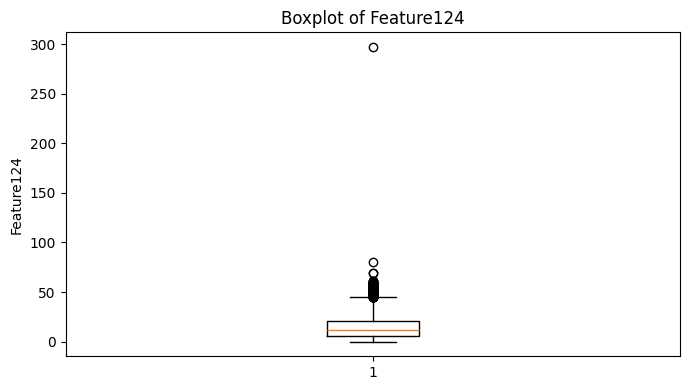

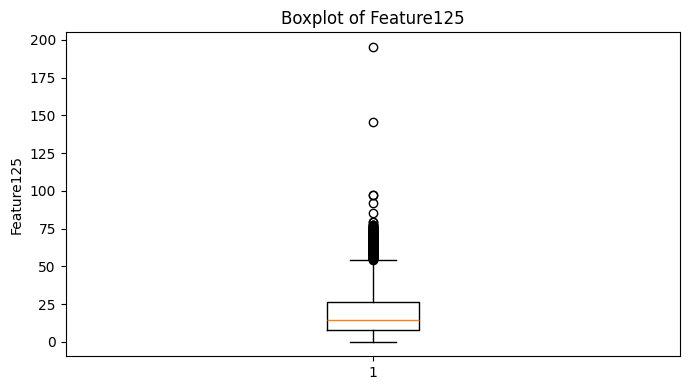

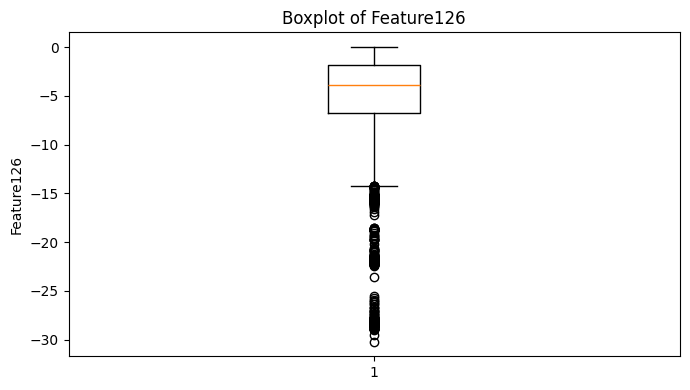

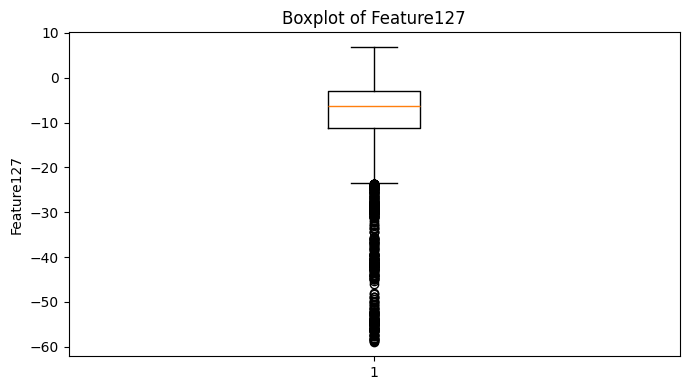

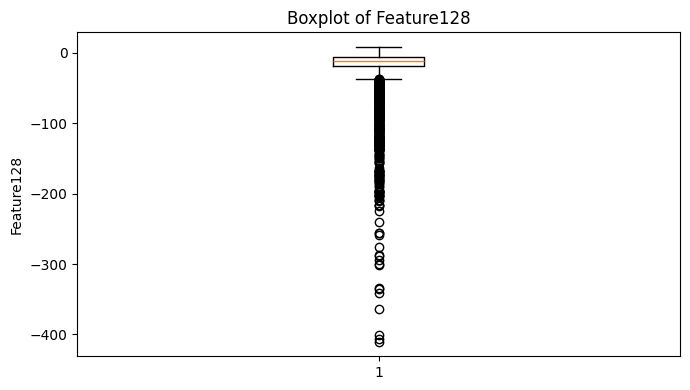

In [34]:
# Boxplots for selected sensor features

import matplotlib.pyplot as plt

selected_features = [
    "Feature1","Feature2","Feature3","Feature4","Feature5","Feature6","Feature7","Feature8","Feature9","Feature10","Feature11","Feature12","Feature13","Feature14","Feature15",
    "Feature16","Feature17","Feature18","Feature19","Feature20","Feature21","Feature22","Feature23","Feature24","Feature25","Feature26","Feature27","Feature28","Feature29","Feature30","Feature31",
    "Feature32","Feature33","Feature34","Feature35","Feature36","Feature37","Feature38","Feature39","Feature40","Feature41","Feature42","Feature43","Feature44","Feature45","Feature46","Feature47","Feature48","Feature49","Feature50","Feature51","Feature52","Feature53","Feature54","Feature56","Feature5","Feature58","Feature59","Feature60","Feature61","Feature62",
    "Feature64","Feature65","Feature66","Feature67","Feature68","Feature69","Feature70","Feature71","Feature72","Feature73","Feature74","Feature75","Feature76","Feature77","Feature78","Feature79","Feature80","Feature81","Feature82","Feature83","Feature84","Feature85","Feature86","Feature8","Feature88","Feature89","Feature90","Feature91","Feature92","Feature93","Feature94","Feature95",
    "Feature96","Feature97","Feature98","Feature99","Feature100","Feature101","Feature102","Feature103","Feature104","Feature105","Feature106","Feature107","Feature108","Feature109","Feature110","Feature111","Feature112","Feature113","Feature114","Feature115","Feature116","Feature117","Feature118","Feature119","Feature120","Feature121","Feature122","Feature123","Feature124","Feature125","Feature126","Feature127",
    "Feature128"
]

for feature in selected_features:

    plt.figure(figsize=(7, 4))

    plt.boxplot(
        df[feature].dropna()
    )

    plt.ylabel(feature)
    plt.title(f"Boxplot of {feature}")

    plt.tight_layout()
    plt.show()

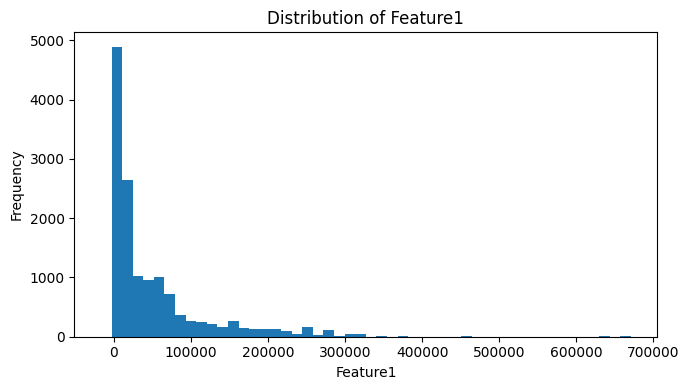

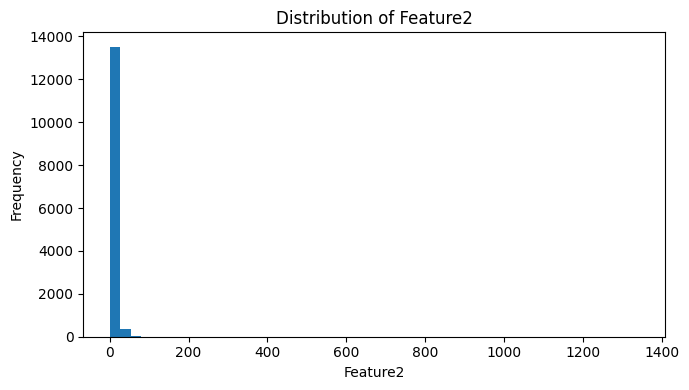

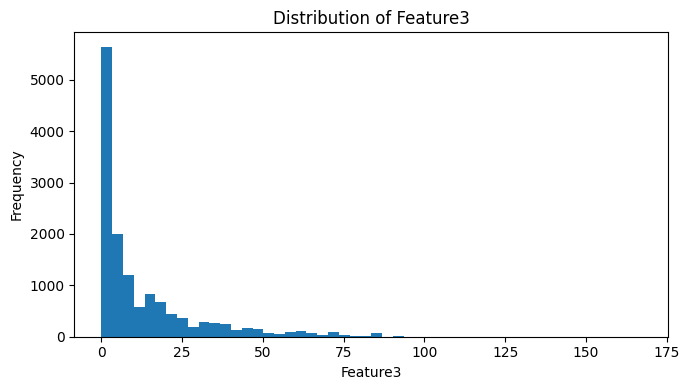

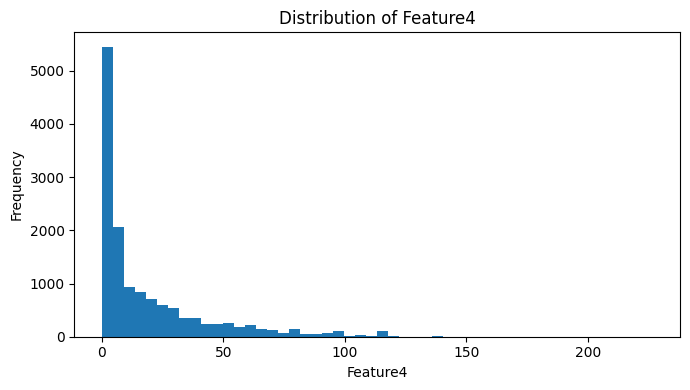

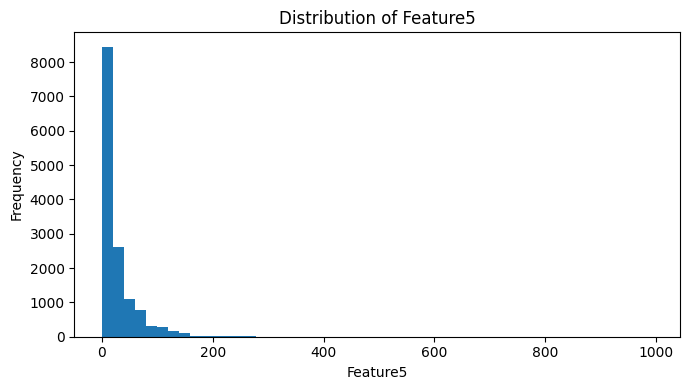

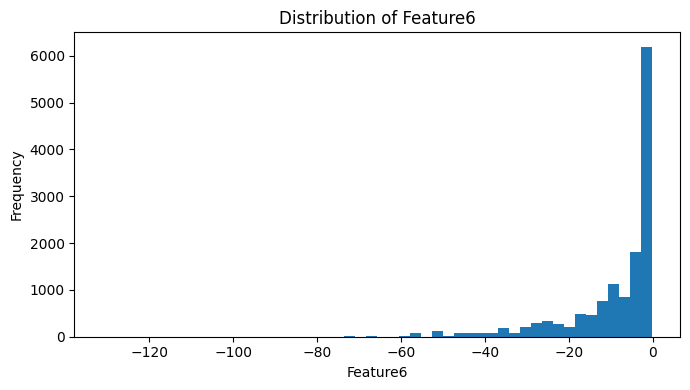

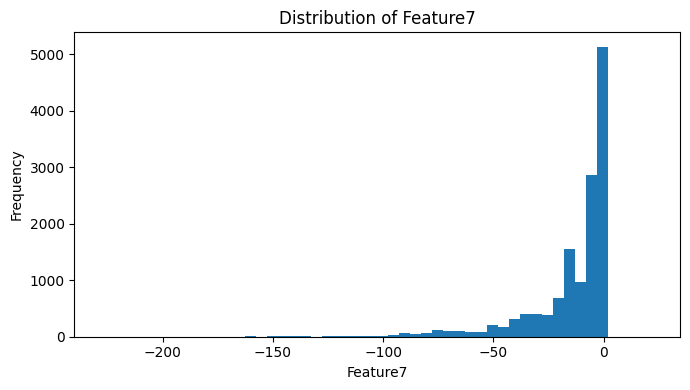

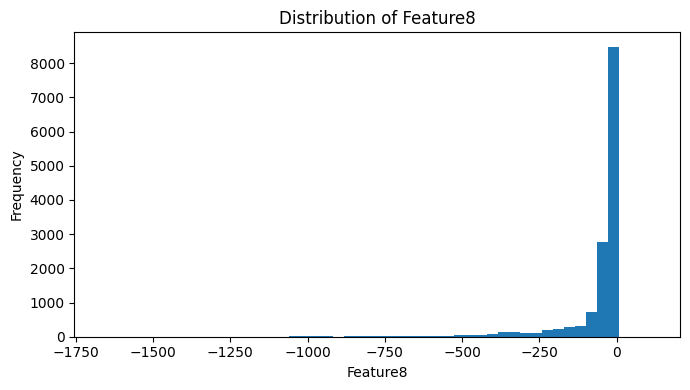

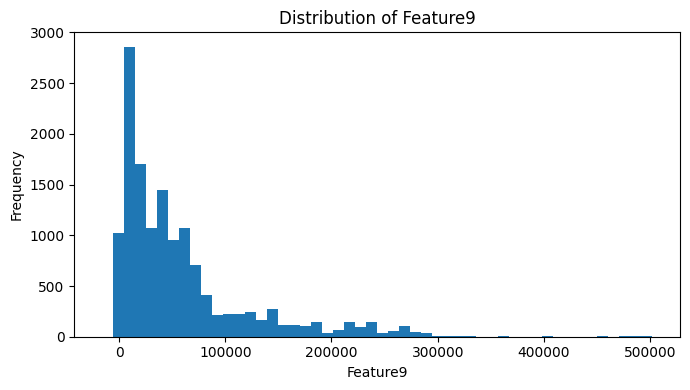

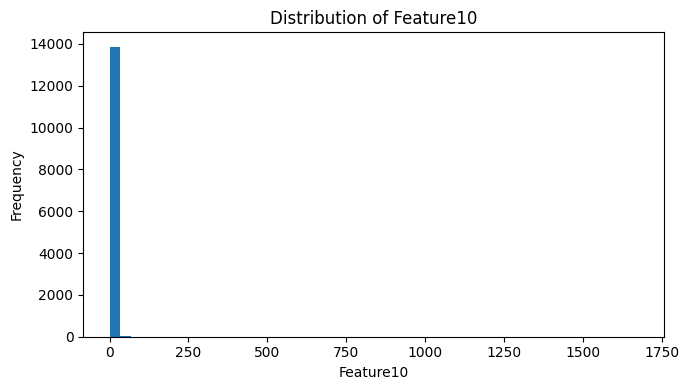

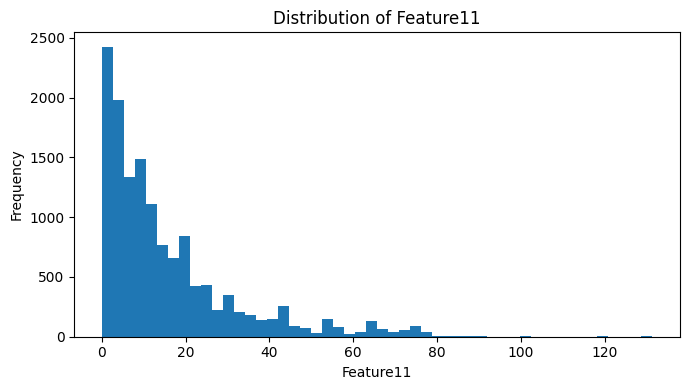

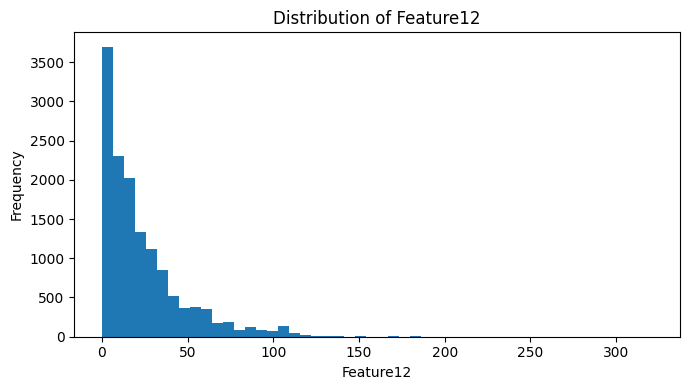

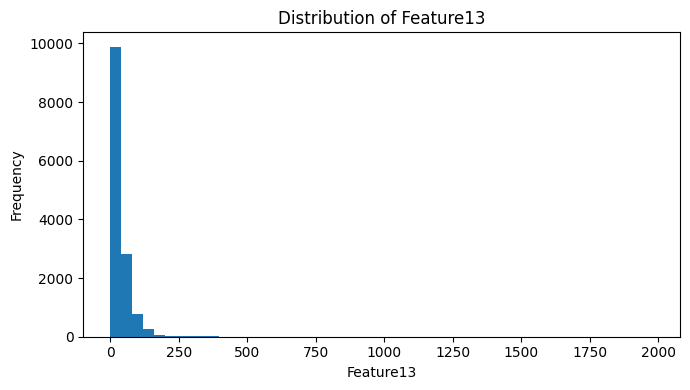

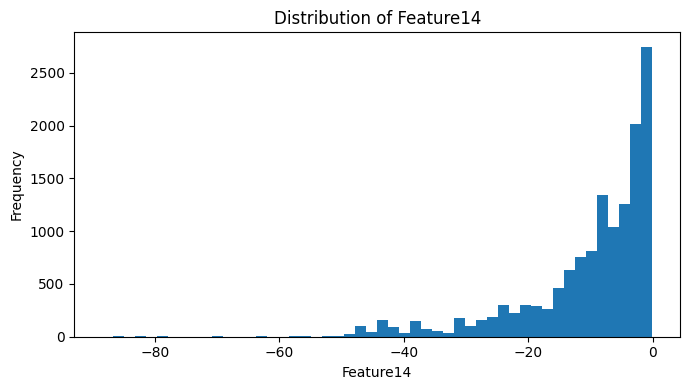

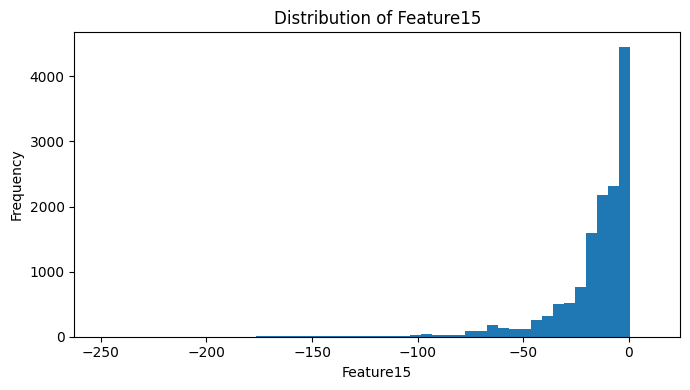

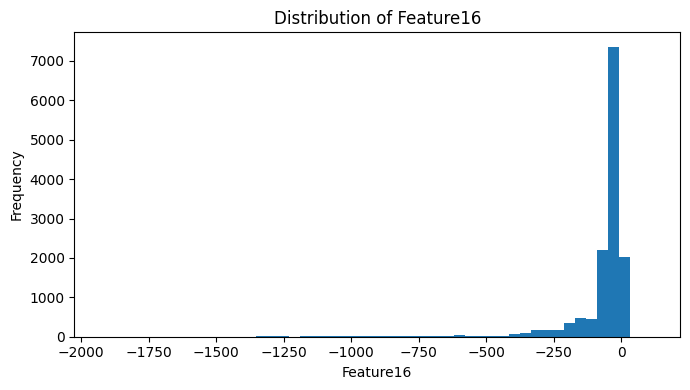

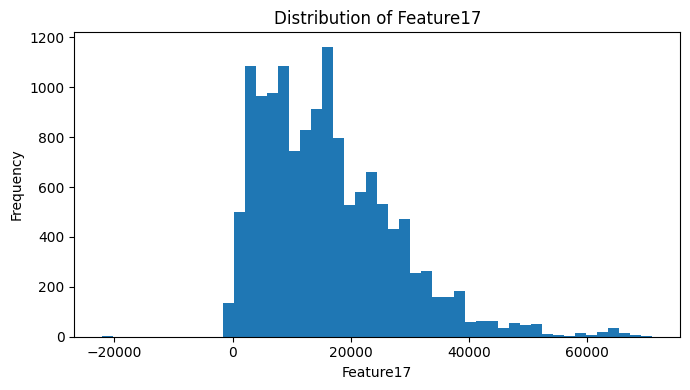

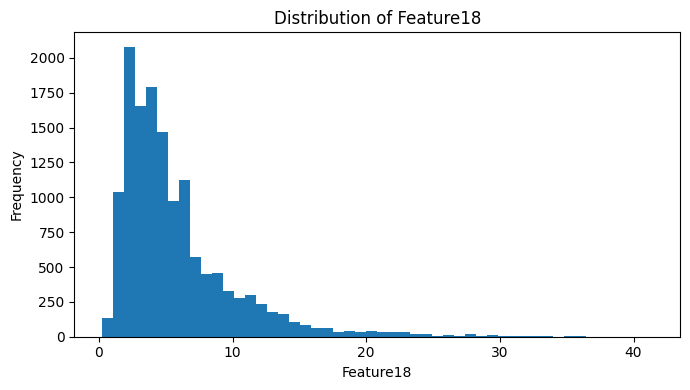

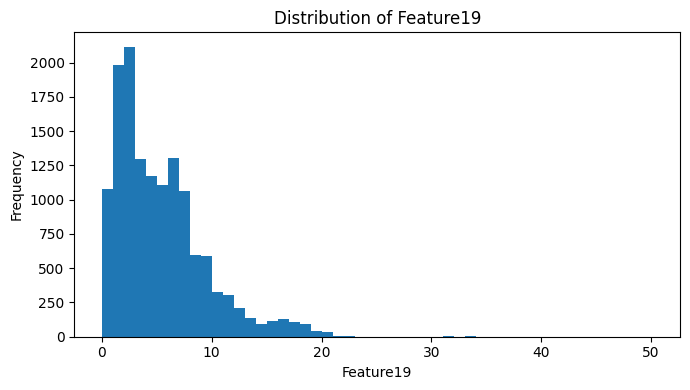

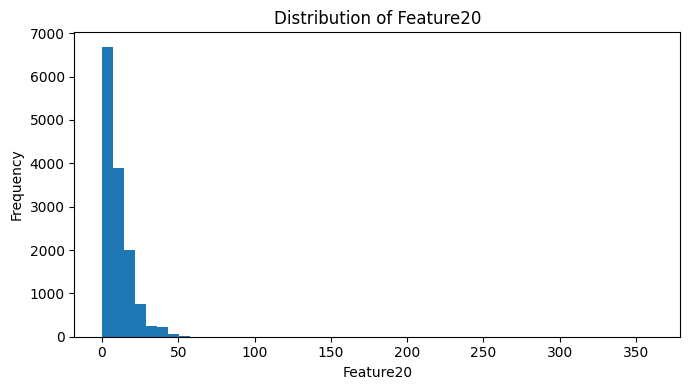

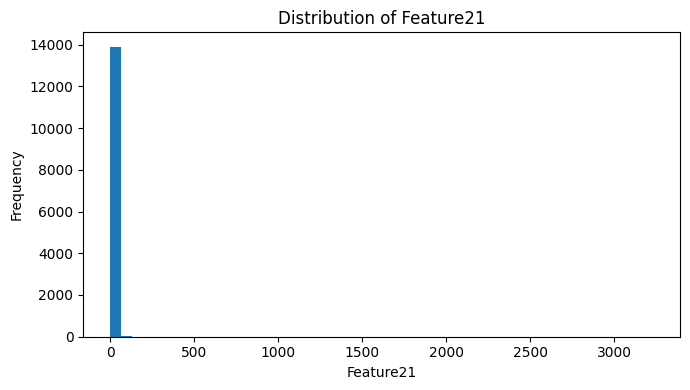

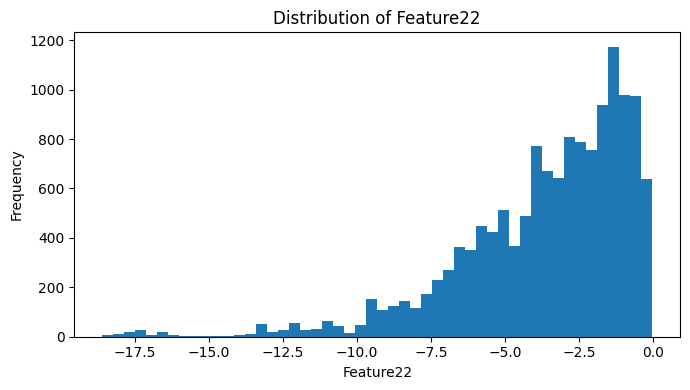

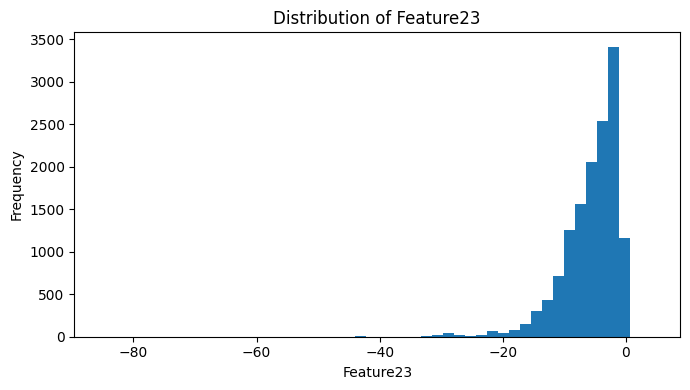

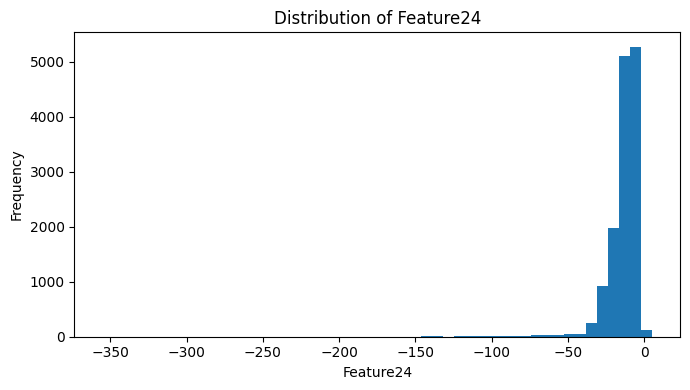

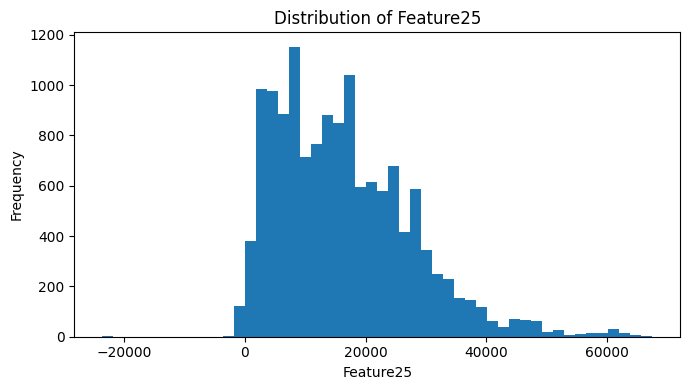

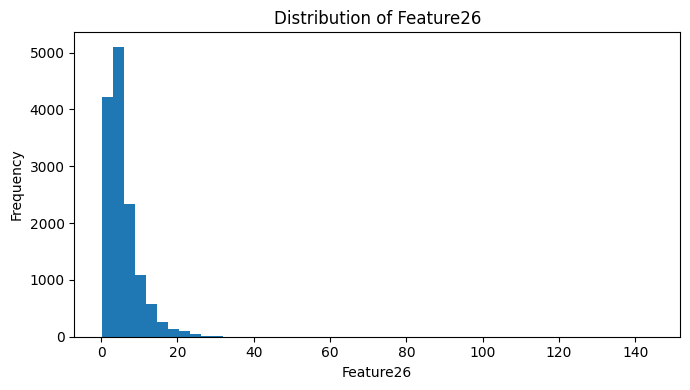

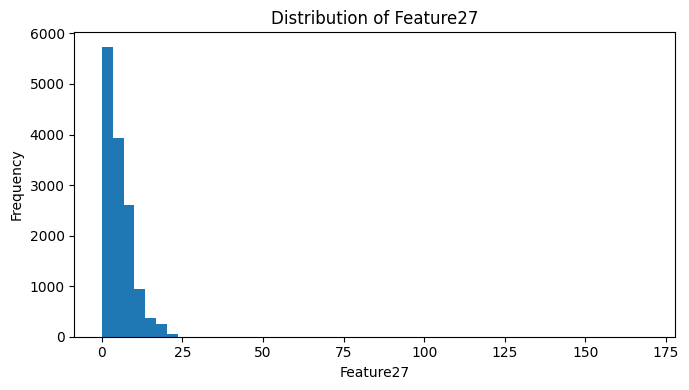

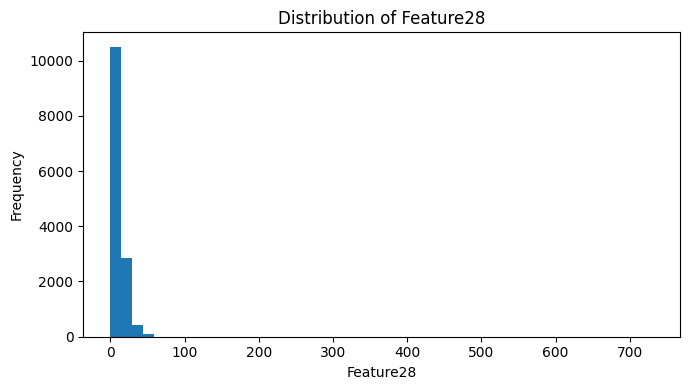

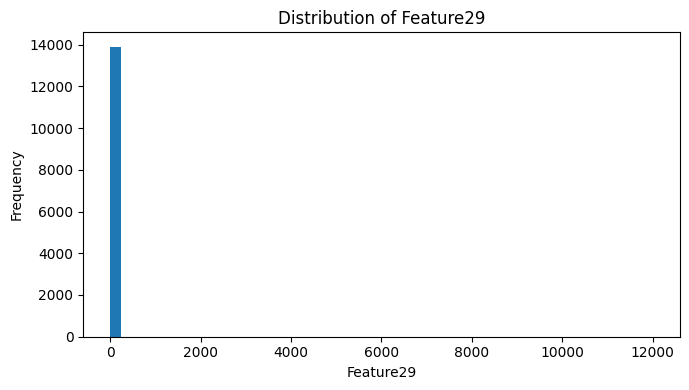

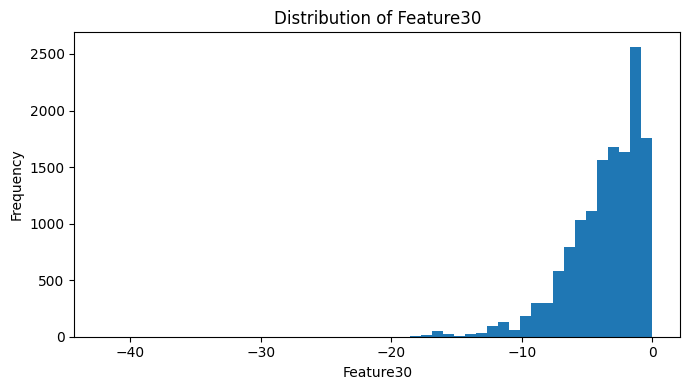

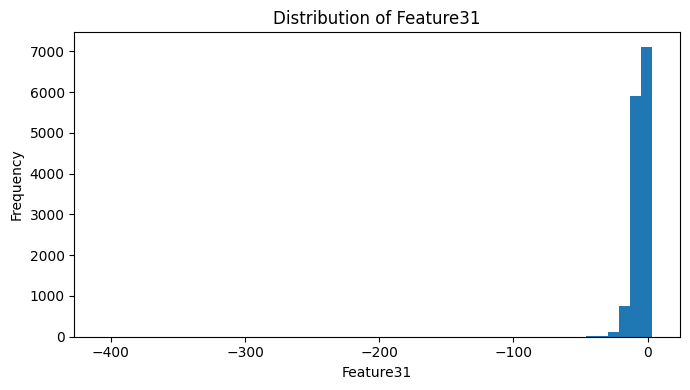

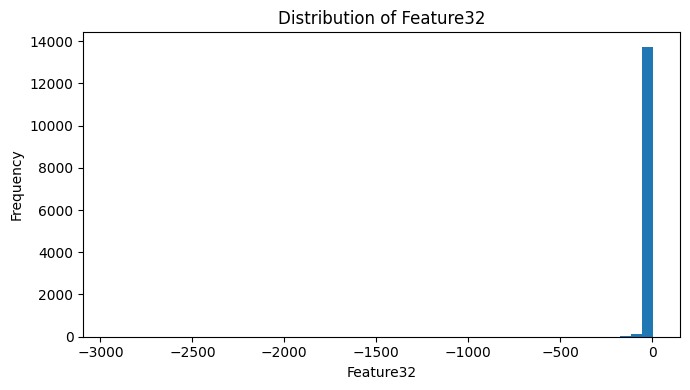

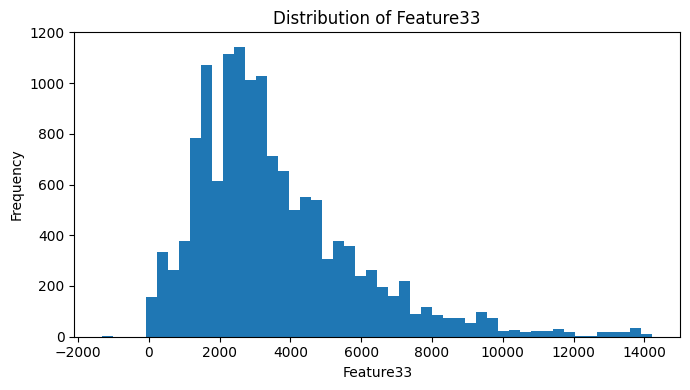

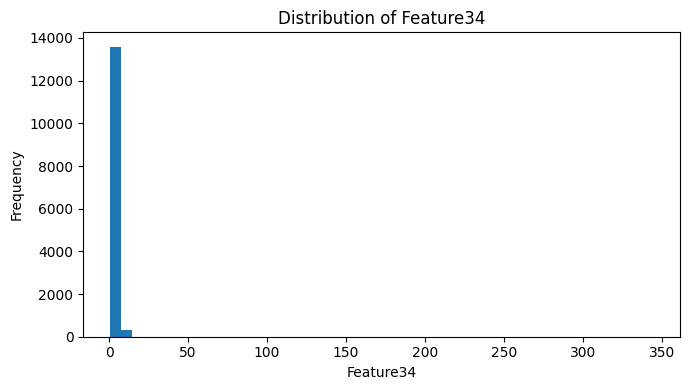

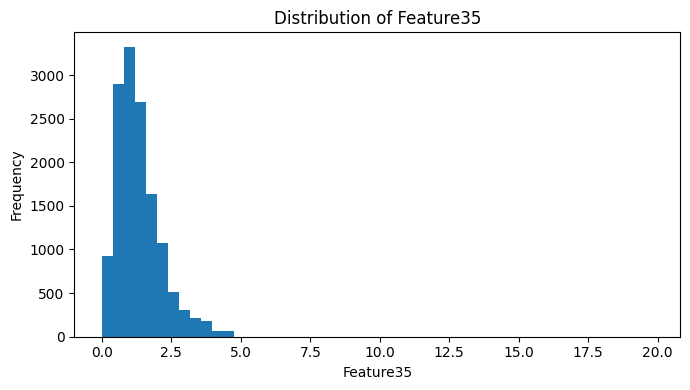

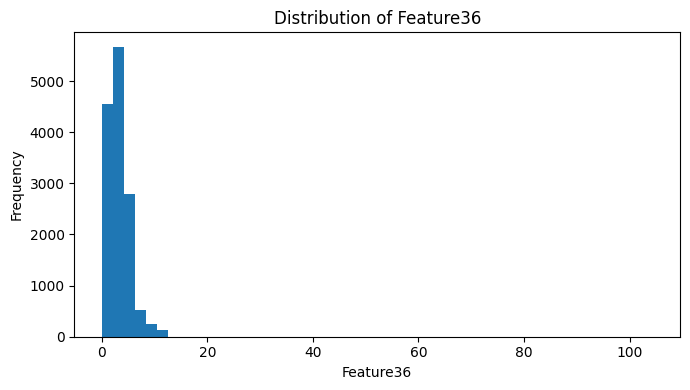

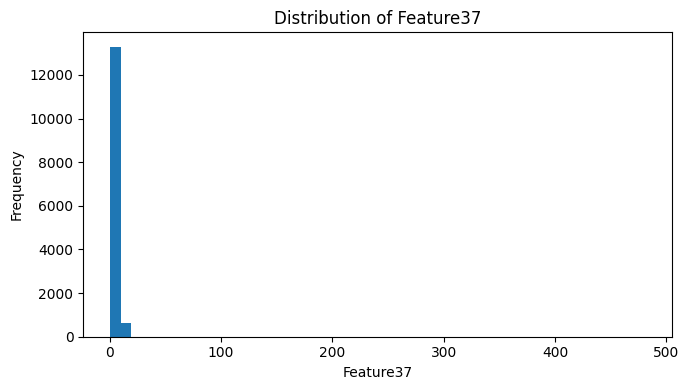

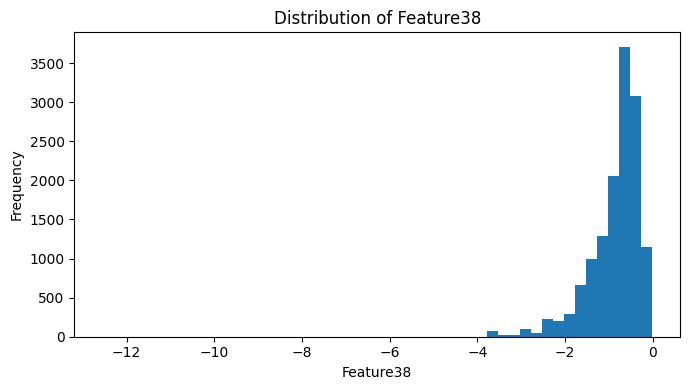

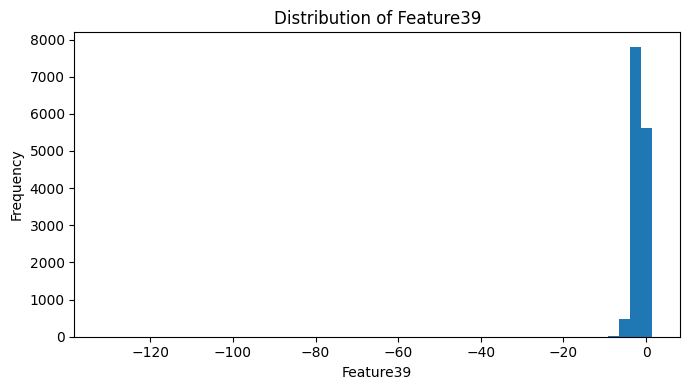

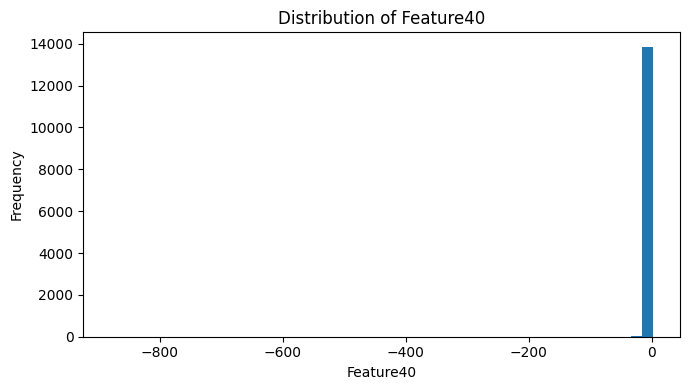

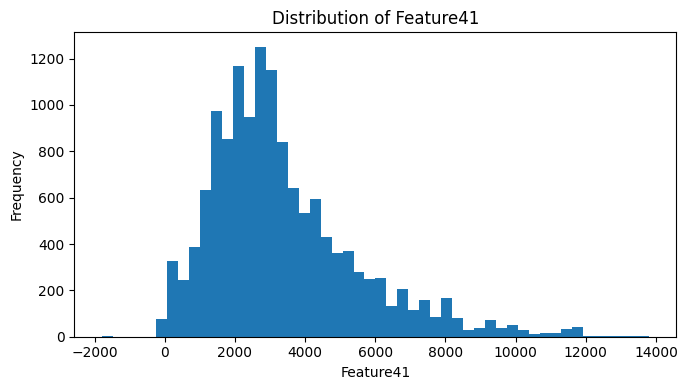

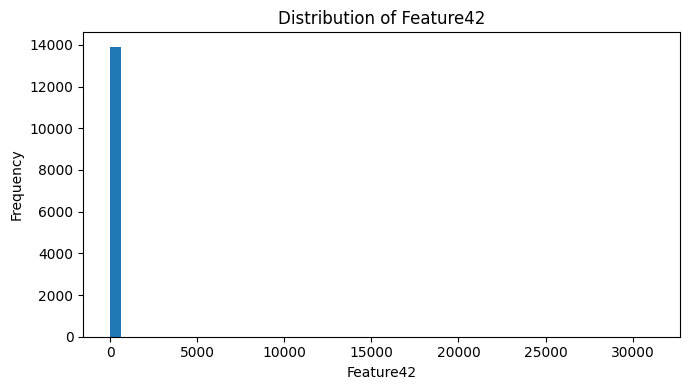

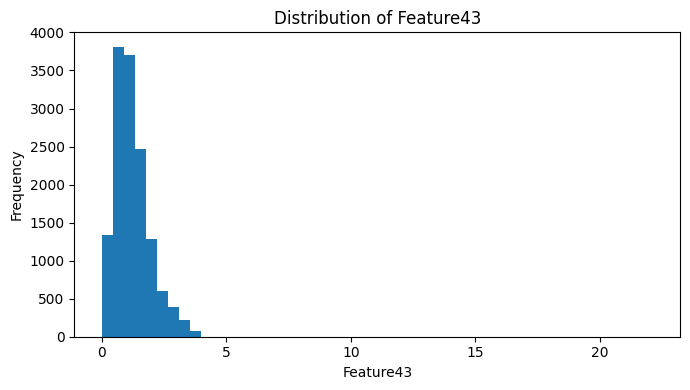

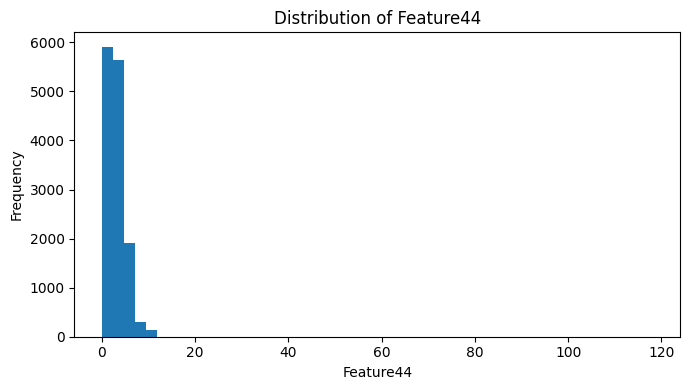

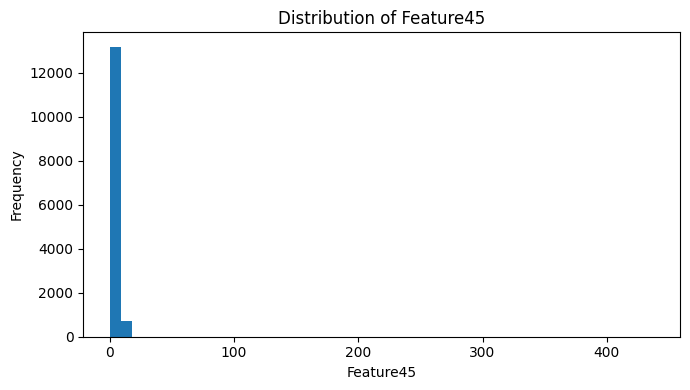

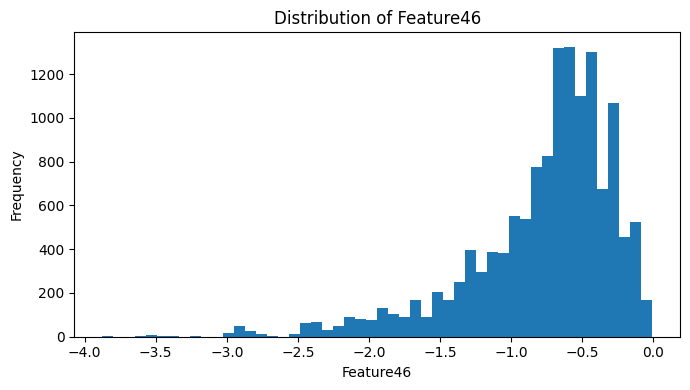

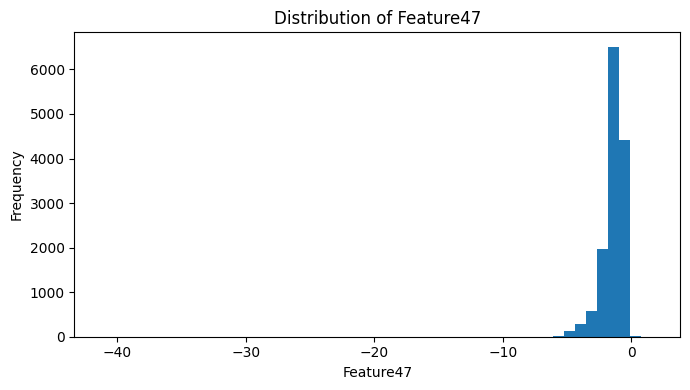

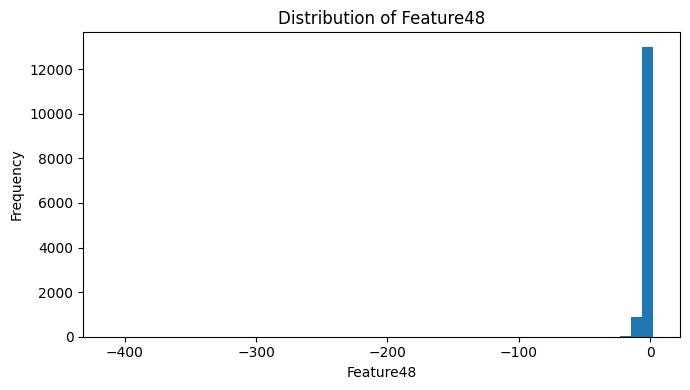

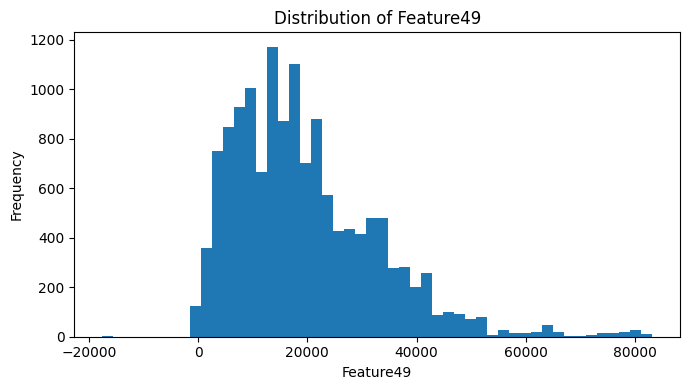

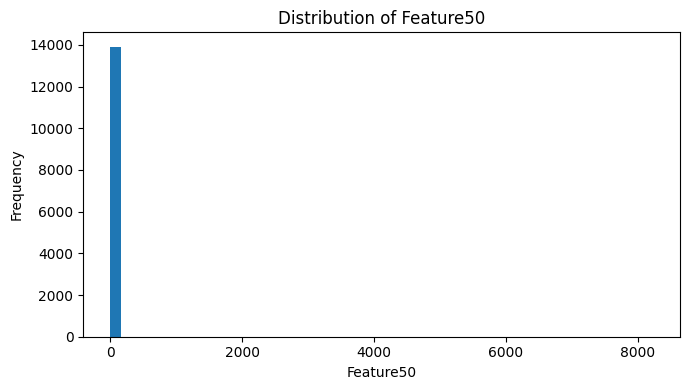

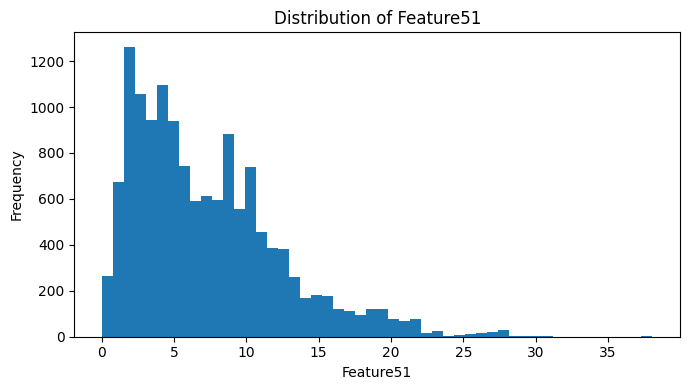

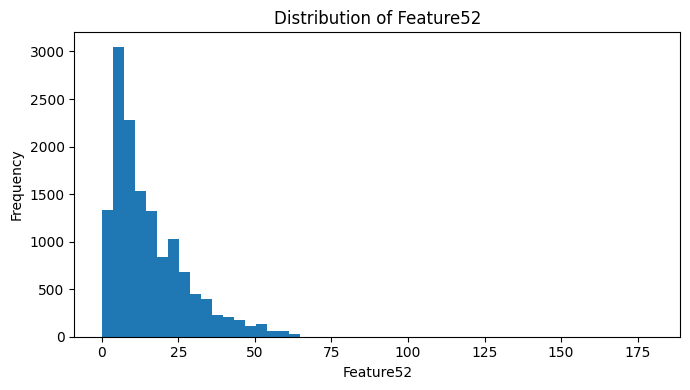

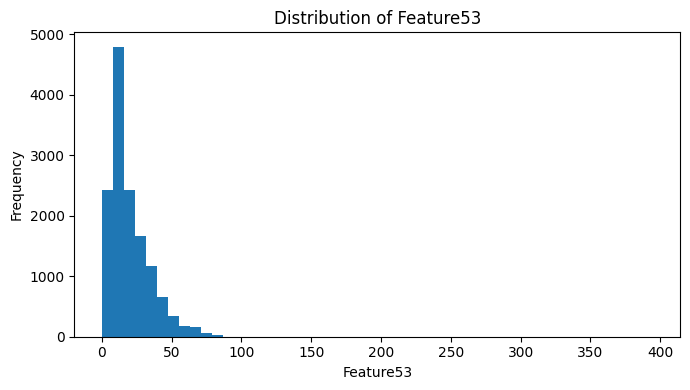

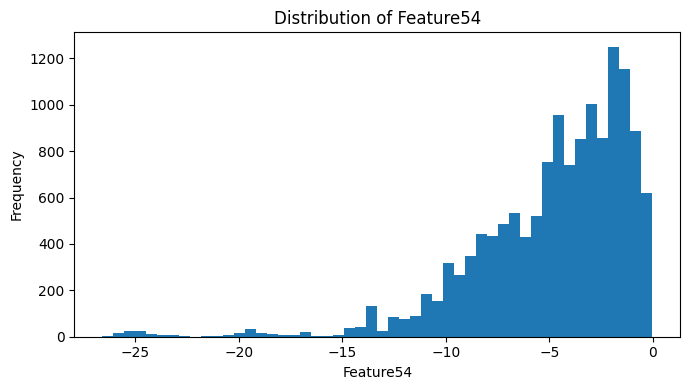

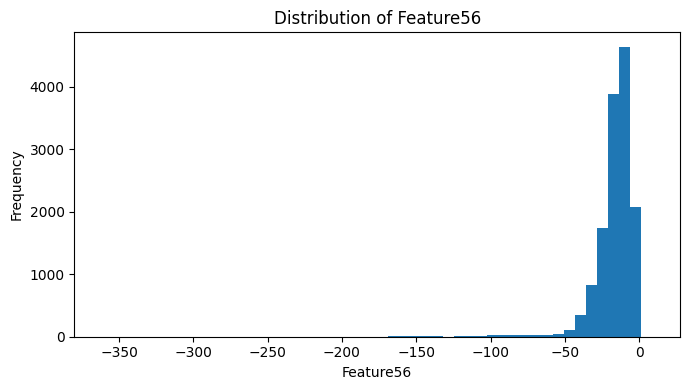

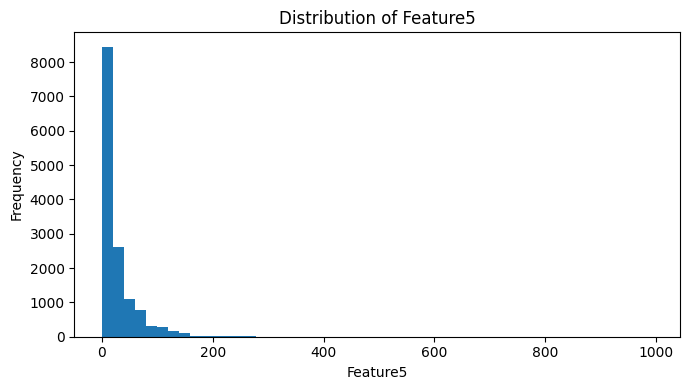

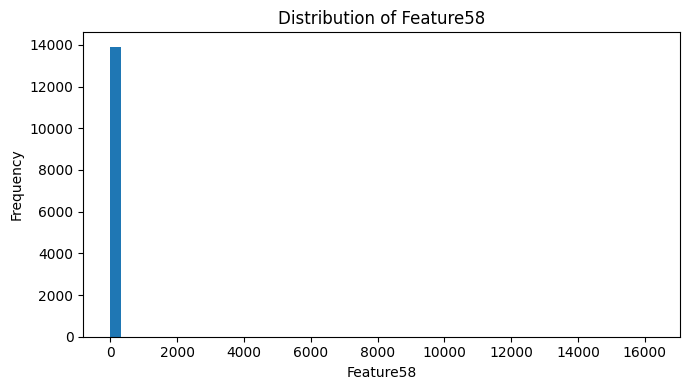

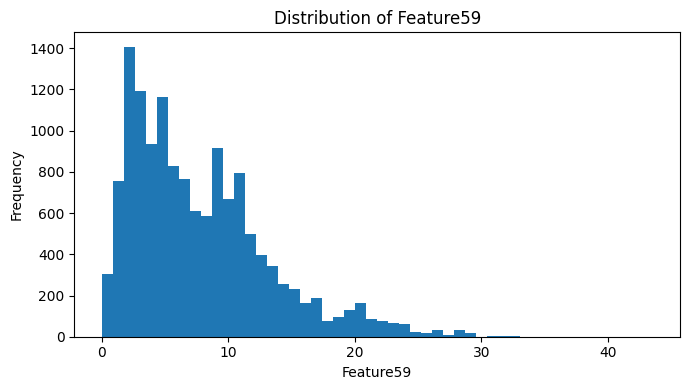

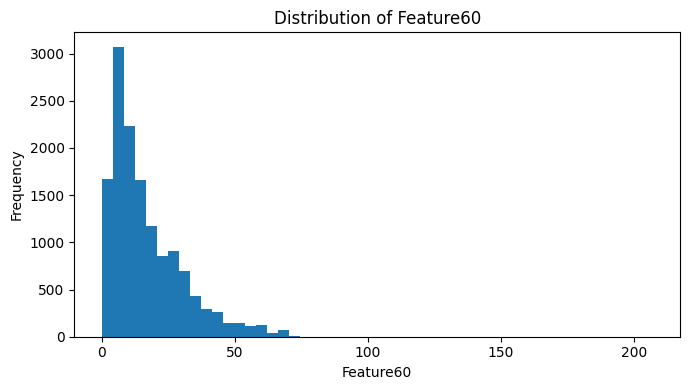

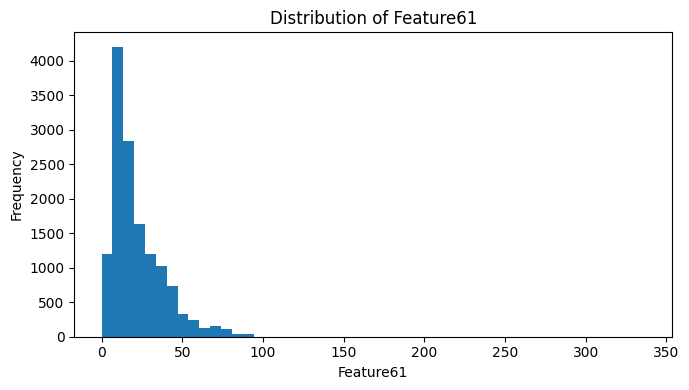

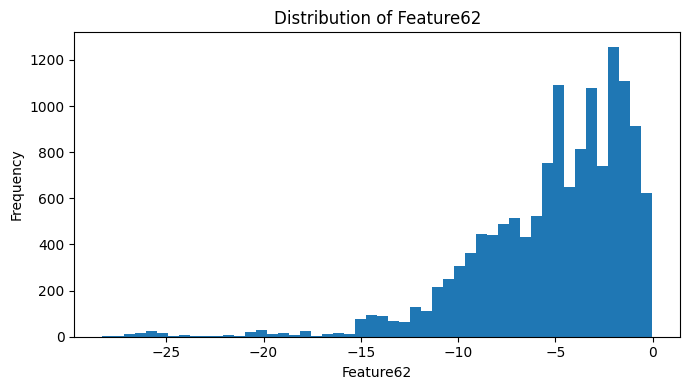

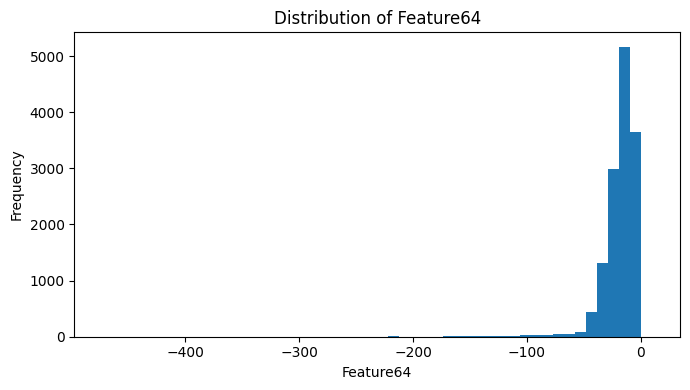

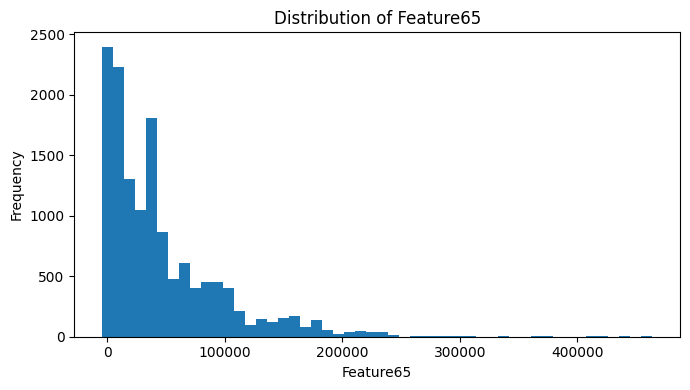

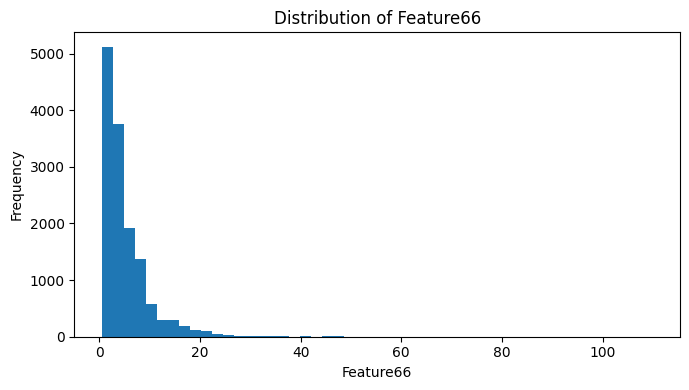

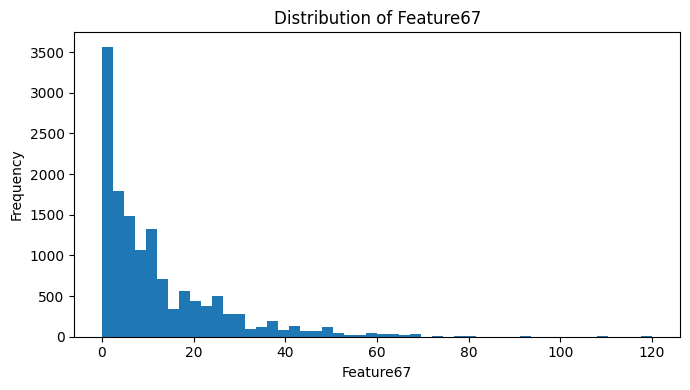

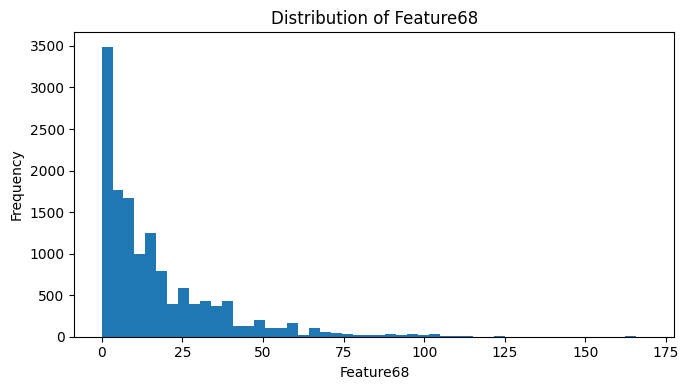

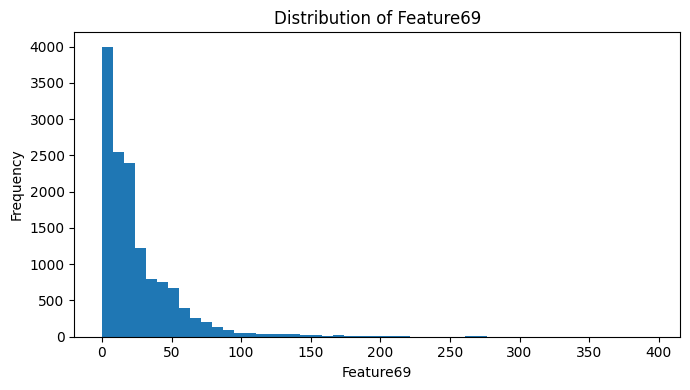

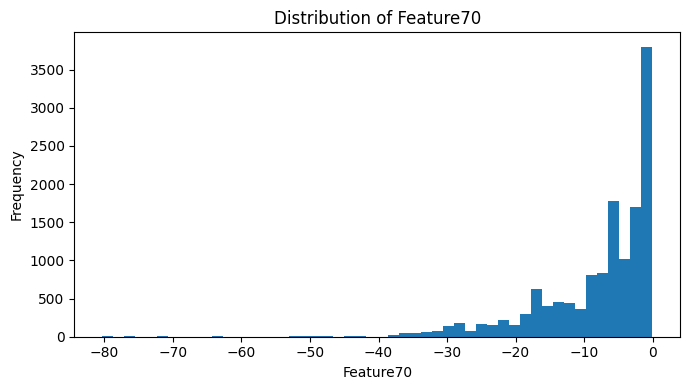

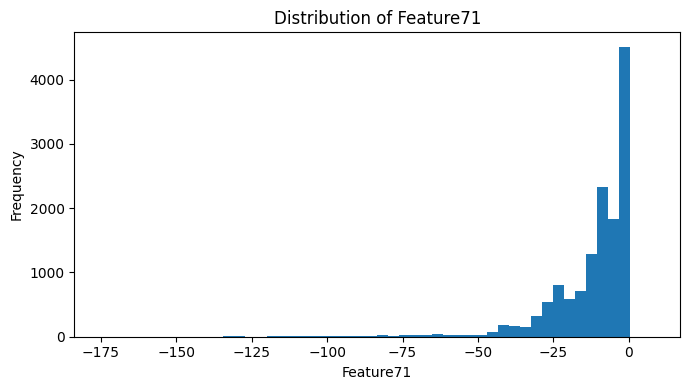

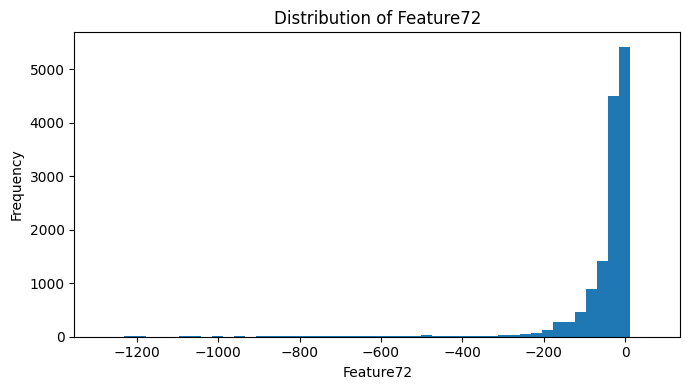

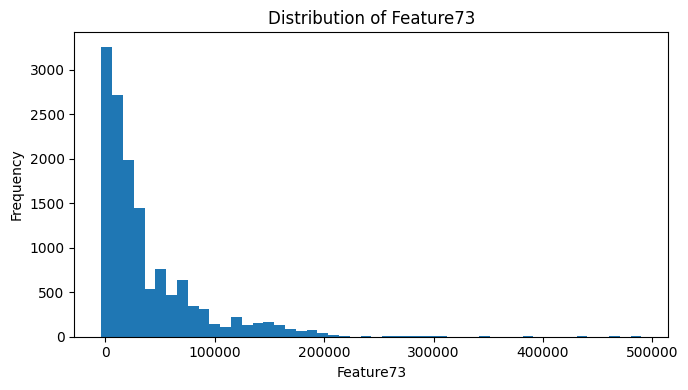

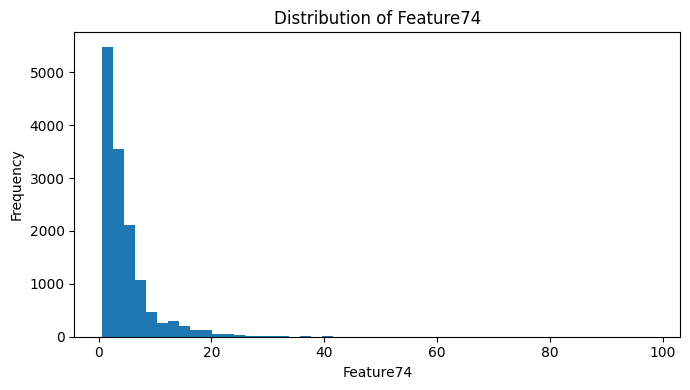

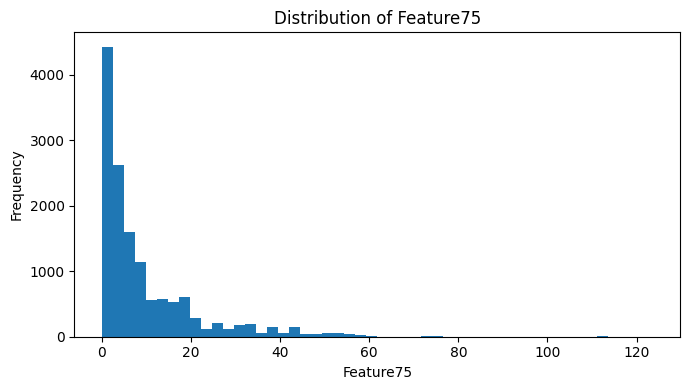

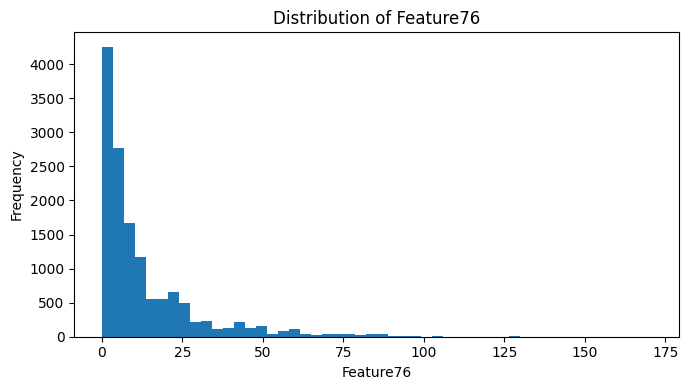

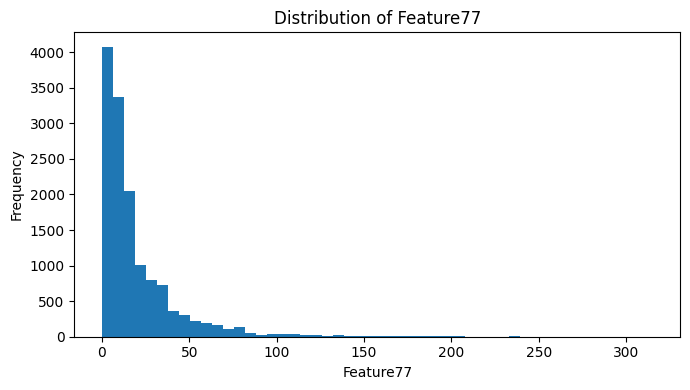

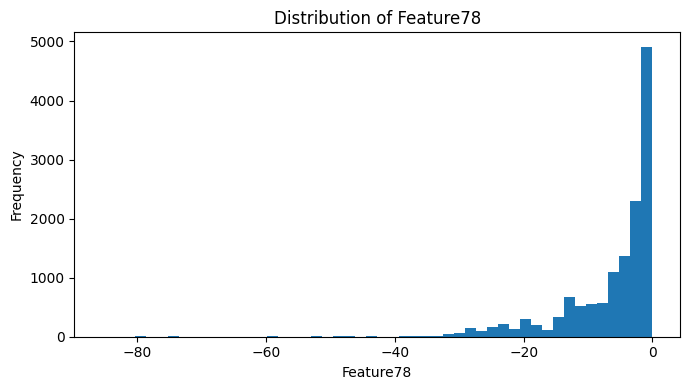

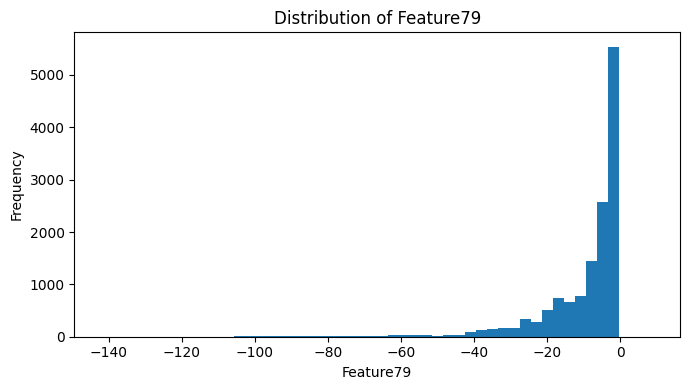

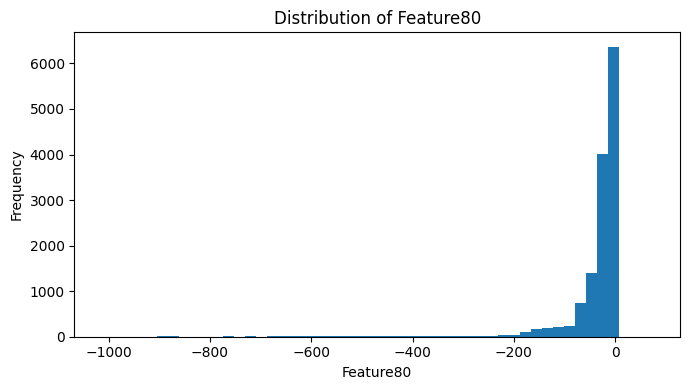

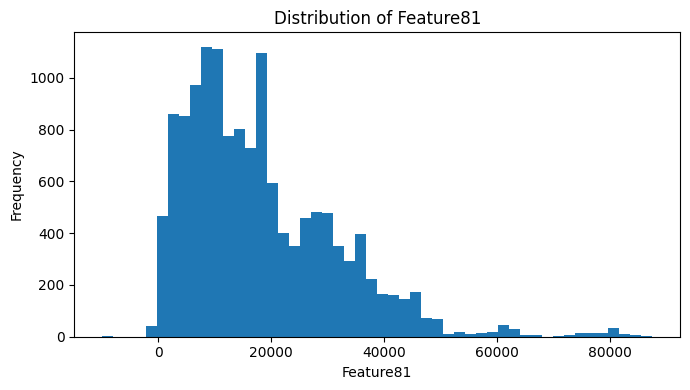

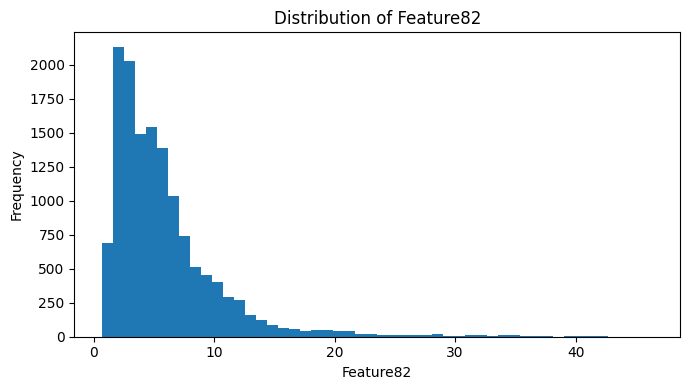

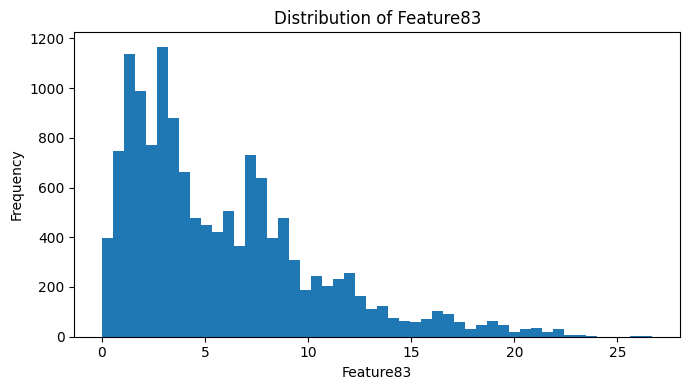

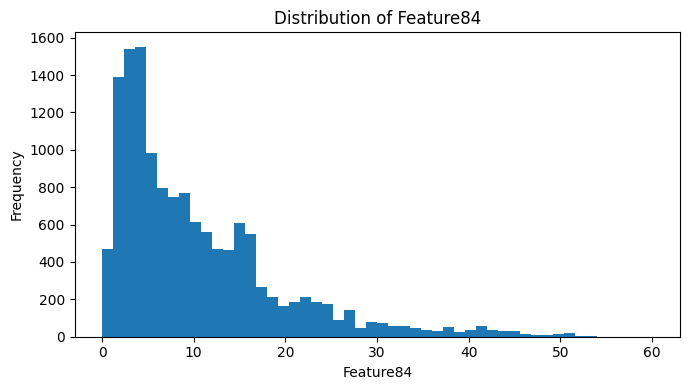

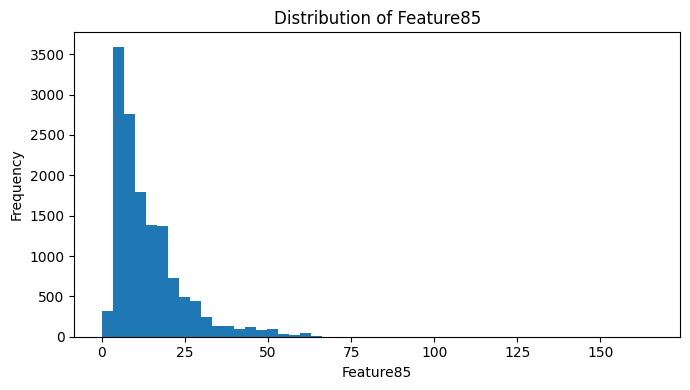

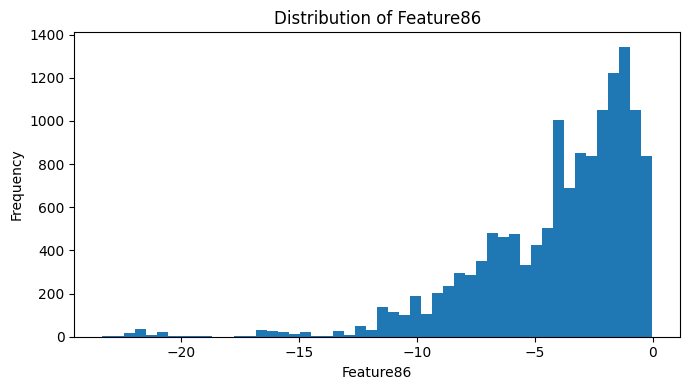

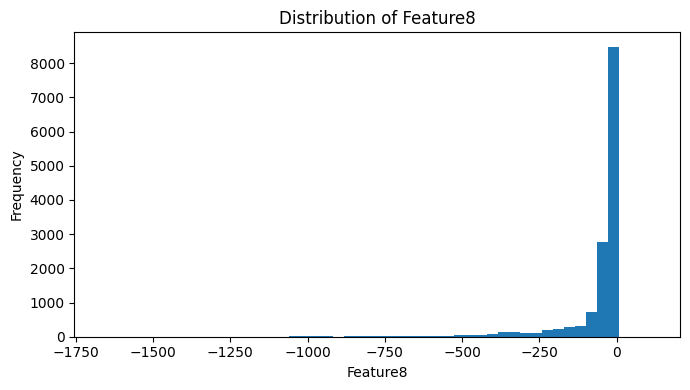

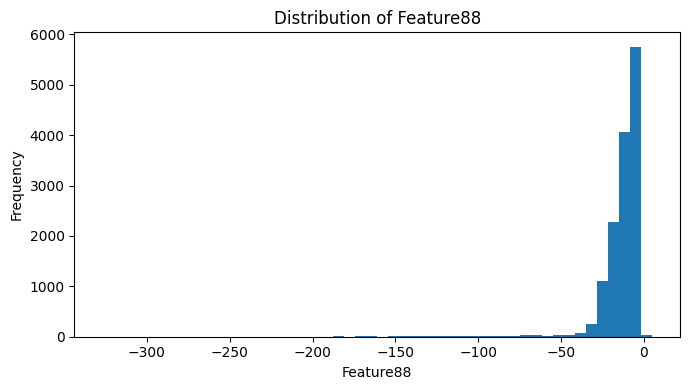

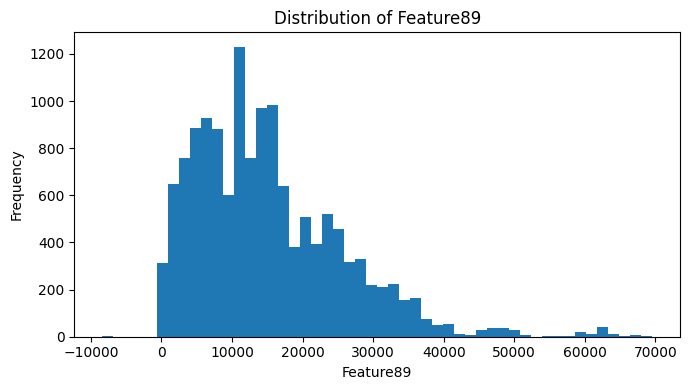

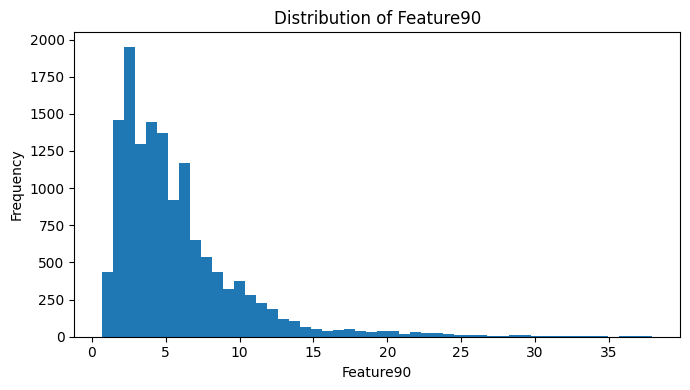

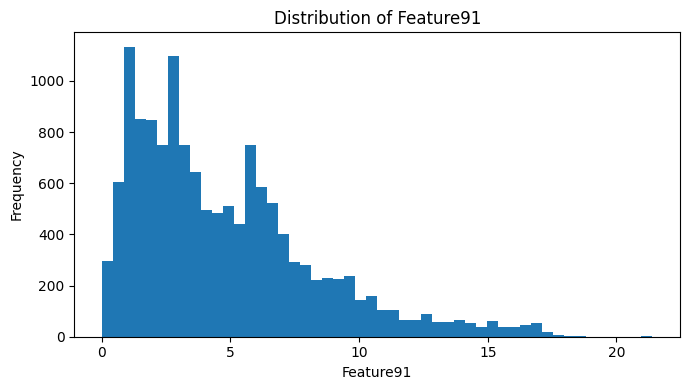

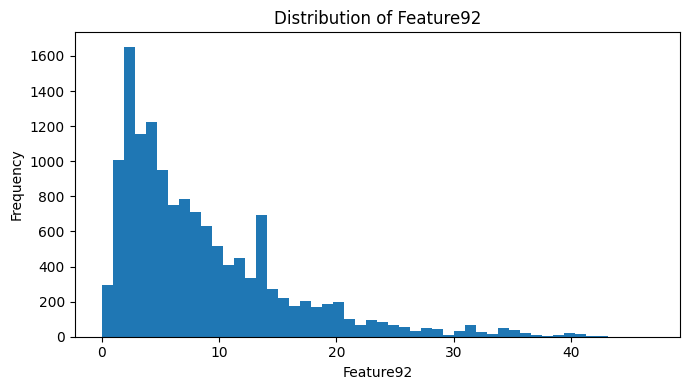

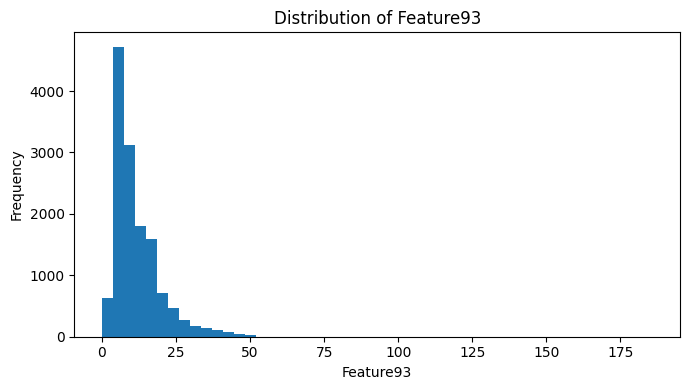

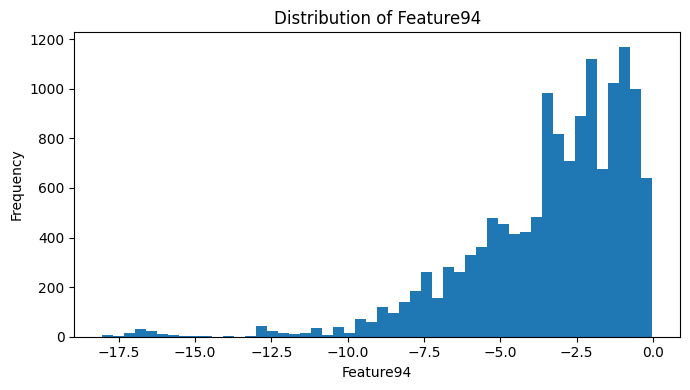

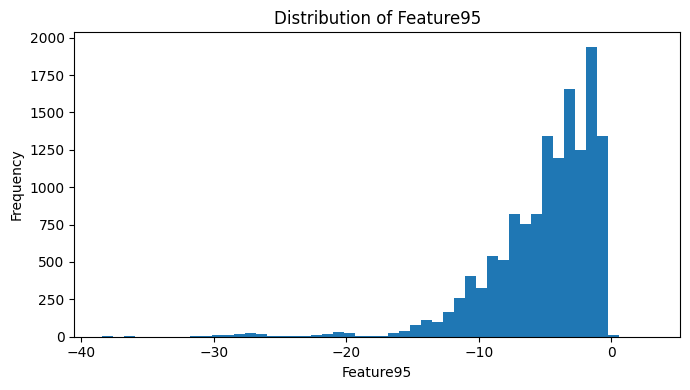

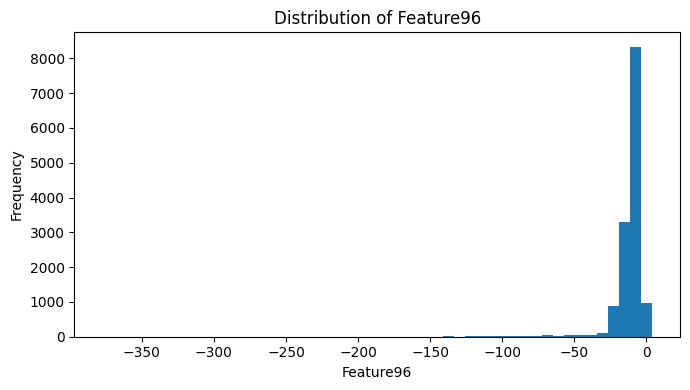

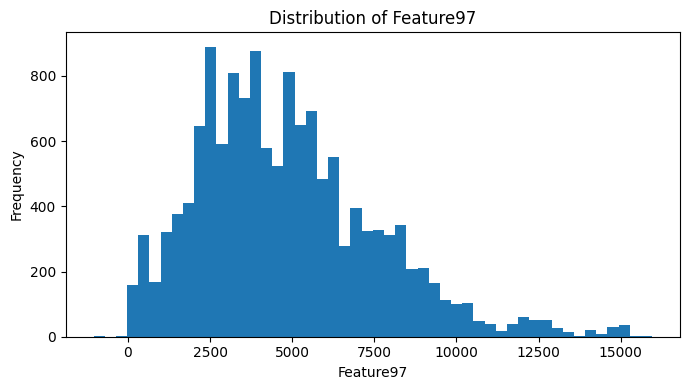

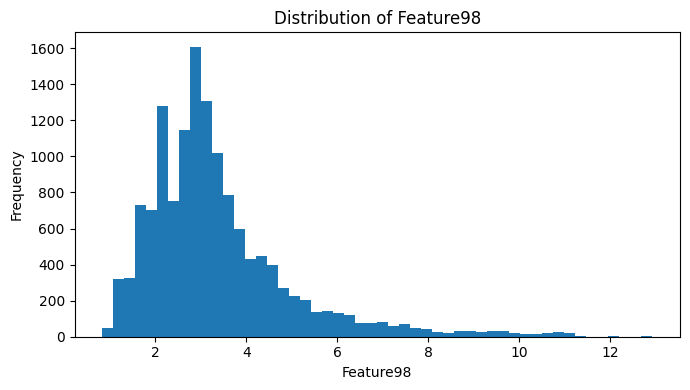

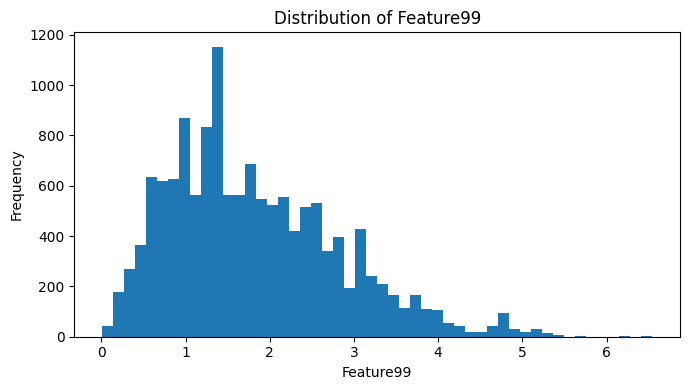

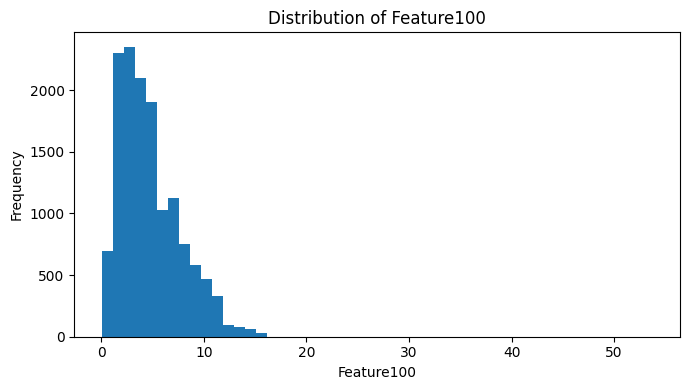

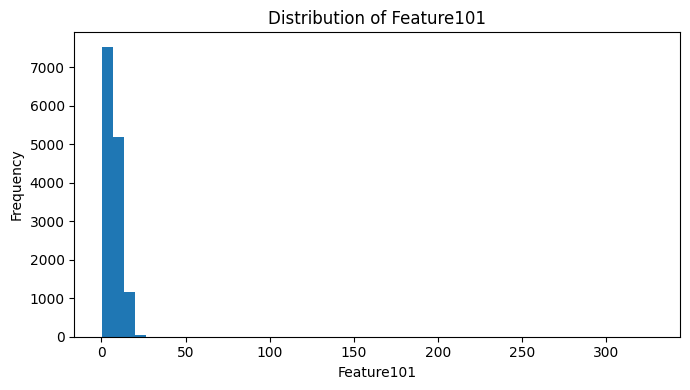

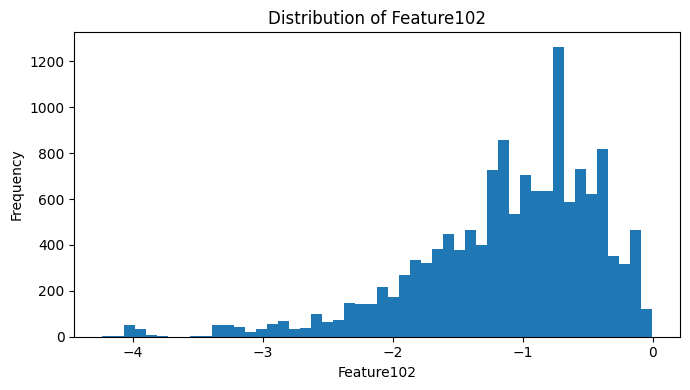

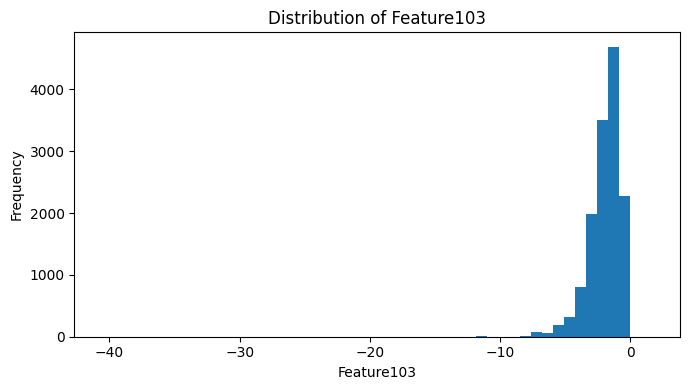

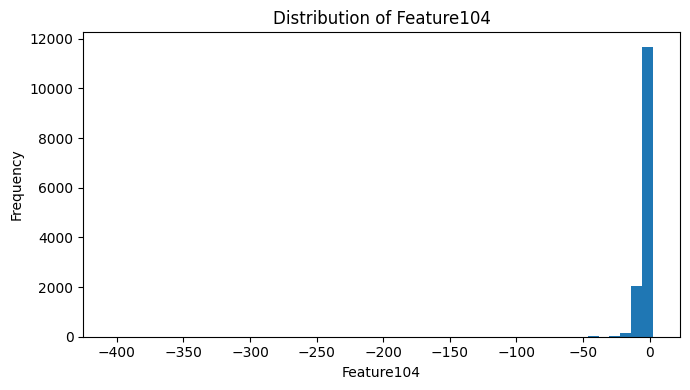

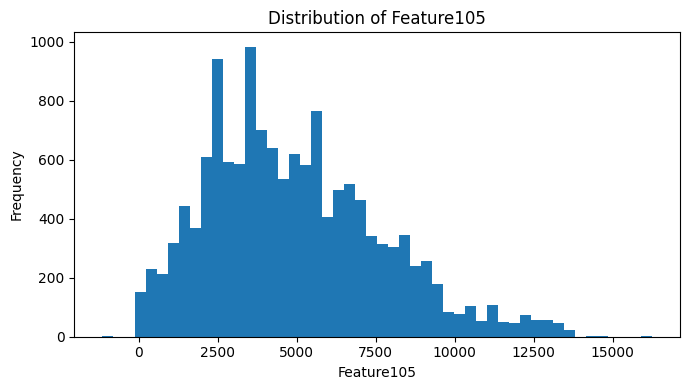

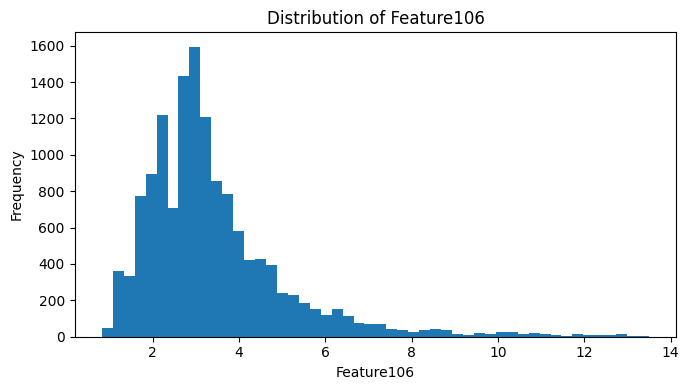

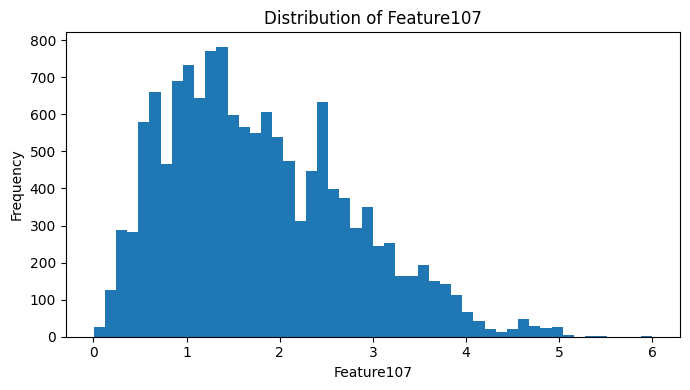

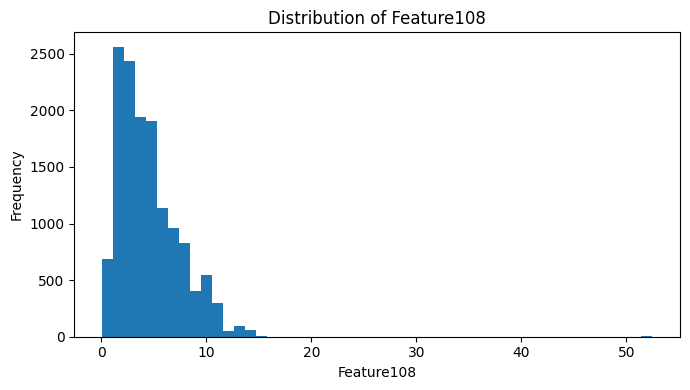

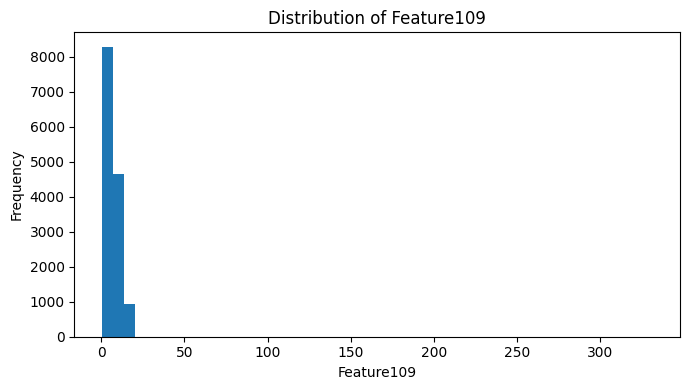

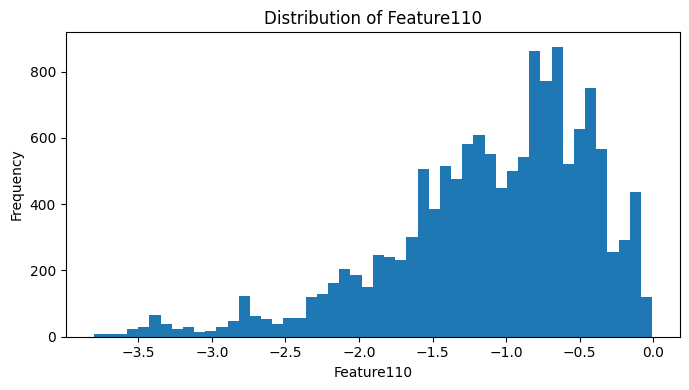

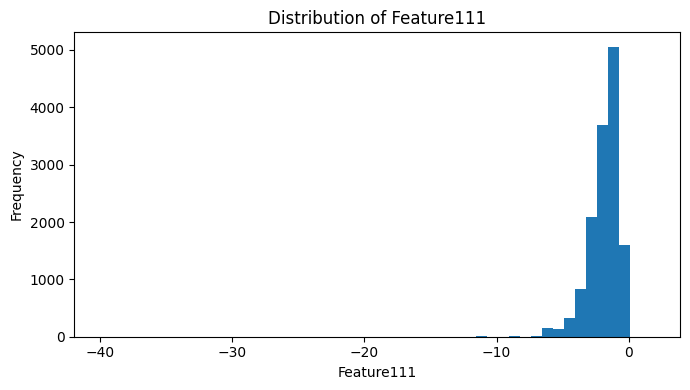

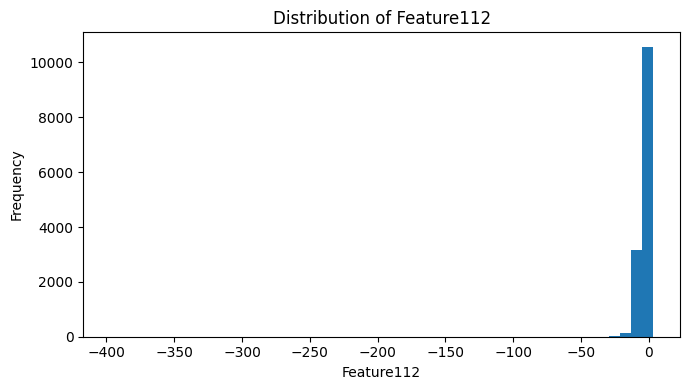

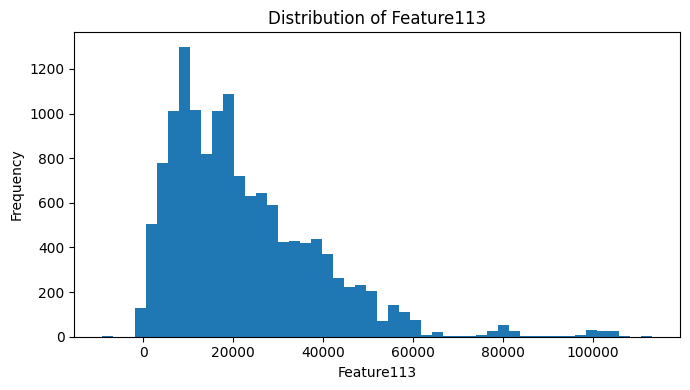

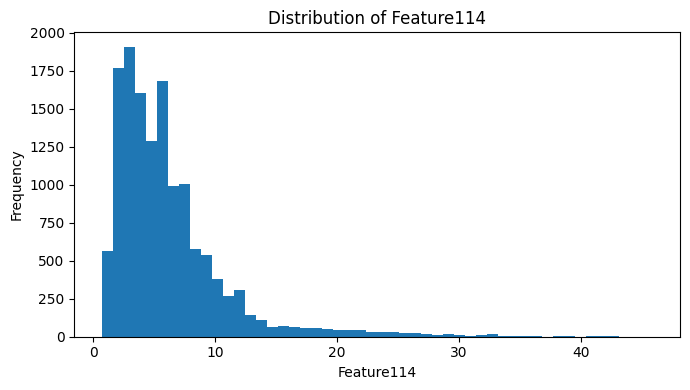

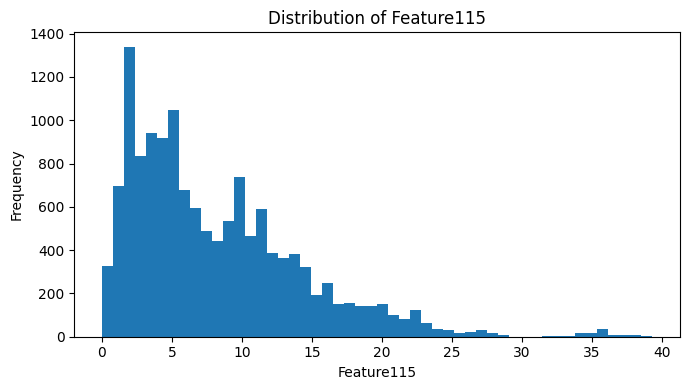

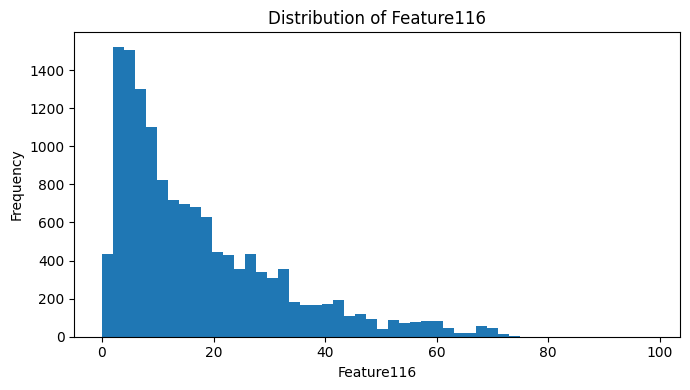

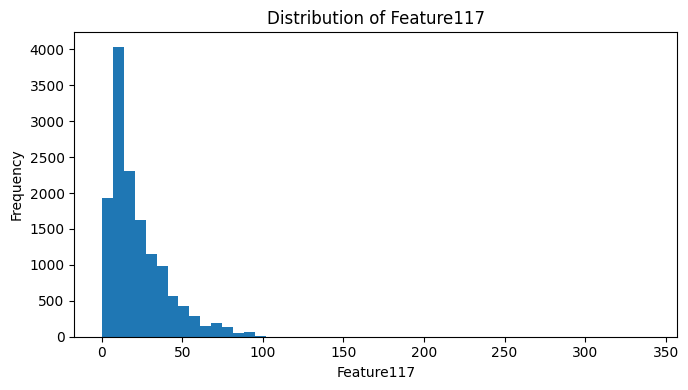

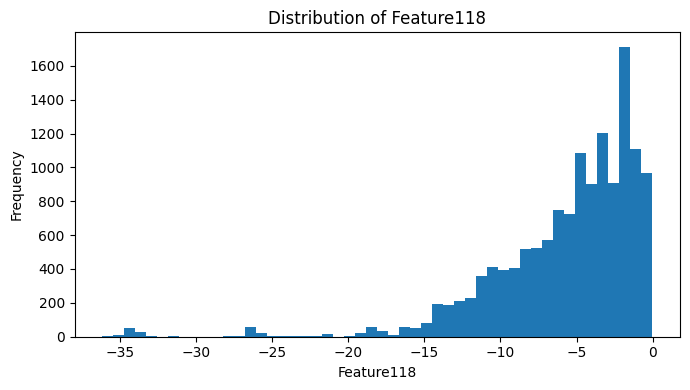

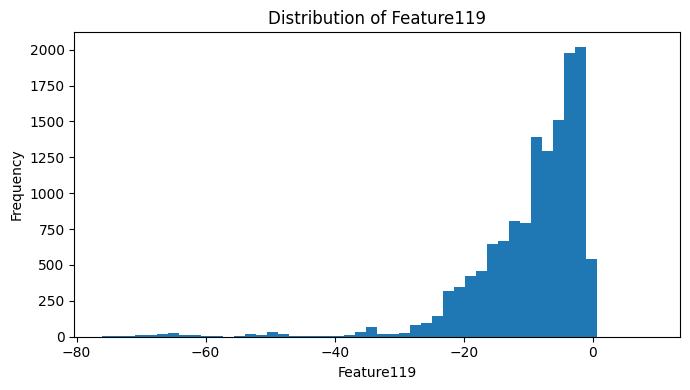

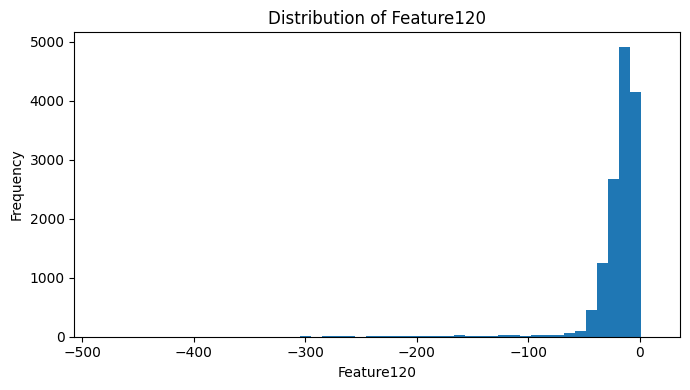

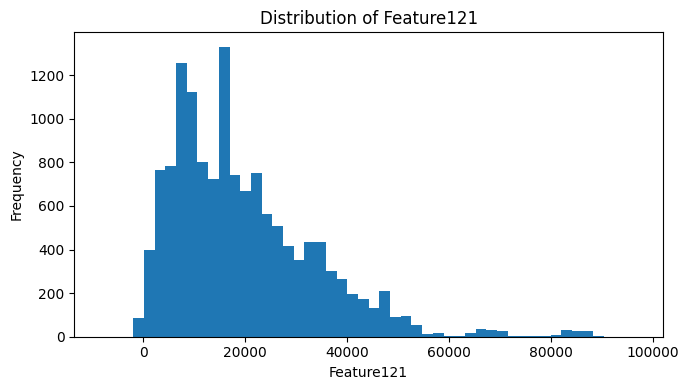

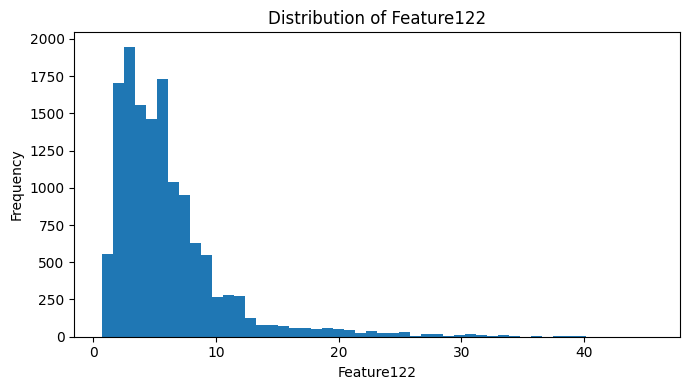

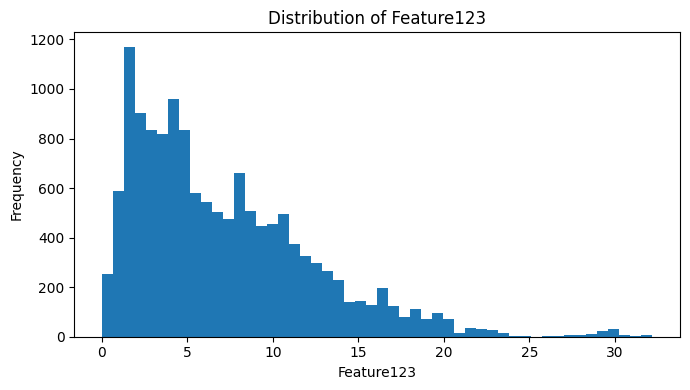

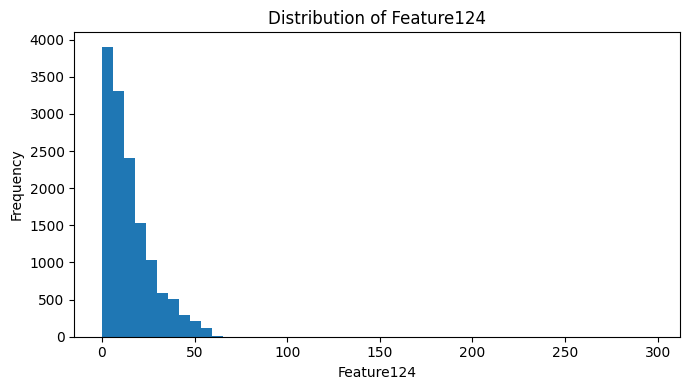

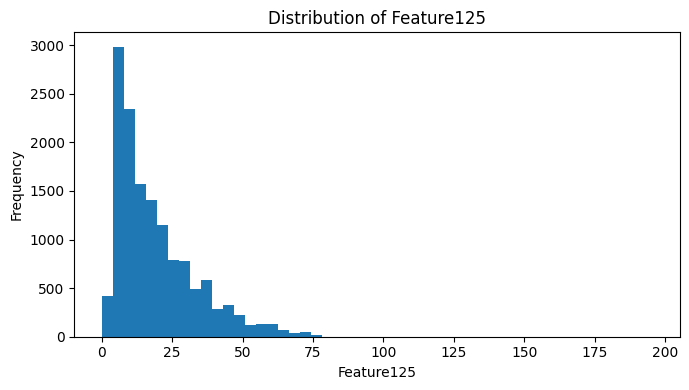

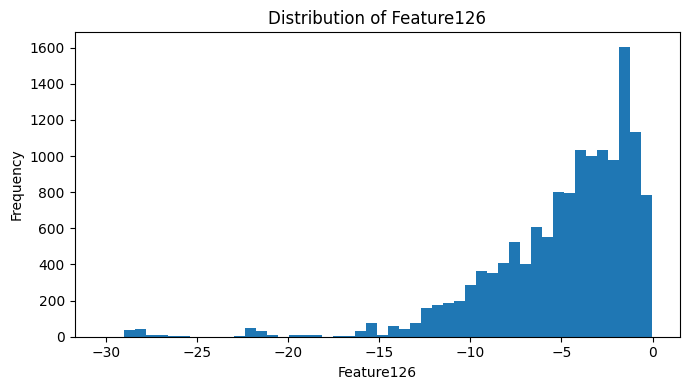

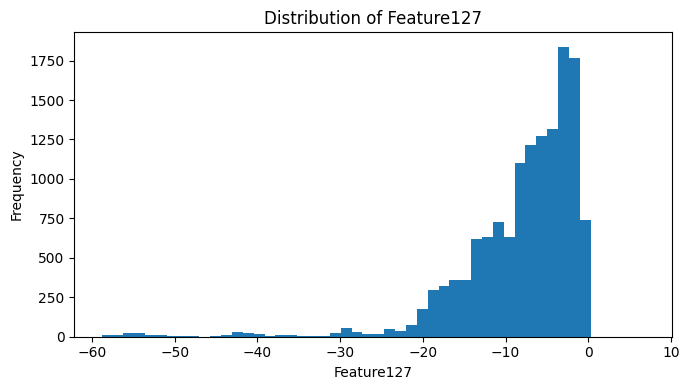

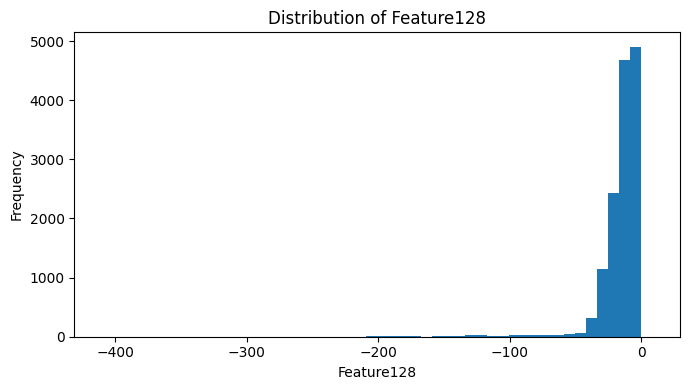

In [35]:
# Distribution of selected sensor features

for feature in selected_features:

    plt.figure(figsize=(7, 4))

    plt.hist(
        df[feature],
        bins=50
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature}")

    plt.tight_layout()
    plt.show()

In [36]:
# Define input features and target

feature_columns = [
    f"Feature{i}" for i in range(1, 129)
]

X = df[feature_columns].copy()

y = df["gas_class"].copy()

print("Number of features:", len(feature_columns))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget classes:")
print(sorted(y.unique()))

Number of features: 128
X shape: (13910, 128)
y shape: (13910,)

Target classes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


## 4. Train/Test Split and Scaling

In [37]:
from sklearn.model_selection import train_test_split

# Stratified 80/20 train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (11128, 128)
Testing set: (2782, 128)


In [38]:
# Compare class distributions

print("Training class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training class distribution:
gas_class
1    0.184400
2    0.210370
3    0.117991
4    0.139198
5    0.216301
6    0.131740
Name: proportion, dtype: float64

Testing class distribution:
gas_class
1    0.184400
2    0.210280
3    0.117901
4    0.139109
5    0.216391
6    0.131919
Name: proportion, dtype: float64


In [39]:
from sklearn.preprocessing import StandardScaler

# Standardize using training data only

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (11128, 128)
Scaled testing shape: (2782, 128)


## 5. Classification Part A — Five Models

## 6. Metrics and Confusion Matrices
Accuracy, weighted precision, weighted recall, weighted F1-score.

## 7. Preliminary Comparison